# Task-aligned multichannel kernel QRC

**Notebook 6.** It follows up on `5_KernelLifted_Memory_QRC_vs_EOC.ipynb`, whose preregistered outcome was
"5. No support under tested conditions". It reuses `1_QR_Qiskit.ipynb` and `4_QR_MixedSYK_Qiskit.ipynb`, and modifies
none of the three.

This notebook is **fully self-contained**: no helper modules, files, caches or figures are written, and every figure
is embedded inline.
- Definitions reused from notebooks 1 and 4 are *extracted from their source cells at runtime*, with `ast`, and
  executed here, so `mixed_layer`, `kappa_to_gJ`, the chaos diagnostics, `ReservoirConfig` and `make_simulator` stay
  the single source of truth.
- Everything else is implemented inline. Notebook 5's `klqrc_*.py` modules are **not** imported (audited).

The baseline is the **Kobayashi–Motome-inspired mixed-SYK edge-of-chaos QRC**, a Qiskit gate analogue of
PRL 136, 040602 (2026). It is not the literal fermionic Hamiltonian.

## 1. Research question and frozen criteria

**Diagnosis of notebook 5.** Four suspected causes of failure:
1. a 64/164-dimensional dictionary was squeezed into **one scalar** before entering the QRC;
2. generic MC did not measure retention of *task-relevant lifted* coordinates;
3. the kernel was optimised without regard to the quantum encoding;
4. the EOC QRC was already a strong nonlinear feature map with memory.

**Revised hypothesis.** A multidimensional, information-preserving, QRC-compatible lift, combined with a reservoir
selected for *task-aligned lifted-memory capacity* (TAMC), can outperform both the previous scalar hybrid and a matched
edge-of-chaos QRC on nonlinear long-horizon forecasting:

$$\mathbf s^{(d)}_t\to\psi_\theta(\mathbf s^{(d)}_t)\to z_t=W^\top\psi_\theta\in\mathbb R^{p}\ (p>1)\to r^Q_t\to\hat x_{t+h}.$$

**Architecture.** There are always $N_{\rm memory}=5$ persistent memory qubits plus $p$ reset input qubits:
$N=6,7,8$ for $p=1,2,3$. The readout is notebook 4's full weight ≤ 3 adjacent Pauli basis on the 5 memory qubits,
**132 observables for every $p$**.

**Preregistered FAST_MODE compute rule.** Measured on this CPU, Aer density-matrix throughput is ≈3000 steps/s at
N=6, ≈150 at N=7 and ≈19 at N=8 (re-measured in §3). FAST_MODE therefore fixes the primary interface at **p = 2
(N = 7)**:
- p = 1 and p = 3 enter every classical analysis;
- p = 3 enters QRC evaluation as a reduced-unit ablation, on 3 data seeds with the paired reservoir seed;
- the long-run GPU configuration (§23) searches p ∈ {2, 3, 4}.

**Seeds.** This notebook uses a **new trajectory seed family** (salt 6006). Notebook 5's test trajectories were
already released, so they are not reused.

The criteria printed below are hashed before any simulation. The hash is checked at the lock, at the test release and
in the audit.

In [1]:
import json, hashlib

PREREG = {
    'nontrivial_horizons': [5, 10],
    'interface_pass': {
        'I1': 'held-out (test) delay-state reconstruction R2 of the locked p=2 representation > the same lift/projection at p=1, on both datasets',
        'I2': 'held-out (test) future-sufficiency R2 (x_{t+1}, x_{t+5}, x_{t+10}) at p=2 > p=1, on both datasets',
        'I3': 'validation kernel->QRC degradation deg(p)=(J_QRC-J_kernel_only)/J_kernel_only satisfies deg(2) <= deg(1) - 0.25*|deg(1)| on both datasets',
        'I4': 'KERNEL_TASKMEM_QRC beats NB5_SCALAR_HYBRID (median test NRMSE) on both datasets at one nontrivial horizon',
        'I5': 'at that horizon the paired 95% CI excludes zero on at least one dataset'},
    'task_memory_pass': {
        'M1': 'selected reservoir is in the top quartile (>= 75th percentile) of TAMC among memory candidates, both datasets',
        'M2': 'IPC_NL(selected memory) < IPC_NL(matched EOC)',
        'M3': 'TAMC-selected beats generic-MC-selected reservoir (median test NRMSE, kernel input) on one dataset at a nontrivial horizon',
        'M4': 'at that horizon it is not worse than generic-MC-selected by more than 5% on the other dataset',
        'M5': 'TAMC exceeds the maximum of 20 shuffled-probe null TAMCs, both datasets'},
    'beats_eoc_pass': {
        'B1': 'KERNEL_TASKMEM_QRC beats BEST_MATCHED_EOC (median test NRMSE) on both datasets at the same nontrivial horizon',
        'B2': 'relative improvement >= 10% on one dataset and >= 5% on the other',
        'B3': 'paired 95% CI of the improvement excludes zero on both',
        'B4': 'no extra input channels, qubits, memory qubits or readout observables (audited)',
        'B5': 'matched EOC kappa inside the N=7 edge band'},
    'qrc_value_pass': {
        'Q1': 'KERNEL_TASKMEM_QRC beats full-dictionary kernel ridge by >= 5% at one (dataset, nontrivial horizon)',
        'Q2': 'paired 95% CI excludes zero there',
        'Q3': 'on every other (dataset, nontrivial horizon) it is not worse than kernel-only by more than 25%'},
    'full_hypothesis': 'INTERFACE_PASS and TASK_MEMORY_PASS and BEATS_EOC_PASS and QRC_VALUE_PASS',
    'outcome_tree': ['FULL -> 1. Full support',
                     'INTERFACE and not BEATS_EOC -> 2. Interface repaired, EOC not beaten',
                     'TASK_MEMORY and not QRC_VALUE -> 3. Task-aligned memory helps, but kernel-only explains performance',
                     'not INTERFACE -> 4. Scalar bottleneck was not the primary failure mechanism',
                     'otherwise -> 5. No support under the tested conditions'],
    'selection_rules': {
        'stage1': 'eligible: nonlinear dictionary, task-aware projection (rrr or pls), p=2, not rejected; rank = mean of normalised ranks of future R2, history R2, closure error, kernel-only val NRMSE, linear-memory proxy val NRMSE; keep 3',
        'rejection': 'near-zero-variance coordinate (<1e-6 of max), effective rank < p, standardized condition number > 1e4, collapse fraction > 1%, future or history R2 more than 0.05 below the notebook-5 scalar projection of the same dictionary',
        'edge_band': 'eta=(<r>-r_P)/(r_CUE-r_P) (median over seeds) at each N; kappa_lo = largest kappa with eta>=0.9, kappa_hi = first larger kappa with eta<=0.1',
        'eoc': 'kappa from 3 band points at reps=4 x inputs {raw, linear, kernel-top1}, then reps in {1,2,8,16} at the best (kappa,input); validation J only',
        'tamc': 'sum_jk w_jk R2(innovation probe eps_{t-k,j}, k>=1) from the QRC state driven by z_t + eps_t (eps ~ N(0, 0.05^2), common random numbers); w from train-only ridge forecast importance',
        'memory_score': 'S = TAMC~ + 0.25 MC~ - 0.25 IPC_NL~ (min-max normalised over candidates); filters: echo-state check max|dX| < 1e-3 on steps 50..150 from two initial states, IPC_NL < IPC_NL(EOC)',
        'stage2': 'top-3 representations through the EOC and memory QRC (validation); reject C_QRC = E_proxy/E_QRC < 0.5 (unless all fail); pick min validation J of the memory QRC',
        'best_matched_eoc': 'argmin validation J among RAW_EOC, LINEAR_EOC, KERNEL_EOC (full-length validation)'},
    'statistics': {'metric': 'NRMSE = RMSE/std(target); median over (data seed, reservoir seed) units',
                   'bootstrap': 'paired moving-block over test indices, 2000 draws',
                   'block': 'max(40, largest |test error| autocorrelation length over compared models), rounded up to 10'},
    'compute_rule': 'FAST_MODE: primary p=2 (N=7) on 3 data seeds x 3 reservoir seeds; p=3 (N=8) and ablations on 3 units (paired reservoir seed)',
}
CRITERIA_HASH = hashlib.sha256(json.dumps(PREREG, sort_keys=True).encode()).hexdigest()
print(json.dumps(PREREG, indent=1))
print('\nFROZEN CRITERIA SHA-256:', CRITERIA_HASH)

{
 "nontrivial_horizons": [
  5,
  10
 ],
 "interface_pass": {
  "I1": "held-out (test) delay-state reconstruction R2 of the locked p=2 representation > the same lift/projection at p=1, on both datasets",
  "I2": "held-out (test) future-sufficiency R2 (x_{t+1}, x_{t+5}, x_{t+10}) at p=2 > p=1, on both datasets",
  "I3": "validation kernel->QRC degradation deg(p)=(J_QRC-J_kernel_only)/J_kernel_only satisfies deg(2) <= deg(1) - 0.25*|deg(1)| on both datasets",
  "I4": "KERNEL_TASKMEM_QRC beats NB5_SCALAR_HYBRID (median test NRMSE) on both datasets at one nontrivial horizon",
  "I5": "at that horizon the paired 95% CI excludes zero on at least one dataset"
 },
 "task_memory_pass": {
  "M1": "selected reservoir is in the top quartile (>= 75th percentile) of TAMC among memory candidates, both datasets",
  "M2": "IPC_NL(selected memory) < IPC_NL(matched EOC)",
  "M3": "TAMC-selected beats generic-MC-selected reservoir (median test NRMSE, kernel input) on one dataset at a nontrivial horizon",

## 2. Environment and source audit

Before anything else, this cell records:
- SHA-256 hashes of the three source notebooks;
- a snapshot of every file in the repository, so the audit can prove nothing else was created or modified.

`USE_GPU` comes from a fresh `AerSimulator().available_devices()` probe, with fallback to CPU.

In [2]:
FAST_MODE = True
LONG_RUN_CONFIG_ONLY = True
USE_QPU = False

import os, sys, ast, time, json, hashlib, itertools, functools, platform, warnings, zlib
from collections import OrderedDict
from dataclasses import dataclass, replace
import numpy as np
import scipy, sklearn
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import unitary_group, spearmanr
from numpy.polynomial import legendre as npleg
import qiskit, qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp, DensityMatrix, Statevector, random_unitary
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, Markdown

assert USE_QPU is False, 'this notebook never submits hardware jobs'
SMOKE = os.environ.get('NB6_SMOKE') == '1'          # development switch; the audit requires it to be off
T_START = time.perf_counter()
NB_SELF = '6_TaskAligned_Multichannel_Kernel_QRC.ipynb'
REPO = os.path.abspath('..')
SOURCES = ('1_QR_Qiskit.ipynb', '4_QR_MixedSYK_Qiskit.ipynb', '5_KernelLifted_Memory_QRC_vs_EOC.ipynb')


def sha256(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()


def fs_snapshot():
    snap = {}
    for root, dirs, files in os.walk(REPO):
        dirs[:] = [d for d in dirs if d not in ('.git', '.venv')]
        for fn in files:
            p = os.path.join(root, fn)
            rel = os.path.relpath(p, REPO)
            if rel.replace('\\', '/') == f'code/{NB_SELF}':
                continue
            st = os.stat(p)
            snap[rel] = (st.st_size, st.st_mtime_ns)
    return snap


SOURCE_HASHES = {p: sha256(p) for p in SOURCES}
FS_BEFORE = fs_snapshot()
USE_GPU = 'GPU' in AerSimulator().available_devices()
DEVICE = 'GPU' if USE_GPU else 'CPU'
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 9})
ENV = {'python': sys.version.split()[0], 'platform': platform.platform(), 'qiskit': qiskit.__version__,
       'qiskit_aer': qiskit_aer.__version__, 'numpy': np.__version__, 'scipy': scipy.__version__,
       'sklearn': sklearn.__version__, 'aer_devices(fresh)': AerSimulator().available_devices(), 'device': DEVICE,
       'cpus': os.cpu_count(), 'SMOKE': SMOKE}
for k, v in ENV.items():
    print(f'{k:20s} {v}')
for p, h in SOURCE_HASHES.items():
    print(f'source {p:45s} sha256 {h[:20]}...')
print('repository files snapshotted:', len(FS_BEFORE))

python               3.14.4
platform             Windows-11-10.0.26200-SP0
qiskit               2.5.2
qiskit_aer           0.17.2
numpy                2.5.2
scipy                1.18.1
sklearn              1.9.0
aer_devices(fresh)   ('CPU',)
device               CPU
cpus                 12
SMOKE                False
source 1_QR_Qiskit.ipynb                             sha256 a285bbe1c88d632e87d3...
source 4_QR_MixedSYK_Qiskit.ipynb                    sha256 13b24adebe90d3b620d4...
source 5_KernelLifted_Memory_QRC_vs_EOC.ipynb        sha256 da112bf089e112049d79...
repository files snapshotted: 56


### Runtime extraction of the reused definitions

Each name below is located in a source notebook's code cells by parsing them with `ast`. Its exact source text,
decorators included, is executed in this kernel, and a hash of the extracted text is printed. Nothing is copied by
hand.

In [3]:
def extract_defs(path, names):
    nb = json.load(open(path, encoding='utf-8'))
    found = {}
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        src = ''.join(cell['source'])
        try:
            tree = ast.parse(src)
        except SyntaxError:          # cells with shell magics (!pip ...) are skipped
            continue
        lines = src.splitlines()
        for node in tree.body:
            if isinstance(node, (ast.FunctionDef, ast.ClassDef)):
                nm = node.name
            elif isinstance(node, ast.Assign) and len(node.targets) == 1 and isinstance(node.targets[0], ast.Name):
                nm = node.targets[0].id          # module-level constants, e.g. DEFAULT_ALPHAS
            else:
                continue
            if nm in names and nm not in found:
                start = min([d.lineno for d in getattr(node, 'decorator_list', [])] + [node.lineno])
                found[nm] = '\n'.join(lines[start - 1:node.end_lineno])
    missing = set(names) - set(found)
    assert not missing, f'{path}: missing {missing}'
    return found


NB1_NAMES = ['chain_edges', 'ReservoirConfig', 'make_simulator', 'random_input', 'task_narma2', 'chrono_split',
             'nrmse', 'DEFAULT_ALPHAS', 'select_and_eval_ridge']
NB4_NAMES = ['default_n_sparse_terms', 'sample_syk4_terms', 'sample_syk4_couplings', 'sample_syk4_pauli_types',
             'zzzz_rotation', '_basis_change_pre', '_basis_change_post', 'pauli4_rotation', 'feature_ops_mem_all',
             'mixed_layer', 'build_trajectory_circuit_mixed', 'kappa_to_gJ', 'single_layer_unitary_mixed',
             'step_unitary_mixed', 'operator_entanglement', 'level_spacing_ratio', 'sample_reference_r_statistics',
             '_local_pauli', 'otoc_curve', 'scrambling_time']
EXTRACTED = {}
for path, names in ((SOURCES[0], NB1_NAMES), (SOURCES[1], NB4_NAMES)):
    defs = extract_defs(path, names)
    for name in names:                      # execute in source order (constants before their users)
        src = defs[name]
        exec(compile(src, f'<{path}:{name}>', 'exec'), globals())
        EXTRACTED[name] = (path, hashlib.sha256(src.encode()).hexdigest()[:12])
for name, (path, h) in EXTRACTED.items():
    print(f'{name:32s} <- {path:28s} sha {h}')
assert not any(m.startswith('klqrc') for m in sys.modules), 'notebook-5 helper modules must not be imported'

chain_edges                      <- 1_QR_Qiskit.ipynb            sha fe98f6401104
ReservoirConfig                  <- 1_QR_Qiskit.ipynb            sha fd42b609eaa8
make_simulator                   <- 1_QR_Qiskit.ipynb            sha 6ed38a4895a1
random_input                     <- 1_QR_Qiskit.ipynb            sha 020037e335dd
task_narma2                      <- 1_QR_Qiskit.ipynb            sha a0ad68dd1089
chrono_split                     <- 1_QR_Qiskit.ipynb            sha 0f745b539cc9
nrmse                            <- 1_QR_Qiskit.ipynb            sha ea86c1fa398d
DEFAULT_ALPHAS                   <- 1_QR_Qiskit.ipynb            sha 3b4384e32de5
select_and_eval_ridge            <- 1_QR_Qiskit.ipynb            sha 5c8868dfdd9a
default_n_sparse_terms           <- 4_QR_MixedSYK_Qiskit.ipynb   sha 107af239cb91
sample_syk4_terms                <- 4_QR_MixedSYK_Qiskit.ipynb   sha 06542200a727
sample_syk4_couplings            <- 4_QR_MixedSYK_Qiskit.ipynb   sha 3ddd35f76470
sample_syk4_paul

### Notebook 5 historical reference (parsed from its executed outputs)

These numbers are read, not recomputed. Notebook 5's locked configurations are also parsed from its lock record, so
the `NB5_SCALAR_HYBRID` and `NB5_EOC_REFERENCE` models below are rebuilt *exactly* as notebook 5 locked them, then
retrained on this notebook's new trajectories.

In [4]:
nb5 = json.load(open(SOURCES[2], encoding='utf-8'))
nb5_text = []
for c in nb5['cells']:
    if c['cell_type'] == 'code':
        for o in c.get('outputs', []):
            nb5_text.append(''.join(o.get('text', '')) or ''.join(o.get('data', {}).get('text/markdown', '')))
blob = [t for t in nb5_text if '"criteria_hash"' in t and 'METHOD LOCKED' in t][0]
NB5_LOCK = json.loads(blob[blob.index('{'):blob.index('METHOD LOCKED')])
print('notebook 5 locked configuration:')
for ds, v in NB5_LOCK['locked'].items():
    print(f"  {ds:13s} kernel={v['kernel']}  EOC(kappa,reps)={tuple(v['eoc_key'])}  memory={tuple(v['memory_key'])}  BEST_EOC input={v['best_eoc_input']}")
for t in nb5_text:
    if 'TEST NRMSE' in t:
        for line in t.splitlines():
            if line.startswith(('===', 'model', 'BEST_EOC_QRC', 'KERNEL_MEMORY_QRC', 'kernel_only_ridge')):
                print('  nb5 >', line)
outcome_line = [l for t in nb5_text for l in t.splitlines() if l.startswith('### Outcome')]
print('  nb5 >', outcome_line[0] if outcome_line else '(outcome not found)')

notebook 5 locked configuration:
  mackey_glass  kernel=rbf[m=64,bw=4]|d=8|pred|p=1  EOC(kappa,reps)=(3.778498, 2)  memory=(9.799186, 1)  BEST_EOC input=raw(p=1)
  lorenz        kernel=poly3|d=8|pred|p=1  EOC(kappa,reps)=(4.517727, 16)  memory=(9.799186, 1)  BEST_EOC input=linear|d=8|pred1|p=1
  nb5 > === mackey_glass: TEST NRMSE, median [IQR] over 9 (data seed, reservoir seed) units ===
  nb5 > model                                            h=1                   h=5                  h=10
  nb5 > BEST_EOC_QRC                     0.0022 [0.002,0.002]   0.0018 [0.002,0.002]   0.0145 [0.014,0.015]
  nb5 > KERNEL_MEMORY_QRC                0.0118 [0.005,0.041]   0.0132 [0.007,0.066]   0.0239 [0.014,0.067]
  nb5 > kernel_only_ridge                0.0064 [0.006,0.006]   0.0077 [0.006,0.008]   0.0327 [0.031,0.041]
  nb5 > === lorenz: TEST NRMSE, median [IQR] over 9 (data seed, reservoir seed) units ===
  nb5 > model                                            h=1                   h=5        

## 3. Recurrent multichannel QRC

`MultiInputReservoirConfig(N, n_input, g, J, reps, seed)` defines the reservoir.
- **Inputs:** qubits `0..p-1` are reset and re-encoded with $R_y(\pi z_{t,j})$ at every step.
- **Memory:** qubits `p..p+4` (exactly 5) are never reset.
- **Dynamics:** each step applies `reps` copies of notebook 4's `mixed_layer`.
- **Readout:** notebook 4's `feature_ops_mem_all` basis is shifted onto the memory qubits, giving the identical 132
  Pauli strings for every *p*.

The disorder seed fixes both the Rz disorder (via notebook 1's `ReservoirConfig`) and the sparse quartic terms, as in
notebook 4.

**Exact execution.**
- The per-step mixed block is one `UnitaryGate` equal to `Operator(mixed_layer circuit)**reps`; §4 asserts it equals
  the gate-level circuit.
- Each step saves the memory register's reduced density matrix, and features are exact $\mathrm{Re\,Tr}(\rho P)$.
- Chunks of 256 steps are continued exactly: the full density matrix is saved at the end of each chunk and loaded
  with `set_density_matrix`.

In [5]:
G_MAX, J_MAX, N_MEMORY = np.pi / 2, 1.0, 5


@dataclass(frozen=True)
class MultiInputReservoirConfig:
    N: int
    n_input: int
    g: float
    J: float
    reps: int
    seed: int
    haar_seed: int | None = None

    def __post_init__(self):
        if not (self.N > self.n_input >= 1):
            raise ValueError('need N > n_input >= 1')

    @property
    def input_qubits(self):
        return list(range(self.n_input))

    @property
    def memory_qubits(self):
        return list(range(self.n_input, self.N))

    def terms(self):
        n = default_n_sparse_terms(self.N)
        return (sample_syk4_terms(self.N, n, seed=self.seed), sample_syk4_couplings(n, J=self.J, seed=self.seed),
                sample_syk4_pauli_types(n, seed=self.seed))

    def bias_z(self):
        return ReservoirConfig(N=self.N, seed=self.seed).sample_disorder()[0]


def mixed_config(p, kappa, reps, seed):
    g, J = kappa_to_gJ(float(kappa), G_MAX, J_MAX)
    return MultiInputReservoirConfig(N_MEMORY + p, p, float(g), float(J), int(reps), int(seed))


def haar_config(p, seed):
    return MultiInputReservoirConfig(N_MEMORY + p, p, 0.0, 0.0, 1, int(seed), haar_seed=30000 + int(seed))


def kappa_of(rc):
    return float((rc.g / G_MAX) / (rc.J / J_MAX))


@functools.lru_cache(maxsize=2048)
def layer_unitary(rc):
    return single_layer_unitary_mixed(rc.N, rc.g, *rc.terms(), rc.bias_z())


@functools.lru_cache(maxsize=2048)
def step_unitary(rc):
    if rc.haar_seed is not None:
        return np.asarray(random_unitary(2 ** rc.N, seed=rc.haar_seed).data)
    return np.linalg.matrix_power(layer_unitary(rc), rc.reps)


def append_mixed_block(qc, rc):
    terms, cps, pts = rc.terms()
    bz = rc.bias_z()
    for _ in range(rc.reps):
        mixed_layer(qc, rc.N, rc.g, terms, cps, pts, bz)


# readout: nb4's basis for (N=6, input qubit 0) acts on qubits 1..5; shift it onto the memory qubits p..p+4
_LAB6, _OPS6 = feature_ops_mem_all(N_MEMORY + 1, 0, 3)
READ_M = np.asarray([SparsePauliOp(P).apply_layout([q - 1 for q in qa], num_qubits=N_MEMORY).to_matrix().T.reshape(-1)
                     for P, qa in _OPS6])


def readout_ops(p):
    return [(P, [q + p - 1 for q in qa]) for P, qa in _OPS6]


N_FEATURES = len(_OPS6)
CHUNK = 256
MEMO, MEMO_MAX = OrderedDict(), 1.5e9
STATS = {'aer_steps': 0, 'aer_seconds': 0.0, 'aer_circuits': 0, 'recurrent_jobs': 0, 'memo_hits': 0,
         'steps_by_N': {}, 'seconds_by_N': {}}


@dataclass
class QRCJob:
    cfg: MultiInputReservoirConfig
    z: np.ndarray
    rho0: object = None
    fuse: bool = True

    def key(self):
        h = hashlib.sha256(repr(self.cfg).encode() + b'|' + str(self.fuse).encode())
        h.update(np.ascontiguousarray(self.z, dtype=np.float64).tobytes())
        if self.rho0 is not None:
            h.update(np.ascontiguousarray(self.rho0).tobytes())
        return h.hexdigest()


def build_chunk(job, t0, t1, rho, gate):
    rc = job.cfg
    qc = QuantumCircuit(rc.N)
    if rho is not None:
        qc.set_density_matrix(DensityMatrix(rho))
    for t in range(t0, t1):
        for j, q in enumerate(rc.input_qubits):
            qc.reset(q)
            qc.ry(np.pi * float(job.z[t, j]), q)
        if job.fuse:
            qc.append(gate, range(rc.N))
        else:
            append_mixed_block(qc, rc)
        qc.save_density_matrix(qubits=rc.memory_qubits, label=f'r{t - t0}')
    qc.save_density_matrix(label='final')
    return qc


def _sim():
    sim = make_simulator(use_gpu=USE_GPU, method='density_matrix')       # notebook 1's safeguarded constructor
    sim.set_options(max_parallel_experiments=max(1, min(6, (os.cpu_count() or 2) // 2)))
    assert sim.options.method == 'density_matrix'
    return sim


def run_qrc_jobs(jobs, chunk=CHUNK, use_memo=True, batch=36):
    """Chunked, batched exact Aer density-matrix trajectories -> list of (T, 132) feature matrices."""
    for j in jobs:
        z = np.asarray(j.z)
        assert z.ndim == 2 and z.shape[1] == j.cfg.n_input and len(j.cfg.memory_qubits) == N_MEMORY
        assert np.all(np.isfinite(z)) and z.min() >= -1e-12 and z.max() <= 1 + 1e-12
    out, todo, seen = [None] * len(jobs), [], {}
    for i, j in enumerate(jobs):
        k = j.key()
        if use_memo and k in MEMO:
            MEMO.move_to_end(k); out[i] = MEMO[k]; STATS['memo_hits'] += 1
        elif k in seen:
            pass
        else:
            seen[k] = i; todo.append(i)
    sim = _sim()
    st = {i: {'pos': 0, 'rho': jobs[i].rho0, 'feats': [],
              'gate': UnitaryGate(step_unitary(jobs[i].cfg), check_input=False) if jobs[i].fuse else None} for i in todo}
    STATS['recurrent_jobs'] += len(todo)
    active = list(todo)
    while active:
        for b0 in range(0, len(active), batch):
            grp = active[b0:b0 + batch]
            circs, spans = [], []
            for i in grp:
                t0 = st[i]['pos']; t1 = min(t0 + chunk, len(jobs[i].z))
                circs.append(build_chunk(jobs[i], t0, t1, st[i]['rho'], st[i]['gate'])); spans.append((t0, t1))
            ts = time.perf_counter()
            res = sim.run(circs, shots=1).result()
            dt = time.perf_counter() - ts
            assert res.success, res.status
            STATS['aer_seconds'] += dt; STATS['aer_circuits'] += len(circs)
            nsteps = {}
            for c, (i, (t0, t1)) in enumerate(zip(grp, spans)):
                d = res.data(c)
                R = np.stack([np.asarray(getattr(d[f'r{t}'], 'data', d[f'r{t}'])).reshape(-1) for t in range(t1 - t0)])
                st[i]['feats'].append(np.real(R @ READ_M.T))
                st[i]['rho'] = np.asarray(getattr(d['final'], 'data', d['final']))
                st[i]['pos'] = t1
                STATS['aer_steps'] += t1 - t0
                N = jobs[i].cfg.N
                nsteps[N] = nsteps.get(N, 0) + (t1 - t0)
            tot = sum(nsteps.values())
            for N, n in nsteps.items():
                STATS['steps_by_N'][N] = STATS['steps_by_N'].get(N, 0) + n
                STATS['seconds_by_N'][N] = STATS['seconds_by_N'].get(N, 0.0) + dt * n / tot
        active = [i for i in active if st[i]['pos'] < len(jobs[i].z)]
    for i in todo:
        X = np.concatenate(st[i]['feats'], 0)
        assert np.all(np.isfinite(X))
        out[i] = X
        if use_memo:
            MEMO[jobs[i].key()] = X
            while sum(v.nbytes for v in MEMO.values()) > MEMO_MAX and len(MEMO) > 1:
                MEMO.popitem(last=False)
    for i, j in enumerate(jobs):
        if out[i] is None:
            out[i] = out[seen[j.key()]]
    return out


def gate_level_resources(rc):
    qc = QuantumCircuit(rc.N)
    for q in rc.input_qubits:
        qc.reset(q); qc.ry(0.3, q)
    if rc.haar_seed is None:
        append_mixed_block(qc, rc)
    else:
        qc.append(UnitaryGate(step_unitary(rc)), range(rc.N))
    tq = transpile(qc, basis_gates=['rz', 'sx', 'x', 'cx', 'reset'], optimization_level=1)
    return {'depth_per_step': tq.depth(), 'size_per_step': tq.size(), 'cx_per_step': int(tq.count_ops().get('cx', 0))}


THROUGHPUT = {}
for p in (1, 2, 3):
    rc = mixed_config(p, 5.0, 2, 0)
    T = 96 if p < 3 else 24
    jobs = [QRCJob(mixed_config(p, 5.0, 2, s), np.random.default_rng(s).random((T, p))) for s in range(6)]
    t0 = time.perf_counter(); run_qrc_jobs(jobs, use_memo=False); THROUGHPUT[rc.N] = 6 * T / (time.perf_counter() - t0)
    print(f'p={p}: N={rc.N}, inputs {rc.input_qubits}, memory {rc.memory_qubits}, observables {N_FEATURES}, '
          f'{gate_level_resources(rc)}, measured ~{THROUGHPUT[rc.N]:,.0f} Aer steps/s')

p=1: N=6, inputs [0], memory [1, 2, 3, 4, 5], observables 132, {'depth_per_step': 298, 'size_per_step': 465, 'cx_per_step': 164}, measured ~1,769 Aer steps/s


p=2: N=7, inputs [0, 1], memory [2, 3, 4, 5, 6], observables 132, {'depth_per_step': 362, 'size_per_step': 611, 'cx_per_step': 212}, measured ~413 Aer steps/s


p=3: N=8, inputs [0, 1, 2], memory [3, 4, 5, 6, 7], observables 132, {'depth_per_step': 411, 'size_per_step': 707, 'cx_per_step': 260}, measured ~45 Aer steps/s


## 4. Chunk-equivalence and unit tests

Every check below raises if it fails. The checks are:
1. **Regression.** Notebook 4's own gate-level `build_trajectory_circuit_mixed` with `save_expectation_value`, run
   on the same inputs, must give the same features as this runner (N=6).
2. **Chunked = monolithic** for p = 1, 2, 3.
3. **Fused = gate-level** at N=7.
4. **Causality.** Perturbing inputs from step t leaves earlier features unchanged.
5. **Reset pattern.** Only the input qubits are reset.
6. **Notebook 4 regression.** NARMA2 at κ=0.4427, `reps`=4 reproduces the recorded 0.2706.
7. **Physics smoke test** of the ⟨r⟩ crossover.
8. **Controlled Volterra lift** (small version of notebook 5's witness): the exact lift turns the task into a
   linear-memory problem.

In [6]:
TESTS = []


def check(name, ok, detail=''):
    TESTS.append((name, bool(ok), str(detail)))
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f'  ({detail})' if detail else ''))
    assert ok, name


def max_dev(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))


# 1. nb4 reference circuit
rc = mixed_config(1, 0.7, 3, 5)
u = np.random.default_rng(1).random(30)
qc, labels, *_ = build_trajectory_circuit_mixed(ReservoirConfig(N=6, seed=5), u, rc.g, rc.J, 3, term_seed=5)
simr = AerSimulator(method='density_matrix')
d = simr.run(transpile(qc, simr, optimization_level=1), shots=1).result().data(0)
X_ref = np.array([[np.real(d[f'{l}__t{t}']) for l in labels] for t in range(len(u))])
X_run = run_qrc_jobs([QRCJob(rc, u[:, None])], chunk=11, use_memo=False)[0]
check('runner == nb4 build_trajectory_circuit_mixed (save_expectation_value), N=6', max_dev(X_ref, X_run) < 1e-9, f'{max_dev(X_ref, X_run):.1e}')
# 2. chunk equivalence for every p
CHUNK_EQ = {}
for p, T, chunks in ((1, 300, (37, 128)), (2, 120, (17, 50)), (3, 40, (7, 13))):
    rc = mixed_config(p, 3.0, 4, 1)
    z = np.random.default_rng(10 + p).random((T, p))
    mono = run_qrc_jobs([QRCJob(rc, z)], chunk=T, use_memo=False)[0]
    for c in chunks:
        CHUNK_EQ[(p, c)] = max_dev(mono, run_qrc_jobs([QRCJob(rc, z)], chunk=c, use_memo=False)[0])
        check(f'chunked == monolithic: p={p} (N={rc.N}), T={T}, chunk={c}', CHUNK_EQ[(p, c)] < 1e-9, f'{CHUNK_EQ[(p, c)]:.1e}')
fresh = run_qrc_jobs([QRCJob(mixed_config(1, 3.0, 4, 1), np.random.default_rng(11).random((300, 1))[128:])], use_memo=False)[0]
print(f'  contrast: restarting from |0..0> at t=128 changes features by {max_dev(fresh[:5], run_qrc_jobs([QRCJob(mixed_config(1, 3.0, 4, 1), np.random.default_rng(11).random((300, 1)))], use_memo=False)[0][128:133]):.3f}')
# 3. fused vs gate level at N=7
rc = mixed_config(2, 6.0, 2, 3)
z = np.random.default_rng(4).random((12, 2))
check('fused unitary == gate-level mixed_layer, N=7', max_dev(run_qrc_jobs([QRCJob(rc, z)], use_memo=False)[0],
      run_qrc_jobs([QRCJob(rc, z, fuse=False)], chunk=5, use_memo=False)[0]) < 1e-9)
# 4. causality
za = np.random.default_rng(5).random((60, 2)); zb = za.copy(); zb[30:] = 1 - zb[30:]
Xa, Xb = run_qrc_jobs([QRCJob(rc, za), QRCJob(rc, zb)], chunk=16, use_memo=False)
check('causality: perturbing inputs from t=30 leaves features t<30 unchanged', max_dev(Xa[:30], Xb[:30]) < 1e-12,
      f'before {max_dev(Xa[:30], Xb[:30]):.0e}, after {max_dev(Xa[30:], Xb[30:]):.2f}')
# 5. reset pattern & resources
for p in (1, 2, 3):
    rcp = mixed_config(p, 3.0, 1, 0)
    qc = build_chunk(QRCJob(rcp, np.random.default_rng(0).random((9, p))), 0, 9, None, UnitaryGate(step_unitary(rcp)))
    resets = {}
    for ins in qc.data:
        if ins.operation.name == 'reset':
            q = qc.find_bit(ins.qubits[0]).index; resets[q] = resets.get(q, 0) + 1
    check(f'p={p}: only the {p} input qubit(s) reset (once per step), 5 persistent memory qubits, {N_FEATURES} observables',
          resets == {q: 9 for q in range(p)} and len(rcp.memory_qubits) == 5 and N_FEATURES == 132, resets)
# 6. nb4 NARMA2 regression via nb1's own utilities
vals = []
X3 = run_qrc_jobs([QRCJob(mixed_config(1, 0.4427, 4, s), random_input(300, seed=s)[:, None]) for s in range(3)], use_memo=False)
for s, X in enumerate(X3):
    tr, va, te = chrono_split(300, 20, 70, 130, 6)
    vals.append(select_and_eval_ridge(X, task_narma2(random_input(300, seed=s)), tr, va, te)[0])
check('nb4 temporal-edge NARMA2 regression (recorded 0.2706)', abs(np.mean(vals) - 0.2706) < 5e-5, f'{np.mean(vals):.5f}')
# 7. physics smoke test
r_lo = np.mean([level_spacing_ratio(layer_unitary(mixed_config(2, 0.02, 1, s))) for s in range(4)])
r_hi = np.mean([level_spacing_ratio(layer_unitary(mixed_config(2, 100.0, 1, s))) for s in range(4)])
check('<r> crossover at N=7: chaotic at small kappa, Poisson-like at large kappa', r_lo > 0.5 and r_hi < 0.45, f'{r_lo:.3f} -> {r_hi:.3f}')

  [PASS] runner == nb4 build_trajectory_circuit_mixed (save_expectation_value), N=6  (1.1e-13)


  [PASS] chunked == monolithic: p=1 (N=6), T=300, chunk=37  (0.0e+00)


  [PASS] chunked == monolithic: p=1 (N=6), T=300, chunk=128  (0.0e+00)


  [PASS] chunked == monolithic: p=2 (N=7), T=120, chunk=17  (4.5e-17)


  [PASS] chunked == monolithic: p=2 (N=7), T=120, chunk=50  (0.0e+00)


...

  [PASS] fused unitary == gate-level mixed_layer, N=7


  [PASS] causality: perturbing inputs from t=30 leaves features t<30 unchanged  (before 0e+00, after 0.33)
  [PASS] p=1: only the 1 input qubit(s) reset (once per step), 5 persistent memory qubits, 132 observables  ({0: 9})
  [PASS] p=2: only the 2 input qubit(s) reset (once per step), 5 persistent memory qubits, 132 observables  ({0: 9, 1: 9})


  [PASS] p=3: only the 3 input qubit(s) reset (once per step), 5 persistent memory qubits, 132 observables  ({0: 9, 1: 9, 2: 9})


  [PASS] nb4 temporal-edge NARMA2 regression (recorded 0.2706)  (0.27060)


  [PASS] <r> crossover at N=7: chaotic at small kappa, Poisson-like at large kappa  (0.576 -> 0.308)


In [7]:
# 8. controlled Volterra regression (small): y_t = .3u_{t-12} + .25u_{t-4}u_{t-9} + .2u_{t-2}u_{t-7}u_{t-11} + .1y_{t-1}
def volterra(n, seed, burn=300):
    rng = np.random.default_rng(seed)
    u = rng.uniform(-1, 1, n + burn); y = np.zeros(n + burn)
    for t in range(12, n + burn):
        y[t] = .3 * u[t - 12] + .25 * u[t - 4] * u[t - 9] + .2 * u[t - 2] * u[t - 7] * u[t - 11] + .1 * y[t - 1]
    sd = np.sqrt((.09 / 3 + .0625 / 9 + .04 / 27) / .99)
    return u[burn:], y[burn:] + 0.05 * sd * rng.standard_normal(n + burn)[burn:]


def vfeat(u, idx, model):
    W = np.stack([u[idx - k] for k in range(25)], 1)
    if model == 'raw_linear':
        return W
    if model == 'raw_deg3':
        return PolynomialFeatures(3, include_bias=False).fit_transform(W[:, :15])
    return np.stack([np.prod([W[:, j + l] for l in term], 0) for j in range(3) for term in ((12,), (4, 9), (2, 7, 11))], 1)


VOLT = {}
for s in range(3):
    (u_tr, y_tr), (u_va, y_va) = volterra(2500, [6006, 0, s, 0]), volterra(800, [6006, 0, s, 1])
    i_tr, i_va = np.arange(24, len(u_tr)), np.arange(24, len(u_va))
    for m in ('raw_linear', 'raw_deg3', 'lift_linear'):
        Ft, Fv = vfeat(u_tr, i_tr, m), vfeat(u_va, i_va, m)
        sc = StandardScaler().fit(Ft)
        best = min((nrmse(Ridge(alpha=a).fit(sc.transform(Ft), y_tr[i_tr]).predict(sc.transform(Fv)), y_va[i_va]), a)
                   for a in (1e-3, 1e-2, 1e-1, 1.0, 10.0))
        VOLT[(s, m)] = best[0]
for s in range(3):
    print(f"  seed {s}: raw linear {VOLT[(s, 'raw_linear')]:.3f} | raw degree-3 oracle {VOLT[(s, 'raw_deg3')]:.3f} | linear on exact lift {VOLT[(s, 'lift_linear')]:.3f}")
check('Volterra: linear-on-lift within 5% of the degree-3 oracle and raw linear >=20% worse (all seeds, validation)',
      all(VOLT[(s, 'lift_linear')] <= 1.05 * VOLT[(s, 'raw_deg3')] and VOLT[(s, 'raw_linear')] >= 1.2 * VOLT[(s, 'raw_deg3')] for s in range(3)))
print(f'\n{len(TESTS)}/{len(TESTS)} in-notebook unit tests passed')

  seed 0: raw linear 0.476 | raw degree-3 oracle 0.063 | linear on exact lift 0.052
  seed 1: raw linear 0.477 | raw degree-3 oracle 0.063 | linear on exact lift 0.050
  seed 2: raw linear 0.487 | raw degree-3 oracle 0.063 | linear on exact lift 0.050
  [PASS] Volterra: linear-on-lift within 5% of the degree-3 oracle and raw linear >=20% worse (all seeds, validation)

15/15 in-notebook unit tests passed


## 5. Dataset generation

All trajectories use salt 6006, a seed family disjoint from notebook 5's. Each (dataset, data seed, split) is a
separate integration from its own initial condition.

* **Mackey–Glass.**
  - Parameters β = 0.2, γ = 0.1, n = 10, τ = 17.
  - RK4 with Δt = 0.1 and a 170-point history; the half-step delayed value is the mean of its neighbours.
  - Initial history: constant $U(0.5,1.3)$ plus $U(\pm0.05)$ noise.
  - 3000 time units of transient are discarded, then the series is sampled every Δ = 3.
* **Lorenz-63.**
  - Parameters σ = 10, ρ = 28, β = 8/3.
  - RK4 with Δt = 0.01, initial condition $(0,0,25)+\mathcal N(0,8^2I)$, 60 time units of transient discarded.
  - Only $x$ is observed, every Δ = 0.1.

**Lengths (FAST_MODE).**
- train / val / test = 1200 / 400 / 600 usable samples, each with a 50-step QRC washout;
- QRC *screening* stages use the first 600 / 300 usable samples of the same train/val trajectories;
- horizons h ∈ {1, 5, 10}.

development trajectories generated in 0.9s; test trajectories do not exist yet


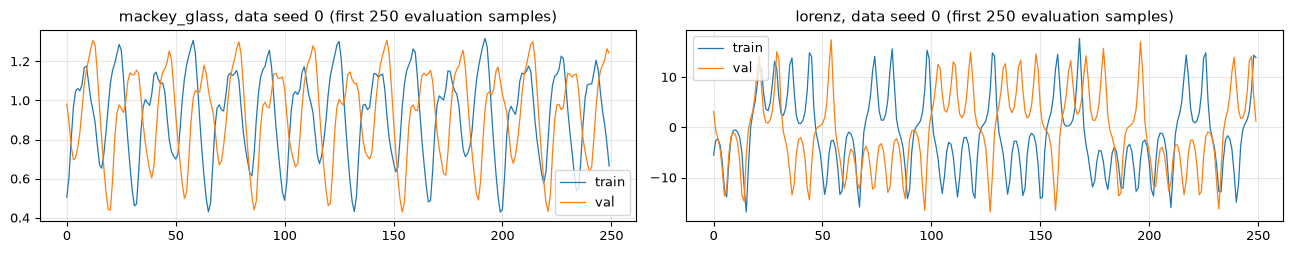

In [8]:
CFG = dict(horizons=(1, 5, 10), nontrivial=(5, 10), d_grid=(4, 8, 16, 24, 32), d_max=32, washout=50,
           n_train=1200, n_val=400, n_test=600, n_train_screen=600, n_val_screen=300,
           data_seeds=(0, 1, 2), res_seeds=(0, 1, 2), p_primary=2, p_all=(1, 2, 3), m_grid=(16, 32, 64),
           bw_grid=(0.5, 1.0, 2.0), max_poly=600, projections=('rrr', 'pls', 'pca'), proxy_lags=8, shortlist=3,
           kappa_dense=tuple(round(float(k), 6) for k in np.geomspace(0.02, 100, 24)), diag_seeds={6: 12, 7: 8, 8: 5},
           n_band_points=3, reps_ref=4, reps_sweep=(1, 2, 8, 16), kappa_memory_grid=(4.5, 6.8, 9.8, 12.0, 21.0),
           reps_memory_grid=(1, 2, 4), tamc_lags=10, k_mc=15, k2=6, k3=4,
           cap=dict(washout=50, n_tr=800, n_va=300, n_te=300), n_boot=2000, block_min=40, alphas=tuple(np.logspace(-6, 3, 10)))
if SMOKE:
    CFG.update(n_train=300, n_val=150, n_test=150, n_train_screen=200, n_val_screen=100, data_seeds=(0, 1), res_seeds=(0, 1),
               d_grid=(4, 8), m_grid=(16,), bw_grid=(1.0,), kappa_dense=CFG['kappa_dense'][::3], diag_seeds={6: 3, 7: 3, 8: 2},
               reps_sweep=(1, 8), kappa_memory_grid=(6.8, 12.0), reps_memory_grid=(1, 2), cap=dict(washout=50, n_tr=200, n_va=100, n_te=100),
               n_boot=100)
HZ, NT = CFG['horizons'], CFG['nontrivial']
SEEDS, RSEEDS = CFG['data_seeds'], CFG['res_seeds']
DATASETS = ('mackey_glass', 'lorenz')
SALT = 6006
SPLIT_ID = {'train': 0, 'val': 1, 'test': 2}


def mackey_glass(n, ss, beta=0.2, gamma=0.1, n_exp=10, tau=17.0, dt=0.1, every=30, transient=3000.0):
    rng = np.random.default_rng(ss)
    H = int(round(tau / dt)); n_tr = int(round(transient / dt)); total = n_tr + n * every + 1
    x = np.empty(total + H)
    x[:H + 1] = rng.uniform(0.5, 1.3) + rng.uniform(-0.05, 0.05, H + 1)
    f = lambda a, ad: beta * ad / (1.0 + ad ** n_exp) - gamma * a
    for i in range(H, total + H - 1):
        d0, d1 = x[i - H], x[i - H + 1]; dm = 0.5 * (d0 + d1); xi = x[i]
        k1 = f(xi, d0); k2 = f(xi + .5 * dt * k1, dm); k3 = f(xi + .5 * dt * k2, dm); k4 = f(xi + dt * k3, d1)
        x[i + 1] = xi + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return x[H + n_tr::every][:n]


def lorenz_x(n, ss, sigma=10.0, rho=28.0, beta=8 / 3, dt=0.01, every=10, transient=60.0):
    rng = np.random.default_rng(ss)
    X, Y, Z = rng.normal(0, 8, 3) + np.array([0.0, 0.0, 25.0])
    f = lambda x, y, z: (sigma * (y - x), x * (rho - z) - y, x * y - beta * z)
    n_tr = int(round(transient / dt)); out = np.empty(n); k = 0
    for i in range(n_tr + n * every):
        a1 = f(X, Y, Z); a2 = f(X + .5 * dt * a1[0], Y + .5 * dt * a1[1], Z + .5 * dt * a1[2])
        a3 = f(X + .5 * dt * a2[0], Y + .5 * dt * a2[1], Z + .5 * dt * a2[2]); a4 = f(X + dt * a3[0], Y + dt * a3[1], Z + dt * a3[2])
        X += dt / 6 * (a1[0] + 2 * a2[0] + 2 * a3[0] + a4[0]); Y += dt / 6 * (a1[1] + 2 * a2[1] + 2 * a3[1] + a4[1])
        Z += dt / 6 * (a1[2] + 2 * a2[2] + 2 * a3[2] + a4[2])
        if i >= n_tr and (i - n_tr) % every == 0:
            out[k] = X; k += 1
    return out


GEN = {'mackey_glass': mackey_glass, 'lorenz': lorenz_x}


@dataclass
class Trajectory:
    x: np.ndarray
    split: str
    data_seed: int
    d_max: int = 32
    washout: int = 50
    h_max: int = 10

    @property
    def t0(self):
        return self.d_max - 1

    @property
    def t_end(self):
        return len(self.x) - self.h_max

    @property
    def drive_idx(self):
        return np.arange(self.t0, self.t_end)

    @property
    def eval_idx(self):
        return np.arange(self.t0 + self.washout, self.t_end)

    def target(self, h, n=None):
        e = self.eval_idx if n is None else self.eval_idx[:n]
        return self.x[e + h]


def make_traj(ds, seed, split, seed_offset=0):
    n = CFG[f'n_{split}']
    raw = GEN[ds](CFG['d_max'] - 1 + CFG['washout'] + n + max(HZ), np.random.SeedSequence([SALT, DATASETS.index(ds), seed + seed_offset, SPLIT_ID[split]]))
    assert np.all(np.isfinite(raw))
    return Trajectory(raw, split, seed, CFG['d_max'], CFG['washout'], max(HZ))


T0 = time.perf_counter()
DEV = {ds: {s: {sp: make_traj(ds, s, sp) for sp in ('train', 'val')} for s in SEEDS} for ds in DATASETS}
print(f'development trajectories generated in {time.perf_counter() - T0:.1f}s; test trajectories do not exist yet')
fig, ax = plt.subplots(1, 2, figsize=(13, 2.6))
for a, ds in zip(ax, DATASETS):
    for sp in ('train', 'val'):
        t = DEV[ds][SEEDS[0]][sp]; a.plot(t.x[t.eval_idx][:250], lw=0.9, label=sp)
    a.set_title(f'{ds}, data seed {SEEDS[0]} (first 250 evaluation samples)'); a.legend()
plt.tight_layout(); plt.show()

## 6. Causal preprocessing

Rules for every split and model:
- **Delay vectors** are $\mathbf s^{(d)}_t=[x_t,\dots,x_{t-d+1}]$, built only at indices with a complete window.
- **Targets** $x_{t+h}$ ($h\ge1$) lie strictly after the window.
- **Scoring:** every model is scored on the identical `eval_idx`.
- **Fitting:** all scalers, dictionaries, projections and MinMax scalings are fitted on the training trajectory of the
  same data seed.
- **Independence:** trajectories are checked to share no 32-sample segment.

In [9]:
def windows(x, d, idx):
    idx = np.asarray(idx)
    assert idx.min() - (d - 1) >= 0, 'incomplete delay window'
    return np.stack([x[idx - k] for k in range(d)], 1)


def shuffled_windows(x, d, idx, seed):
    S = windows(x, d, idx)
    if d > 1:
        S[:, 1:] = S[np.random.default_rng(seed).permutation(len(idx)), 1:]
    return S


def lag_stack(Z, n):
    Z = np.asarray(Z); Z = Z[:, None] if Z.ndim == 1 else Z
    out = [Z]
    for k in range(1, n):
        s = np.zeros_like(Z); s[k:] = Z[:-k]; out.append(s)
    return np.concatenate(out, 1)


def min_segment_distance(a, b, L=32):
    A, B = np.lib.stride_tricks.sliding_window_view(a, L), np.lib.stride_tricks.sliding_window_view(b, L)
    return min(float(np.abs(A[i:i + 256, None] - B[None]).max(-1).min()) for i in range(0, len(A), 256))


x = np.arange(100.0); W_ = windows(x, 8, np.arange(40, 50))
check('delay windows are causal: column k is x_{t-k}', all(np.array_equal(W_[:, k], x[np.arange(40, 50) - k]) for k in range(8)))
for ds in DATASETS:
    for s in SEEDS:
        tr = DEV[ds][s]
        for sp, t in tr.items():
            ev = t.eval_idx
            assert len(ev) == CFG[f'n_{sp}'] and ev.min() >= CFG['d_max'] - 1 and ev.max() + max(HZ) < len(t.x)
        dmin = min_segment_distance(tr['train'].x, tr['val'].x)
        check(f'{ds} seed {s}: train/val share no 32-sample segment (min distance {dmin:.3g})', dmin > 1e-6)
check('targets x_{t+h} are strictly after every window end (h >= 1)', min(HZ) >= 1)

  [PASS] delay windows are causal: column k is x_{t-k}
  [PASS] mackey_glass seed 0: train/val share no 32-sample segment (min distance 0.0046)
  [PASS] mackey_glass seed 1: train/val share no 32-sample segment (min distance 0.0105)


  [PASS] mackey_glass seed 2: train/val share no 32-sample segment (min distance 0.00428)
  [PASS] lorenz seed 0: train/val share no 32-sample segment (min distance 0.629)
  [PASS] lorenz seed 1: train/val share no 32-sample segment (min distance 0.903)


  [PASS] lorenz seed 2: train/val share no 32-sample segment (min distance 0.0247)
  [PASS] targets x_{t+h} are strictly after every window end (h >= 1)


## 7. Kernel dictionaries

Dictionaries $\Psi_t$ of the standardised window $\mathbf s^{(d)}_t$, fitted on train only:
- RBF features $\exp(-\gamma\lVert \mathbf s-c_j\rVert^2)$, with $m\in\{16,32,64\}$ centres Nyström-sampled from
  distinct training windows and $\gamma=b/(2\,\mathrm{median}^2)$ for $b\in\{0.5,1,2\}$;
- degree-2 polynomial features;
- degree-3 polynomial features when the count is ≤ 600;
- the *linear* dictionary (the standardised window itself), the base of every dimension-matched linear control.

$\Psi$ is standardised with training statistics.

In [10]:
def poly_count(d, deg):
    from math import comb
    return comb(d + deg, deg) - 1


@dataclass(frozen=True)
class DictSpec:
    family: str     # 'linear' | 'rbf' | 'poly2' | 'poly3'
    d: int
    m: int = 0
    bw: float = 1.0

    @property
    def name(self):
        return {'rbf': f'rbf[m={self.m},bw={self.bw:g}]'}.get(self.family, self.family) + f'|d={self.d}'


class Dictionary:
    """Train-only causal dictionary.  Same construction as notebook 5 (centres from distinct
    standardised training windows, rng seed 0; median heuristic on <=800 windows)."""

    def __init__(self, spec, x, idx, S_override=None):
        self.spec = spec
        S = windows(x, spec.d, idx) if S_override is None else S_override
        self.w_mu, self.w_sd = S.mean(0), np.where(S.std(0) < 1e-12, 1, S.std(0))
        Ss = (S - self.w_mu) / self.w_sd
        rng = np.random.default_rng(0)
        if spec.family == 'rbf':
            uniq = np.unique(np.round(Ss, 12), axis=0)
            self.centres = uniq[rng.choice(len(uniq), spec.m, replace=False)]
            sub = Ss[rng.choice(len(Ss), min(len(Ss), 800), replace=False)]
            dist = np.sqrt(((sub[:, None] - sub[None]) ** 2).sum(-1))
            self.gamma = spec.bw / (2 * np.median(dist[np.triu_indices(len(sub), 1)]) ** 2)
        elif spec.family in ('poly2', 'poly3'):
            assert poly_count(spec.d, int(spec.family[-1])) <= CFG['max_poly']
            self.poly = PolynomialFeatures(int(spec.family[-1]), include_bias=False).fit(Ss)
        P = self._raw(S)
        assert np.all(np.isfinite(P))
        self.mu, self.sd = P.mean(0), np.where(P.std(0) < 1e-12, 1, P.std(0))
        self.fit_rows = len(S)

    def _raw(self, S):
        Ss = (S - self.w_mu) / self.w_sd
        if self.spec.family == 'linear':
            return Ss
        if self.spec.family == 'rbf':
            return np.exp(-self.gamma * ((Ss[:, None, :] - self.centres[None]) ** 2).sum(-1))
        return self.poly.transform(Ss)

    def psi(self, x, idx, S_override=None):
        S = windows(x, self.spec.d, idx) if S_override is None else S_override
        return (self._raw(S) - self.mu) / self.sd

    def gram_checks(self):
        if self.spec.family != 'rbf':
            return {'ok': True}
        d2 = ((self.centres[:, None] - self.centres[None]) ** 2).sum(-1); off = ~np.eye(len(d2), dtype=bool)
        K = np.exp(-self.gamma * d2)
        return {'ok': bool(0.001 < K[off].mean() < 0.99 and np.sqrt(d2[off].min()) > 1e-8),
                'offdiag_mean': float(K[off].mean()), 'min_centre_dist': float(np.sqrt(d2[off].min()))}


def dict_specs():
    out = []
    for d in CFG['d_grid']:
        out += [DictSpec('rbf', d, m, bw) for m in CFG['m_grid'] for bw in CFG['bw_grid']]
        out += [DictSpec(f, d) for f in ('poly2', 'poly3') if poly_count(d, int(f[-1])) <= CFG['max_poly']]
    return out


print(len(dict_specs()), 'nonlinear dictionaries per data seed:', sorted({s.family for s in dict_specs()}),
      '| delays', CFG['d_grid'])

52 nonlinear dictionaries per data seed: ['poly2', 'poly3', 'rbf'] | delays (4, 8, 16, 24, 32)


## 8. Task-aware multidimensional projection

From the standardised dictionary $\Psi_t$, a train-only projection $z_t=W^\top\Psi_t\in\mathbb R^p$ is learned
against a **multi-objective target**, with each block standardised and weighted to unit total variance:
1. the futures $x_{t+1},x_{t+5},x_{t+10}$;
2. the leading 4 train-PCA coordinates of $\mathbf s^{(d)}_t$ (delay-state preservation);
3. the leading 2 train-PCA coordinates of $\Psi_{t+1}$ (dynamical closure).

Projection methods:
- **rrr** – reduced-rank ridge regression (top-*p* singular directions of the ridge fit);
- **pls** – partial least squares (*p* components);
- **pca** – the unsupervised control;
- **pred** / **pred1** – notebook 5's scalar projections (top singular direction of $\Psi\mapsto x_{t+1..t+10}$, or
  $x_{t+1..t+p}$), used only to rebuild the notebook-5 models and the scalar baseline.

Validation metrics, all fitted on train:
- future sufficiency $R^2_{\rm future}$ (linear $z_t\mapsto[x_{t+1},x_{t+5},x_{t+10}]$);
- delay-state sufficiency $R^2_{\rm history}$ (linear decoder $z_t\mapsto\mathbf s^{(d)}_t$, averaged over taps);
- one-step closure error of $z_{t+1}\approx Az_t+b$, and 10-step rollout error;
- effective rank, standardised condition number, minimum relative coordinate scale and collapse fraction;
- a linear fading-memory proxy (ridge on the last 8 values of $z$);
- full-dictionary kernel ridge.

In [11]:
def fit_ridge(Xtr, Ytr, Xva=None, Yva=None, alphas=CFG['alphas'], alpha=None):
    """Closed-form ridge on train-standardised X; alpha per target chosen on validation."""
    Xtr = np.asarray(Xtr, float); Y = np.asarray(Ytr, float); one = Y.ndim == 1; Y = Y[:, None] if one else Y
    mu, sd = Xtr.mean(0), np.where(Xtr.std(0) < 1e-12, 1, Xtr.std(0)); Xs = (Xtr - mu) / sd; ym = Y.mean(0)
    U, S, Vt = np.linalg.svd(Xs, full_matrices=False); UtY = U.T @ (Y - ym)
    if alpha is not None:
        best = np.full(Y.shape[1], float(alpha))
    else:
        Yv = np.asarray(Yva, float); Yv = Yv[:, None] if Yv.ndim == 1 else Yv
        XvV = ((np.asarray(Xva, float) - mu) / sd) @ Vt.T
        errs = np.array([np.mean((XvV @ ((S / (S ** 2 + a))[:, None] * UtY) + ym - Yv) ** 2, 0) for a in alphas])
        best = np.asarray(alphas)[np.argmin(errs, 0)]
    W = np.empty((Xs.shape[1], Y.shape[1]))
    for a in np.unique(best):
        c = best == a; W[:, c] = Vt.T @ ((S / (S ** 2 + a))[:, None] * UtY[:, c])
    pred = lambda X: ((np.asarray(X) - mu) / sd) @ W + ym
    return (lambda X: pred(X)[:, 0]) if one else pred, best


def r2_cols(P, Y):
    return 1 - np.mean((P - Y) ** 2, 0) / (np.var(Y, 0) + 1e-12)


def nrmse_(p, y):
    return float(np.sqrt(np.mean((np.asarray(p) - y) ** 2)) / (np.std(y) + 1e-12))


def all_metrics(p, y):
    p, y = np.asarray(p), np.asarray(y); mse = np.mean((p - y) ** 2)
    return {'nrmse': nrmse_(p, y), 'rmse': float(np.sqrt(mse)), 'mae': float(np.mean(np.abs(p - y))),
            'r2': float(1 - mse / np.var(y)), 'pearson': float(np.corrcoef(p, y)[0, 1]) if np.std(p) > 0 else float('nan')}


@dataclass(frozen=True)
class LiftSpec:
    dict_spec: DictSpec
    proj: str = 'rrr'      # 'rrr' | 'pls' | 'pca' | 'pred' | 'pred1' | 'raw' | 'dupraw'
    p: int = 2

    @property
    def name(self):
        if self.proj in ('raw', 'dupraw'):
            return f'{self.proj}(p={self.p})'
        return f'{self.dict_spec.name}|{self.proj}|p={self.p}'

    @property
    def nonlinear(self):
        return self.dict_spec.family in ('rbf', 'poly2', 'poly3')

    def linear_counterpart(self):
        return LiftSpec(DictSpec('linear', self.dict_spec.d), self.proj, self.p)


def projection_targets(dic, x, idx):
    F = np.stack([x[idx + h] for h in (1, 5, 10)], 1)
    S = windows(x, dic.spec.d, idx); Ss = (S - S.mean(0)) / np.where(S.std(0) < 1e-12, 1, S.std(0))
    Sp = PCA(min(4, dic.spec.d)).fit_transform(Ss)
    Pp = PCA(2).fit_transform(dic.psi(x, idx + 1))
    blocks = [F, Sp, Pp]
    return np.concatenate([((b - b.mean(0)) / b.std(0)) / np.sqrt(b.shape[1]) for b in blocks], 1)


def fit_projection(Ps, x, idx, dic, method, p, alpha=1.0):
    if method == 'pca':
        W = PCA(p).fit(Ps).components_.T
    elif method in ('rrr', 'pls'):
        T = projection_targets(dic, x, idx)
        if method == 'rrr':
            B = np.linalg.solve(Ps.T @ Ps + alpha * np.eye(Ps.shape[1]), Ps.T @ (T - T.mean(0)))
            W = B @ np.linalg.svd(Ps @ B, full_matrices=False)[2][:p].T
        else:
            W = PLSRegression(n_components=p, scale=False).fit(Ps, T).x_rotations_
    else:   # notebook 5 'pred' (x_{t+1..t+10}) / 'pred1' (x_{t+1..t+p})
        H = 10 if method == 'pred' else p
        F = np.stack([x[idx + k] for k in range(1, H + 1)], 1); F = (F - F.mean(0)) / F.std(0)
        B = np.linalg.solve(Ps.T @ Ps + alpha * np.eye(Ps.shape[1]), Ps.T @ F)
        W = B @ np.linalg.svd(Ps @ B, full_matrices=False)[2][:p].T
    Z = Ps @ W
    sgn = np.sign([np.corrcoef(Z[:, j], x[idx + 1])[0, 1] or 1.0 for j in range(W.shape[1])])
    return W * np.where(sgn == 0, 1, sgn)


class Lifter:
    """Full train-only interface: dictionary -> projection W -> MinMax [0,1] (QRC encoding scale)."""

    def __init__(self, spec, tr, dic=None, S_override=None):
        self.spec = spec
        idx = tr.eval_idx
        if spec.proj in ('raw', 'dupraw'):
            xs = tr.x[tr.drive_idx]; self.lo, self.hi = float(xs.min()), float(xs.max()); return
        self.dic = dic if dic is not None else Dictionary(spec.dict_spec, tr.x, idx, S_override)
        Ps = self.dic.psi(tr.x, idx, S_override)
        self.W = fit_projection(Ps, tr.x, idx, self.dic, spec.proj, spec.p)
        Z = Ps @ self.W
        self.zmin, self.zmax = Z.min(0), Z.max(0)
        self.fit_rows = len(idx)

    def zraw(self, t, idx, S_override=None):
        return self.dic.psi(t.x, idx, S_override) @ self.W

    def encode(self, t, S_override=None, drop=None):
        """QRC input over the drive indices, scaled with TRAIN statistics; returns (z, clipped fraction)."""
        if self.spec.proj == 'raw':
            Z = (windows(t.x, self.spec.p, t.drive_idx) - self.lo) / (self.hi - self.lo)
        elif self.spec.proj == 'dupraw':
            Z = np.repeat(((t.x[t.drive_idx] - self.lo) / (self.hi - self.lo))[:, None], self.spec.p, 1)
        else:
            Z = (self.zraw(t, t.drive_idx, S_override) - self.zmin) / np.where(self.zmax - self.zmin < 1e-12, 1, self.zmax - self.zmin)
        clip = float(np.mean((Z < 0) | (Z > 1)))
        Z = np.clip(Z, 0, 1)
        if drop is not None:                       # leave-one-coordinate-out: hold coordinate at its train-range midpoint
            Z = Z.copy(); Z[:, drop] = 0.5
        return Z, clip


def interface_metrics(lf, tr, va):
    """Validation sufficiency / closure / non-collapse metrics of a fitted p-dim interface."""
    d = lf.spec.dict_spec.d
    it, iv = tr.eval_idx[:-1], va.eval_idx[:-1]
    Zt, Zv = lf.zraw(tr, it), lf.zraw(va, iv)
    zsd = Zt.std(0); Zt_s, Zv_s = (Zt - Zt.mean(0)) / np.where(zsd < 1e-300, 1, zsd), (Zv - Zt.mean(0)) / np.where(zsd < 1e-300, 1, zsd)
    Ft = np.stack([tr.x[it + h] for h in (1, 5, 10)], 1); Fv = np.stack([va.x[iv + h] for h in (1, 5, 10)], 1)
    fut = float(np.mean(r2_cols(fit_ridge(Zt_s, Ft, alpha=1e-6)[0](Zv_s), Fv)))
    hist = float(np.mean(r2_cols(fit_ridge(Zt_s, windows(tr.x, d, it), alpha=1e-6)[0](Zv_s), windows(va.x, d, iv))))
    Z1t, Z1v = lf.zraw(tr, it + 1), lf.zraw(va, iv + 1)
    A, _ = fit_ridge(Zt, Z1t, alpha=1e-8)
    rel = lambda E, T: float(np.sum(E ** 2) / (np.sum((T - T.mean(0)) ** 2) + 1e-300))
    closure = rel(A(Zv) - Z1v, Z1v)
    i10 = va.eval_idx[:-10]; cur = lf.zraw(va, i10)
    for _ in range(10):
        cur = A(cur)
    roll = rel(cur - lf.zraw(va, i10 + 10), lf.zraw(va, i10 + 10)) if np.all(np.isfinite(cur)) else float('inf')
    s = np.linalg.svd(Zt_s, compute_uv=False)
    rank = int(np.sum(s > 1e-6 * s[0])); cond = float(s[0] / max(s[-1], 1e-300))
    nn = NearestNeighbors(n_neighbors=2).fit(Zv_s); dist, ind = nn.kneighbors(Zv_s)
    collapse = float(np.mean((dist[:, 1] < 1e-6) & (np.abs(Fv[:, 1] - Fv[ind[:, 1], 1]) > 0.5 * Fv[:, 1].std())))
    return {'future_r2': fut, 'history_r2': hist, 'closure_err': closure, 'rollout10_err': roll, 'eff_rank': rank,
            'cond': cond, 'min_rel_scale': float(zsd.min() / zsd.max()), 'collapse_frac': collapse}


def readout(F, trajs, n_lim=None, out=('val',)):
    """Ridge readout: fit on train eval rows, alpha per horizon on validation."""
    nl = n_lim or {}
    Y = np.stack([trajs['train'].target(h, nl.get('train')) for h in HZ], 1)
    Yv = np.stack([trajs['val'].target(h, nl.get('val')) for h in HZ], 1)
    f, alpha = fit_ridge(F['train'], Y, F['val'], Yv)
    return {sp: f(F[sp]) for sp in out}, alpha


def unit_nrmse(preds, trajs, split, n=None):
    return {h: nrmse_(preds[split][:, k], trajs[split].target(h, n)) for k, h in enumerate(HZ)}


def proxy_val(z, trajs, n_lim=None):
    W = CFG['washout']; nl = n_lim or {}
    F = {sp: lag_stack(z[sp], CFG['proxy_lags'])[W:W + nl[sp] if sp in nl else None] for sp in ('train', 'val')}
    pr, _ = readout(F, trajs, n_lim)
    return unit_nrmse(pr, trajs, 'val', nl.get('val'))


def kernel_only_val(dic, trajs, out=('val',)):
    F = {sp: dic.psi(t.x, t.eval_idx) for sp, t in trajs.items()}
    pr, _ = readout(F, trajs, out=out)
    return pr

In [12]:
SCREEN = {ds: [] for ds in DATASETS}
t0 = time.perf_counter()
for ds in DATASETS:
    for dspec in dict_specs():
        per = []
        for s in SEEDS:
            tr, va = DEV[ds][s]['train'], DEV[ds][s]['val']
            dic = Dictionary(dspec, tr.x, tr.eval_idx)
            ko = kernel_only_val(dic, DEV[ds][s])
            ko = float(np.mean(list(unit_nrmse(ko, DEV[ds][s], 'val').values())))
            sc = Lifter(LiftSpec(dspec, 'pred', 1), tr, dic)
            base = interface_metrics(sc, tr, va)
            rows = {}
            for proj in CFG['projections']:
                for p in CFG['p_all']:
                    lf = Lifter(LiftSpec(dspec, proj, p), tr, dic)
                    m = interface_metrics(lf, tr, va)
                    z = {sp: lf.encode(t)[0] for sp, t in DEV[ds][s].items()}
                    m['proxy_val'] = float(np.mean(list(proxy_val(z, DEV[ds][s]).values())))
                    rows[(proj, p)] = m
            per.append({'ko': ko, 'base': base, 'rows': rows, 'gram': dic.gram_checks()['ok']})
        for (proj, p) in per[0]['rows']:
            agg = {k: float(np.median([r['rows'][(proj, p)][k] for r in per])) for k in per[0]['rows'][(proj, p)]}
            agg['eff_rank'] = int(min(r['rows'][(proj, p)]['eff_rank'] for r in per))
            base_f, base_h = np.median([r['base']['future_r2'] for r in per]), np.median([r['base']['history_r2'] for r in per])
            reasons = []
            if agg['min_rel_scale'] < 1e-6: reasons.append('near-constant coordinate')
            if agg['eff_rank'] < p: reasons.append('rank<p')
            if agg['cond'] > 1e4: reasons.append('ill-conditioned')
            if agg['collapse_frac'] > 0.01: reasons.append('collapse')
            if not all(r['gram'] for r in per): reasons.append('gram')
            if agg['future_r2'] < base_f - 0.05 or agg['history_r2'] < base_h - 0.05: reasons.append('worse than scalar')
            SCREEN[ds].append({'spec': LiftSpec(dspec, proj, p), 'name': LiftSpec(dspec, proj, p).name, 'dict': dspec.name,
                               'proj': proj, 'p': p, **agg, 'kernel_only_val': float(np.median([r['ko'] for r in per])),
                               'scalar_future_r2': float(base_f), 'scalar_history_r2': float(base_h),
                               'rejected': bool(reasons), 'reasons': ','.join(reasons)})
    # linear counterparts (same d, projection, p)
    for d in CFG['d_grid']:
        for proj in CFG['projections']:
            for p in CFG['p_all']:
                per = []
                for s in SEEDS:
                    tr, va = DEV[ds][s]['train'], DEV[ds][s]['val']
                    lf = Lifter(LiftSpec(DictSpec('linear', d), proj, p), tr)
                    m = interface_metrics(lf, tr, va)
                    m['proxy_val'] = float(np.mean(list(proxy_val({sp: lf.encode(t)[0] for sp, t in DEV[ds][s].items()}, DEV[ds][s]).values())))
                    per.append(m)
                agg = {k: float(np.median([r[k] for r in per])) for k in per[0]}
                agg['eff_rank'] = int(min(r['eff_rank'] for r in per))
                spec = LiftSpec(DictSpec('linear', d), proj, p)
                SCREEN[ds].append({'spec': spec, 'name': spec.name, 'dict': f'linear|d={d}', 'proj': proj, 'p': p, **agg,
                                   'rejected': False, 'reasons': ''})


def norm_rank(v, higher_better):
    v = np.asarray(v, float); order = np.argsort(np.argsort(-v if higher_better else v))
    return order / max(len(v) - 1, 1)


SHORT, STAGE1 = {}, {}
for ds in DATASETS:
    elig = [r for r in SCREEN[ds] if r['spec'].nonlinear and r['proj'] in ('rrr', 'pls') and r['p'] == CFG['p_primary'] and not r['rejected']]
    if not elig:
        print(f'  ** {ds}: every task-aware p=2 candidate was rejected; ranking all of them (flagged) **')
        elig = [r for r in SCREEN[ds] if r['spec'].nonlinear and r['proj'] in ('rrr', 'pls') and r['p'] == CFG['p_primary']]
    score = np.mean([norm_rank([r['future_r2'] for r in elig], True), norm_rank([r['history_r2'] for r in elig], True),
                     norm_rank([r['closure_err'] for r in elig], False), norm_rank([r['kernel_only_val'] for r in elig], False),
                     norm_rank([r['proxy_val'] for r in elig], False)], 0)
    for r, sc in zip(elig, score):
        r['stage1_score'] = float(sc)
    STAGE1[ds] = sorted(elig, key=lambda r: r['stage1_score'])
    SHORT[ds] = [r['spec'] for r in STAGE1[ds][:CFG['shortlist']]]
print(f'classical screening: {sum(len(v) for v in SCREEN.values())} interface candidates in {time.perf_counter() - t0:.0f}s')
for ds in DATASETS:
    nrej = sum(r['rejected'] for r in SCREEN[ds])
    print(f'\n=== {ds}: {len(SCREEN[ds])} candidates ({nrej} rejected); stage-1 ranking (p={CFG["p_primary"]}, task-aware) ===')
    print(f"{'candidate':34s} {'score':>5s} {'fut R2':>6s} {'hist R2':>7s} {'closure':>8s} {'kernel-only':>11s} {'proxy':>6s}")
    for r in STAGE1[ds][:8]:
        print(f"{r['name']:34s} {r['stage1_score']:5.3f} {r['future_r2']:6.3f} {r['history_r2']:7.3f} {r['closure_err']:8.1e} {r['kernel_only_val']:11.4f} {r['proxy_val']:6.3f}")
    print('SHORTLIST:', [s.name for s in SHORT[ds]])

classical screening: 1026 interface candidates in 150s

=== mackey_glass: 513 candidates (133 rejected); stage-1 ranking (p=2, task-aware) ===
candidate                          score fut R2 hist R2  closure kernel-only  proxy
rbf[m=64,bw=2]|d=8|rrr|p=2         0.192  0.852   0.873  1.7e-02      0.0257  0.200
rbf[m=64,bw=1]|d=8|rrr|p=2         0.212  0.833   0.890  1.6e-02      0.0417  0.203
rbf[m=32,bw=2]|d=8|rrr|p=2         0.248  0.852   0.870  1.5e-02      0.0525  0.208
rbf[m=32,bw=1]|d=8|rrr|p=2         0.256  0.832   0.889  1.5e-02      0.0572  0.220
rbf[m=64,bw=0.5]|d=8|rrr|p=2       0.260  0.808   0.905  1.5e-02      0.0523  0.225
rbf[m=32,bw=0.5]|d=8|rrr|p=2       0.290  0.806   0.902  1.4e-02      0.0667  0.230
rbf[m=64,bw=2]|d=16|rrr|p=2        0.300  0.828   0.820  1.1e-02      0.0281  0.227
rbf[m=64,bw=1]|d=16|rrr|p=2        0.302  0.810   0.832  9.3e-03      0.0354  0.247
SHORTLIST: ['rbf[m=64,bw=2]|d=8|rrr|p=2', 'rbf[m=64,bw=1]|d=8|rrr|p=2', 'rbf[m=32,bw=2]|d=8|rrr|p=2']

## 9. Scalar versus vector sufficiency (validation)

For each shortlisted dictionary, the table below compares:
- the full dictionary with linear ridge;
- notebook 5's scalar projection (`pred`, p = 1);
- the selected task-aware projection at p = 1, 2, 3;
- the dimension-matched linear delay projection;
- the PCA control.

The **test** version, the one the certificate uses, is computed after the lock (§16).


=== mackey_glass (validation, median over data seeds) ===
interface                                fut R2 hist R2  closure rank    cond proxy NRMSE
  full dictionary + ridge (rbf[m=64,bw=2]|d=8)                                           0.0257
  notebook-5 scalar pred p=1              0.565   0.325
  rbf[m=64,bw=2]|d=8|rrr|p=1              0.566   0.418  1.5e-01    1     1.0      0.3875
  rbf[m=64,bw=2]|d=8|rrr|p=2              0.852   0.873  1.7e-02    2     1.0      0.2000
  rbf[m=64,bw=2]|d=8|rrr|p=3              0.860   0.915  6.2e-02    3     1.0      0.1157
  linear|d=8|rrr|p=2                      0.739   0.927  2.1e-02    2     1.0      0.4064
  rbf[m=64,bw=2]|d=8|pca|p=2              0.739   0.906  2.3e-02    2     1.0      0.2922
  full dictionary + ridge (rbf[m=64,bw=1]|d=8)                                           0.0417
  notebook-5 scalar pred p=1              0.558   0.333
  rbf[m=64,bw=1]|d=8|rrr|p=1              0.556   0.425  1.5e-01    1     1.0      0.3999
  rbf[m

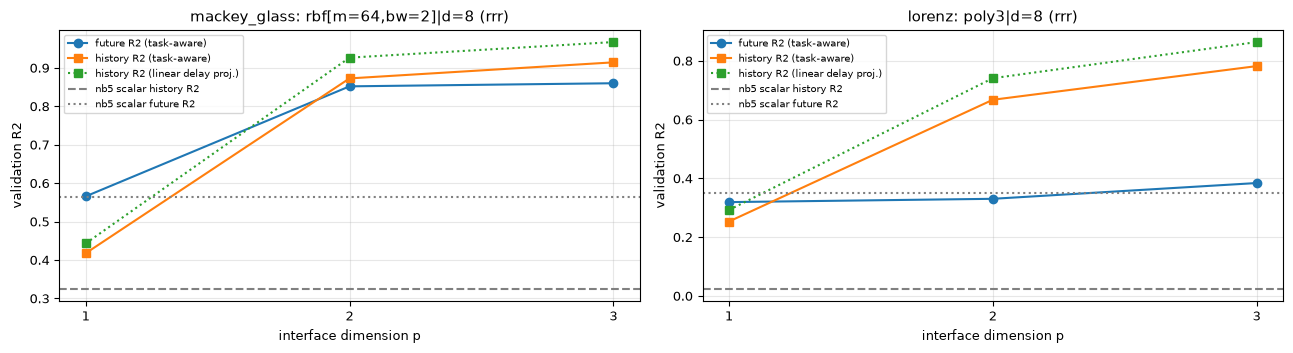

In [13]:
def row_of(ds, spec):
    m = [r for r in SCREEN[ds] if r['spec'] == spec]
    return m[0] if m else None


SV_ROWS = []
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, ds in zip(ax, DATASETS):
    print(f'\n=== {ds} (validation, median over data seeds) ===')
    print(f"{'interface':40s} {'fut R2':>6s} {'hist R2':>7s} {'closure':>8s} {'rank':>4s} {'cond':>7s} {'proxy NRMSE':>11s}")
    for k, spec in enumerate(SHORT[ds]):
        r0 = row_of(ds, spec)
        print(f"{'  full dictionary + ridge (' + spec.dict_spec.name + ')':40s} {'':>6s} {'':>7s} {'':>8s} {'':>4s} {'':>7s} {r0['kernel_only_val']:11.4f}")
        print(f"{'  notebook-5 scalar pred p=1':40s} {r0['scalar_future_r2']:6.3f} {r0['scalar_history_r2']:7.3f}")
        variants = [replace(spec, p=p) for p in CFG['p_all']] + [spec.linear_counterpart(), replace(spec, proj='pca')]
        for v in variants:
            r = row_of(ds, v)
            print(f"  {v.name:38s} {r['future_r2']:6.3f} {r['history_r2']:7.3f} {r['closure_err']:8.1e} {r['eff_rank']:4d} {r['cond']:7.1f} {r['proxy_val']:11.4f}")
            SV_ROWS.append({'dataset': ds, 'shortlist_rank': k, 'interface': v.name, **{c: r[c] for c in ('future_r2', 'history_r2', 'closure_err', 'eff_rank', 'cond', 'proxy_val')}})
    sp = SHORT[ds][0]
    ps = list(CFG['p_all'])
    a.plot(ps, [row_of(ds, replace(sp, p=p))['future_r2'] for p in ps], 'o-', label='future R2 (task-aware)')
    a.plot(ps, [row_of(ds, replace(sp, p=p))['history_r2'] for p in ps], 's-', label='history R2 (task-aware)')
    a.plot(ps, [row_of(ds, replace(sp.linear_counterpart(), p=p))['history_r2'] for p in ps], 's:', label='history R2 (linear delay proj.)')
    a.axhline(row_of(ds, sp)['scalar_history_r2'], color='gray', ls='--', label='nb5 scalar history R2')
    a.axhline(row_of(ds, sp)['scalar_future_r2'], color='gray', ls=':', label='nb5 scalar future R2')
    a.set_xticks(ps); a.set_xlabel('interface dimension p'); a.set_ylabel('validation R2'); a.set_title(f'{ds}: {sp.dict_spec.name} ({sp.proj})')
    a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 10. Edge diagnostics by QRC size, and the matched EOC reservoir

The edge band is **recalibrated at N = 6, 7 and 8**, using notebook 4's diagnostics on its single-layer and
reps-fold operators:
- Poisson/COE/CUE gap-ratio references at $d=2^N$;
- the adjacent-gap ratio ⟨r⟩;
- the operator entanglement $S_{\rm op}$;
- the OTOC scrambling time $t^\ast$.

Band rule (frozen): $\eta=(\langle r\rangle-r_P)/(r_{\rm CUE}-r_P)$ from the median over disorder seeds;
$\kappa_{\rm lo}$ is the largest κ with $\eta\ge0.9$, and $\kappa_{\rm hi}$ the first larger κ with $\eta\le0.1$.

The matched EOC for the primary p = 2 (N = 7) interface is selected on validation, using screening lengths and three
paired units:
1. κ from 3 log-spaced band points at `reps` = 4, crossed with the inputs raw $[x_t,x_{t-1}]$, the linear delay
   projection and the top-1 kernel;
2. `reps` ∈ {1, 2, 8, 16} at the best (κ, input);
3. a Haar control for comparison.

N=6: refs Poisson 0.382, COE 0.526, CUE 0.606 | edge band kappa in [3.569, 22.735]


N=7: refs Poisson 0.385, COE 0.527, CUE 0.596 | edge band kappa in [3.569, 32.925]


N=8: refs Poisson 0.379, COE 0.528, CUE 0.608 | edge band kappa in [5.169, 47.682]
diagnostics: 101s


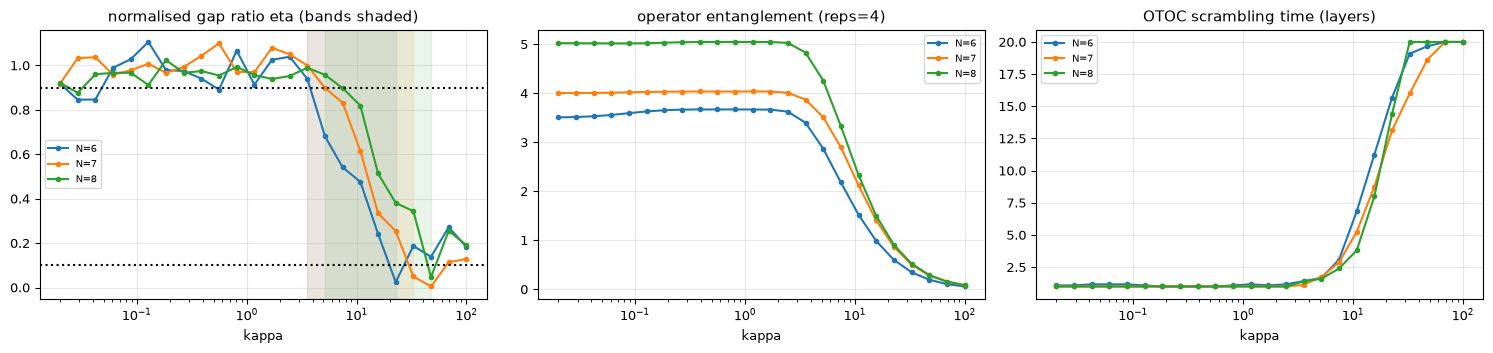

In [14]:
def kappa_diag(N, kappas, n_seeds, reps):
    p = N - N_MEMORY
    r = np.zeros((len(kappas), n_seeds)); sop = np.zeros_like(r); ts = np.zeros_like(r)
    for a, k in enumerate(kappas):
        for s in range(n_seeds):
            U1 = layer_unitary(mixed_config(p, k, 1, s))
            r[a, s] = level_spacing_ratio(U1)
            sop[a, s] = operator_entanglement(np.linalg.matrix_power(U1, reps), N)
            ts[a, s] = scrambling_time(U1, N, 0, N - 1)[0]
    return r, sop, ts


EDGE = {}
t0 = time.perf_counter()
for N in (6, 7, 8):
    refs = sample_reference_r_statistics(2 ** N, trials=60 if N < 8 else 30, seed=0)
    r, sop, ts = kappa_diag(N, CFG['kappa_dense'], CFG['diag_seeds'][N], CFG['reps_ref'])
    eta = (np.median(r, 1) - refs['poisson'][0]) / (refs['cue'][0] - refs['poisson'][0])
    ks = np.array(CFG['kappa_dense'])
    hi_ = np.where(eta >= 0.9)[0]
    i_lo = int(hi_.max()) if len(hi_) else int(np.argmax(eta))
    lo_ = np.where((np.arange(len(ks)) > i_lo) & (eta <= 0.1))[0]
    i_hi = int(lo_.min()) if len(lo_) else len(ks) - 1
    if not (len(hi_) and len(lo_)):
        print(f'  ** N={N}: eta thresholds not both crossed on this grid; band uses the fallback endpoints **')
    EDGE[N] = {'refs': refs, 'r': r, 'S_op': sop, 't_star': ts, 'eta': eta, 'band': (float(ks[i_lo]), float(ks[i_hi]))}
    print(f"N={N}: refs Poisson {refs['poisson'][0]:.3f}, COE {refs['coe'][0]:.3f}, CUE {refs['cue'][0]:.3f} | edge band kappa in "
          f"[{ks[i_lo]:.3f}, {ks[i_hi]:.3f}]")
print(f'diagnostics: {time.perf_counter() - t0:.0f}s')
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for N, c in zip((6, 7, 8), ('C0', 'C1', 'C2')):
    ks = CFG['kappa_dense']
    ax[0].plot(ks, EDGE[N]['eta'], 'o-', color=c, ms=3, label=f'N={N}')
    ax[0].axvspan(*EDGE[N]['band'], color=c, alpha=0.1)
    ax[1].plot(ks, EDGE[N]['S_op'].mean(1), 'o-', color=c, ms=3, label=f'N={N}')
    ax[2].plot(ks, EDGE[N]['t_star'].mean(1), 'o-', color=c, ms=3, label=f'N={N}')
for a, t in zip(ax, ('normalised gap ratio eta (bands shaded)', 'operator entanglement (reps=4)', 'OTOC scrambling time (layers)')):
    a.set_xscale('log'); a.set_xlabel('kappa'); a.set_title(t); a.legend(fontsize=7)
ax[0].axhline(0.9, ls=':', c='k'); ax[0].axhline(0.1, ls=':', c='k')
plt.tight_layout(); plt.show()

mackey_glass: kappa-scan (reps=4) 3.57/raw:0.0066, 3.57/linear:0.0073, 3.57/kernel:0.0064, 10.84/raw:0.0061, 10.84/linear:0.0067, 10.84/kernel:0.0052, 32.92/raw:0.1366, 32.92/linear:0.1282, 32.92/kernel:0.1832
   -> matched EOC (N=7): kappa=10.841 (band [3.57,32.92]), reps=4, input=kernel | reps 1: 0.0271, reps 2: 0.0058, reps 4: 0.0052, reps 8: 0.0058, reps 16: 0.0056 | Haar 0.0066
lorenz: kappa-scan (reps=4) 3.57/raw:0.4454, 3.57/linear:0.4597, 3.57/kernel:0.3960, 10.84/raw:0.5367, 10.84/linear:0.5567, 10.84/kernel:0.5238, 32.92/raw:0.9760, 32.92/linear:0.9427, 32.92/kernel:0.9037
   -> matched EOC (N=7): kappa=3.569 (band [3.57,32.92]), reps=16, input=kernel | reps 1: 0.4353, reps 2: 0.4167, reps 4: 0.3960, reps 8: 0.4236, reps 16: 0.3945 | Haar 0.3929
EOC selection: 367s


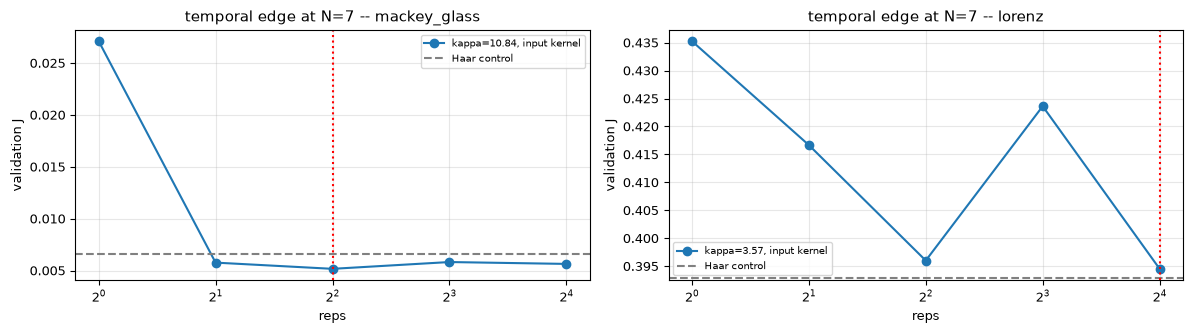

In [15]:
P = CFG['p_primary']
N_P = N_MEMORY + P
K_LO, K_HI = EDGE[N_P]['band']
BAND_PTS = tuple(round(float(k), 6) for k in np.geomspace(K_LO, K_HI, CFG['n_band_points']))
IN_BAND = lambda k: K_LO * (1 - 1e-9) <= k <= K_HI * (1 + 1e-9)
NL_SCREEN = {'train': CFG['n_train_screen'], 'val': CFG['n_val_screen']}
BUDGET = {'eoc_side': 0, 'memory_side': 0}


@dataclass
class Entry:
    unit: tuple
    cfg: MultiInputReservoirConfig
    z: dict
    trajs: dict
    tag: str = ''


INPUT_CACHE = {}


def inputs_for(ds, spec, s, trajs, S_mode=None, drop=None):
    key = (ds, spec, s, tuple(sorted(trajs)), S_mode, drop)
    if key not in INPUT_CACHE:
        if S_mode == 'shuffle':
            Sw = {sp: shuffled_windows(t.x, spec.dict_spec.d, t.drive_idx, seed=(s, SPLIT_ID[sp], 7)) for sp, t in trajs.items()}
            lf = Lifter(spec, trajs['train'], S_override=Sw['train'][trajs['train'].washout:])
            enc = {sp: lf.encode(t, S_override=Sw[sp]) for sp, t in trajs.items()}
        else:
            lf = Lifter(spec, trajs['train'])
            enc = {sp: lf.encode(t, drop=drop) for sp, t in trajs.items()}
        INPUT_CACHE[key] = (lf, {sp: v[0] for sp, v in enc.items()}, {sp: v[1] for sp, v in enc.items()})
    return INPUT_CACHE[key]


def entries(ds, spec, rc_fn, units, data, splits, n_lim=None, tag='', **kw):
    out = []
    W = CFG['washout']
    for s, rs in units:
        trajs = {sp: data[ds][s][sp] for sp in splits}
        lf, z, clip = inputs_for(ds, spec, s, trajs, **kw)
        z = {sp: (z[sp][:W + n_lim[sp]] if n_lim and sp in n_lim else z[sp]) for sp in splits}
        out.append(Entry((s, rs), rc_fn(rs), z, trajs, tag))
    return out


def run_groups(groups, splits=('train', 'val'), n_lim=None):
    flat = [e for g in groups.values() for e in g]
    X = run_qrc_jobs([QRCJob(e.cfg, e.z[sp]) for e in flat for sp in splits])
    res, k, W = {}, 0, CFG['washout']
    nl = n_lim or {}
    for tag, g in groups.items():
        lst = []
        for e in g:
            F = {}
            for sp in splits:
                F[sp] = X[k][W:]; k += 1
            outs = tuple(sp for sp in splits if sp != 'train')
            pr, alpha = readout(F, e.trajs, n_lim, outs)
            lst.append({'unit': e.unit, 'cfg': e.cfg, 'preds': pr, 'alpha': alpha, 'F_val': F.get('val'), 'z_val': e.z.get('val'),
                        'nrmse': {sp: unit_nrmse(pr, e.trajs, sp, nl.get(sp)) for sp in outs}})
        res[tag] = lst
    return res


def J(results, split='val'):
    return float(np.median([np.mean([r['nrmse'][split][h] for h in HZ]) for r in results]))


PAIRED = [(s, s % len(RSEEDS) if s >= len(RSEEDS) else RSEEDS[s]) for s in SEEDS]
rc_k = lambda k, reps, p=P: (lambda rs: mixed_config(p, k, reps, rs))
TOP1 = {ds: SHORT[ds][0] for ds in DATASETS}
EOC_INPUTS = {ds: {'raw': LiftSpec(DictSpec('linear', 1), 'raw', P), 'linear': TOP1[ds].linear_counterpart(), 'kernel': TOP1[ds]} for ds in DATASETS}
g = {(ds, k, nm): entries(ds, sp, rc_k(k, CFG['reps_ref']), PAIRED, DEV, ('train', 'val'), NL_SCREEN)
     for ds in DATASETS for k in BAND_PTS for nm, sp in EOC_INPUTS[ds].items()}
t0 = time.perf_counter()
KSCAN = run_groups(g, n_lim=NL_SCREEN)
BUDGET['eoc_side'] += len(g)
EOC = {}
g2 = {}
for ds in DATASETS:
    (kb, ib) = min(((k, nm) for k in BAND_PTS for nm in EOC_INPUTS[ds]), key=lambda t: J(KSCAN[(ds, t[0], t[1])]))
    EOC[ds] = {'kappa': kb, 'input': ib, 'J': {(kb, CFG['reps_ref']): J(KSCAN[(ds, kb, ib)])}}
    for r_ in CFG['reps_sweep']:
        g2[(ds, r_)] = entries(ds, EOC_INPUTS[ds][ib], rc_k(kb, r_), PAIRED, DEV, ('train', 'val'), NL_SCREEN)
    g2[(ds, 'haar')] = entries(ds, EOC_INPUTS[ds][ib], lambda rs: haar_config(P, rs), PAIRED, DEV, ('train', 'val'), NL_SCREEN)
TSCAN = run_groups(g2, n_lim=NL_SCREEN)
BUDGET['eoc_side'] += len(g2)
for ds in DATASETS:
    for r_ in CFG['reps_sweep']:
        EOC[ds]['J'][(EOC[ds]['kappa'], r_)] = J(TSCAN[(ds, r_)])
    EOC[ds]['J_haar'] = J(TSCAN[(ds, 'haar')])
    (k_, r_) = min(EOC[ds]['J'], key=EOC[ds]['J'].get)
    EOC[ds].update(reps=r_, cfg_fn=rc_k(k_, r_), inside_band=IN_BAND(k_))
    print(f"{ds}: kappa-scan (reps={CFG['reps_ref']}) " + ', '.join(f"{k:.2f}/{nm}:{J(KSCAN[(ds, k, nm)]):.4f}" for k in BAND_PTS for nm in EOC_INPUTS[ds]))
    print(f"   -> matched EOC (N={N_P}): kappa={EOC[ds]['kappa']:.3f} (band [{K_LO:.2f},{K_HI:.2f}]), reps={EOC[ds]['reps']}, input={EOC[ds]['input']} | "
          + ', '.join(f'reps {rr}: {v:.4f}' for (_, rr), v in sorted(EOC[ds]['J'].items(), key=lambda kv: kv[0][1])) + f" | Haar {EOC[ds]['J_haar']:.4f}")
print(f'EOC selection: {time.perf_counter() - t0:.0f}s')
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for a, ds in zip(ax, DATASETS):
    rr = sorted(r_ for (_, r_) in EOC[ds]['J'])
    a.plot(rr, [EOC[ds]['J'][(EOC[ds]['kappa'], r_)] for r_ in rr], 'o-', label=f"kappa={EOC[ds]['kappa']:.2f}, input {EOC[ds]['input']}")
    a.axhline(EOC[ds]['J_haar'], color='gray', ls='--', label='Haar control'); a.axvline(EOC[ds]['reps'], color='r', ls=':')
    a.set_xscale('log', base=2); a.set_xlabel('reps'); a.set_ylabel('validation J'); a.set_title(f'temporal edge at N={N_P} -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 11. Generic MC, nonlinear IPC and task-aligned memory capacity (TAMC)

**Generic capacities.** The input is i.i.d. $u_t\in[0,1]^p$; the reservoir does not see forecasting data.
- MC is the sum over channels and lags $k\le15$ of the clipped held-out $R^2$.
- $IPC_2$ and $IPC_3$ sum the capacities of orthonormal Legendre products (same-channel, cross-channel and
  mixed-delay; lags ≤ 6 and ≤ 4).
- IPC capacities below a null threshold are zeroed. The threshold is the 99th percentile of matching targets built
  from a sequence that never entered the reservoir.

**TAMC.** The reservoir is driven by the *actual lifted sequence* $z_t$ (top-1 kernel, screening lengths, 3 paired
units).
- **Innovation probes.** The input is $z_t+\varepsilon_t$, with $\varepsilon\sim\mathcal N(0,0.05^2)$ i.i.d.
  (clipped to $[0,1]$; the applied perturbation is used). The same $\varepsilon$ is used for every reservoir.
  - Lifted coordinates of a deterministic low-dimensional attractor make the *past* a nonlinear function of the
    *present*. In development, probes of raw delayed values, even after removing a cubic function of $z_t$, were
    recovered with $R^2\approx1$ by *every* reservoir; that measured predictability, not retention.
  - Innovations are unpredictable from the present by construction, so recovering $\varepsilon_{t-k,j}$ from the
    QRC state ($k\ge1$) measures genuine memory of each lifted channel at the task's operating point.
  - The raw, saturating probe sum is still reported diagnostically.
- $MC_\phi(j,k)$ is the held-out $R^2$ of a linear readout of $\varepsilon_{t-k,j}$ from the QRC state.
- Weights $w_{j,k}$ ($k\ge1$) are the normalised squared standardised coefficients of a **training-only** ridge
  forecast of $[x_{t+1},x_{t+5},x_{t+10}]$ from the lag stack of the clean $z$.
- $TAMC=\sum_{j,k}w_{j,k}MC_\phi(j,k)$. The unweighted lifted-coordinate MC is also reported.
- The null is 20 TAMCs computed with the same weights on time-shuffled probes.

**Echo-state check.** The reservoir is driven from $|0\rangle\langle0|$ and from the maximally mixed state. The run
records the largest feature difference over steps 50–150.

In [16]:
def legendre_targets(v, degree, max_lag):
    T, p = v.shape
    variables = [(j, k) for j in range(p) for k in range(max_lag + 1)]
    cols = []
    for combo in itertools.combinations_with_replacement(variables, degree):
        y = np.ones(T); cnt = {}
        for var in combo:
            cnt[var] = cnt.get(var, 0) + 1
        for (j, k), n in cnt.items():
            s = np.zeros(T); s[k:] = v[:T - k, j]; c = np.zeros(n + 1); c[n] = 1
            y = y * npleg.legval(s, c) * np.sqrt(2 * n + 1)
        cols.append(y)
    return np.stack(cols, 1)


def heldout_r2(X, Y, tr, va, te):
    f, _ = fit_ridge(X[tr], Y[tr], X[va], Y[va])
    return r2_cols(f(X[te]), Y[te])


def capacity_profile(X, u, seed):
    c = CFG['cap']; gap = max(CFG['k_mc'], CFG['k2'], CFG['k3']) + 1
    tr = np.arange(c['washout'], c['washout'] + c['n_tr']); va = np.arange(tr[-1] + 1 + gap, tr[-1] + 1 + gap + c['n_va'])
    te = np.arange(va[-1] + 1 + gap, va[-1] + 1 + gap + c['n_te'])
    v = 2 * u - 1
    Ymc = np.stack([np.r_[np.zeros(k), v[:len(v) - k, j]] for j in range(v.shape[1]) for k in range(CFG['k_mc'] + 1)], 1)
    mc = heldout_r2(X, Ymc, tr, va, te)
    c2 = np.clip(heldout_r2(X, legendre_targets(v, 2, CFG['k2']), tr, va, te), 0, 1)
    c3 = np.clip(heldout_r2(X, legendre_targets(v, 3, CFG['k3']), tr, va, te), 0, 1)
    vn = 2 * np.random.default_rng(seed).random(v.shape) - 1
    null = np.clip(np.r_[heldout_r2(X, legendre_targets(vn, 2, CFG['k2']), tr, va, te), heldout_r2(X, legendre_targets(vn, 3, CFG['k3']), tr, va, te)], 0, 1)
    thr = float(np.percentile(null, 99))
    return {'mc': float(np.clip(mc, 0, 1).sum()), 'mc_unclipped': float(mc.sum()), 'ipc2': float(c2[c2 > thr].sum()),
            'ipc3': float(c3[c3 > thr].sum()), 'ipc_thr': thr}


EOC_KEYS = {ds: (round(EOC[ds]['kappa'], 6), EOC[ds]['reps']) for ds in DATASETS}
MEM_CANDS = [(round(k, 6), r_) for k in CFG['kappa_memory_grid'] for r_ in CFG['reps_memory_grid']]
CAP_KEYS = sorted(set(MEM_CANDS) | set(EOC_KEYS.values()))
c = CFG['cap']; gap = max(CFG['k_mc'], CFG['k2'], CFG['k3']) + 1
T_CAP = c['washout'] + c['n_tr'] + c['n_va'] + c['n_te'] + 2 * gap + 1
t0 = time.perf_counter()
cap_jobs, cap_meta = [], []
for key in CAP_KEYS:
    for rs in RSEEDS:
        u_ = np.random.default_rng(90000 + rs).random((T_CAP, P))
        cap_jobs.append(QRCJob(mixed_config(P, *key, rs), u_)); cap_meta.append((key, rs, u_))
CAPX = run_qrc_jobs(cap_jobs, use_memo=False)
CAP_ROWS = [dict(key=key, seed=rs, **capacity_profile(X, u_, 95000 + rs)) for (key, rs, u_), X in zip(cap_meta, CAPX)]
del CAPX
CAP = {key: {m: float(np.median([r[m] for r in CAP_ROWS if r['key'] == key])) for m in ('mc', 'mc_unclipped', 'ipc2', 'ipc3')} for key in CAP_KEYS}
for v in CAP.values():
    v['ipc_nl'] = v['ipc2'] + v['ipc3']
# echo-state / fading-memory check: |0><0| vs maximally mixed initial state
esp_jobs = []
for key in CAP_KEYS:
    zz = np.random.default_rng(7).random((160, P))
    esp_jobs += [QRCJob(mixed_config(P, *key, RSEEDS[0]), zz), QRCJob(mixed_config(P, *key, RSEEDS[0]), zz, rho0=np.eye(2 ** N_P) / 2 ** N_P)]
EX = run_qrc_jobs(esp_jobs, use_memo=False)
for i, key in enumerate(CAP_KEYS):
    CAP[key]['esp_maxdiff'] = max_dev(EX[2 * i][50:150], EX[2 * i + 1][50:150])
    CAP[key]['esp_ok'] = CAP[key]['esp_maxdiff'] < 1e-3
print(f'generic capacities + echo-state checks: {time.perf_counter() - t0:.0f}s')
print(f"{'(kappa, reps)':16s} {'MC':>6s} {'IPC2':>6s} {'IPC3':>6s} {'IPC_NL':>7s} {'ESP max|dX|':>11s}")
for key in CAP_KEYS:
    tag = ' <- EOC ' + ','.join(ds for ds in DATASETS if EOC_KEYS[ds] == key) if key in EOC_KEYS.values() else ''
    v = CAP[key]
    print(f"{str(key):16s} {v['mc']:6.2f} {v['ipc2']:6.2f} {v['ipc3']:6.2f} {v['ipc_nl']:7.2f} {v['esp_maxdiff']:11.1e}{tag}")

generic capacities + echo-state checks: 679s
(kappa, reps)        MC   IPC2   IPC3  IPC_NL ESP max|dX|
(3.56925, 16)      6.45  18.63  24.94   43.57     2.1e-16 <- EOC lorenz
(4.5, 1)          11.51  28.61  16.14   44.75     5.3e-10
(4.5, 2)           8.59  24.75  23.93   48.69     1.3e-14
(4.5, 4)           6.93  20.32  25.66   45.98     3.3e-16
(6.8, 1)          17.98  26.26   7.67   33.93     1.6e-04
(6.8, 2)          12.33  29.31  18.89   48.20     1.6e-08
(6.8, 4)           8.74  24.08  24.09   48.16     6.5e-14
(9.8, 1)          22.06  15.50   1.92   17.43     1.9e-02
(9.8, 2)          16.86  24.52  10.81   35.33     4.1e-04
(9.8, 4)          11.70  25.07  17.32   42.39     6.1e-08
(10.84055, 4)     13.37  25.37  15.73   41.11     2.7e-06 <- EOC mackey_glass
(12.0, 1)         21.42  11.02   0.70   11.72     9.1e-02
(12.0, 2)         18.37  18.98   6.69   25.67     9.2e-03
(12.0, 4)         14.75  24.58  13.86   38.44     5.3e-05
(21.0, 1)         10.29   0.86   0.11    0.97     4

In [17]:
def tamc_profile(res_list, ds, spec, lags):
    """TAMC per unit from validation features of runs driven by the lifted z (screening lengths)."""
    W = CFG['washout']; out = []
    for r in res_list:
        s = r['unit'][0]
        lf, z, _ = inputs_for(ds, spec, s, {sp: DEV[ds][s][sp] for sp in ('train', 'val')})
        ztr, zva = z['train'][:W + NL_SCREEN['train']], z['val'][:W + NL_SCREEN['val']]
        # training-only importance weights
        Ltr = lag_stack(ztr, lags)[W:]
        tr = DEV[ds][s]['train']
        Ytr = np.stack([tr.target(h, NL_SCREEN['train']) for h in (1, 5, 10)], 1)
        Lsd = Ltr.std(0)
        f, _ = fit_ridge(Ltr, Ytr, alpha=1.0)
        coef = np.linalg.lstsq(np.c_[(Ltr - Ltr.mean(0)) / Lsd, np.ones(len(Ltr))], f(Ltr), rcond=None)[0][:-1]
        p_ = ztr.shape[1]
        w = (coef ** 2).sum(1)[p_:]; w = w / w.sum()          # delayed coordinates only (k >= 1)
        # innovation probes: the injected perturbations eps_{t-k,j} (k >= 1) -- unpredictable from the present by construction
        Ptr, Pv = lag_stack(r['eps']['train'], lags)[W:, p_:], lag_stack(r['eps']['val'], lags)[W:, p_:]
        Fv, Fq = r['F_val'], r['F_train']
        n = len(Fv); a_ = int(0.6 * n)                        # fit on train features, alpha on 60% of val, R2 on the rest
        mc = np.clip(r2_cols(fit_ridge(Fq, Ptr, Fv[:a_], Pv[:a_])[0](Fv[a_:]), Pv[a_:]), 0, 1)
        Lv = lag_stack(zva, lags)[W:]                          # diagnostic: raw delayed clean coordinates (saturate)
        mc_raw = np.clip(r2_cols(fit_ridge(Fq, Ltr[:, p_:], Fv[:a_], Lv[:a_, p_:])[0](Fv[a_:]), Lv[a_:, p_:]), 0, 1)
        rng = np.random.default_rng(1000 + s)
        nulls = []
        for _ in range(20):                                   # time-shuffled probes: no alignment with the state
            St, Sv = Ptr[rng.permutation(len(Ptr))], Pv[rng.permutation(len(Pv))]
            nulls.append(float(w @ np.clip(r2_cols(fit_ridge(Fq, St, Fv[:a_], Sv[:a_])[0](Fv[a_:]), Sv[a_:]), 0, 1)))
        out.append({'tamc': float(w @ mc), 'mc_lifted': float(mc.sum()), 'mc_lifted_raw': float(mc_raw.sum()),
                    'null_max': max(nulls), 'w': w, 'mc_jk': mc})
    return out


TAMC_SIGMA = 0.05


def innovation_entries(ds, key):
    """Lifted input + small i.i.d. innovations (identical for every reservoir: common random numbers)."""
    out = entries(ds, TOP1[ds], rc_k(*key), PAIRED, DEV, ('train', 'val'), NL_SCREEN)
    for e in out:
        rng = np.random.default_rng([4242, DATASETS.index(ds), e.unit[0]])
        noisy = {sp: np.clip(e.z[sp] + TAMC_SIGMA * rng.standard_normal(e.z[sp].shape), 0, 1) for sp in ('train', 'val')}
        e.eps = {sp: noisy[sp] - e.z[sp] for sp in noisy}     # the perturbation actually applied (after clipping)
        e.z = noisy
    return out


# runs driven by the perturbed top-1 lifted sequence for every memory candidate and the EOC reservoir
def run_groups_keep_train(groups):
    flat = [e for g in groups.values() for e in g]
    X = run_qrc_jobs([QRCJob(e.cfg, e.z[sp]) for e in flat for sp in ('train', 'val')])
    res, k, W = {}, 0, CFG['washout']
    for tag, gl in groups.items():
        lst = []
        for e in gl:
            F = {'train': X[k][W:], 'val': X[k + 1][W:]}; k += 2
            pr, _ = readout(F, e.trajs, NL_SCREEN)
            lst.append({'unit': e.unit, 'cfg': e.cfg, 'preds': pr, 'F_train': F['train'], 'F_val': F['val'], 'eps': e.eps,
                        'nrmse': {'val': unit_nrmse(pr, e.trajs, 'val', NL_SCREEN['val'])}})
        res[tag] = lst
    return res


t0 = time.perf_counter()
g = {(ds, key): innovation_entries(ds, key) for ds in DATASETS for key in CAP_KEYS}
TR_TAMC = run_groups_keep_train(g)
BUDGET['memory_side'] += len([k for k in g if k[1] in MEM_CANDS])
TAMC = {}
for (ds, key), res in TR_TAMC.items():
    prof = tamc_profile(res, ds, TOP1[ds], CFG['tamc_lags'])
    TAMC[(ds, key)] = {'tamc': float(np.median([q['tamc'] for q in prof])), 'mc_lifted': float(np.median([q['mc_lifted'] for q in prof])),
                       'mc_lifted_raw': float(np.median([q['mc_lifted_raw'] for q in prof])),
                       'null_max': float(np.median([q['null_max'] for q in prof])), 'w': np.mean([q['w'] for q in prof], 0),
                       'mc_jk': np.mean([q['mc_jk'] for q in prof], 0), 'J_val_screen': J(res)}
print(f'TAMC runs: {time.perf_counter() - t0:.0f}s')

TAMC runs: 1103s


## 12. Memory-reservoir selection

The selection is preregistered and uses validation only:
- **Score:** $S=\widetilde{TAMC}+0.25\,\widetilde{MC}-0.25\,\widetilde{IPC}_{\rm NL}$, with each term min–max
  normalised over the memory candidates.
- **Filters:** the echo-state check must pass, and $IPC_{\rm NL}$ must be below the matched EOC's.
- **`TASK_ALIGNED_MEMORY_QRC`** is the arg-max of $S$.
- The **generic-MC-selected** reservoir, the arg-max of MC under the same filters, is kept as the comparison
  required by mechanistic question 4.


=== mackey_glass: memory candidates at N=7 (lifted input rbf[m=64,bw=2]|d=8|rrr|p=2) ===
(kappa,reps)       TAMC   null lifted MC raw probes generic MC  IPC_NL  ESP  score  val J*
(9.8, 1)          0.533  0.007      9.88      17.93      22.06   17.43   NO  1.126  0.1600
(12.0, 2)         0.554  0.008      9.28      17.88      18.37   25.67   NO  1.060  0.1590
(12.0, 1)         0.424  0.008      7.30      17.89      21.42   11.72   NO  0.944  0.1808
(6.8, 1)          0.506  0.007     10.02      17.91      17.98   33.93   ok  0.922  0.1536 <- TASK_ALIGNED
(9.8, 2)          0.468  0.006      9.37      17.91      16.86   35.33   ok  0.826  0.1535
(21.0, 4)         0.336  0.003      6.07      17.88      17.06   19.02   NO  0.672  0.1832
(12.0, 4)         0.363  0.007      8.32      17.89      14.75   38.44   ok  0.581  0.1651
(6.8, 2)          0.341  0.010      7.71      17.88      12.33   48.20   ok  0.451  0.1666
(9.8, 4)          0.318  0.008      7.03      17.86      11.70   42.39   ok

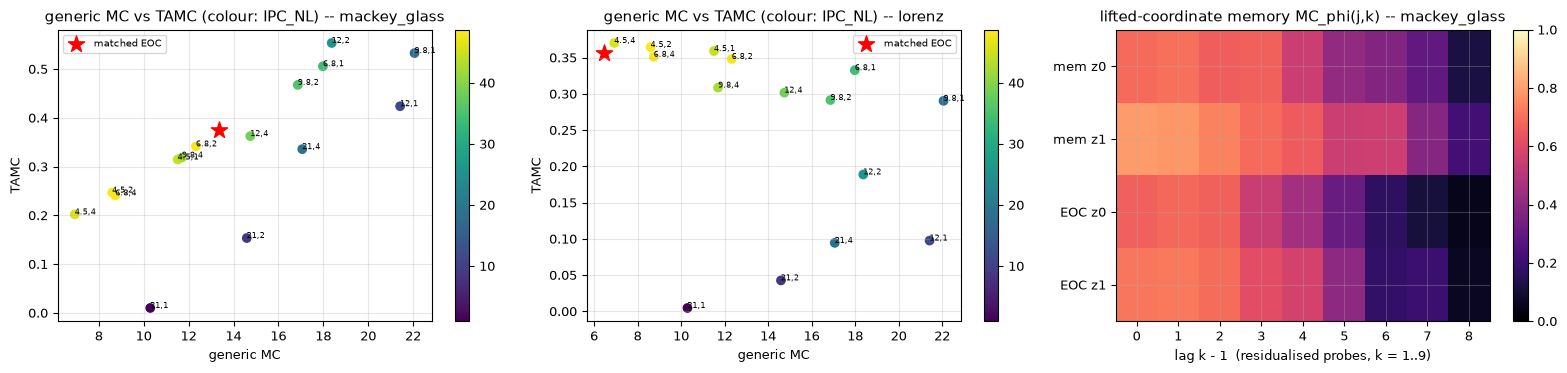

In [18]:
MEMSEL = {}
for ds in DATASETS:
    cands = [k for k in MEM_CANDS if k != EOC_KEYS[ds]]
    mm = lambda v: (np.asarray(v) - np.min(v)) / (np.ptp(v) + 1e-12)
    t_ = mm([TAMC[(ds, k)]['tamc'] for k in cands]); m_ = mm([CAP[k]['mc'] for k in cands]); n_ = mm([CAP[k]['ipc_nl'] for k in cands])
    score = {k: float(a + 0.25 * b - 0.25 * c) for k, a, b, c in zip(cands, t_, m_, n_)}
    ok = [k for k in cands if CAP[k]['esp_ok'] and CAP[k]['ipc_nl'] < CAP[EOC_KEYS[ds]]['ipc_nl']]
    if not ok:
        print(f'{ds}: ** no candidate passes the filters; the best-scoring candidate is used and flagged **')
        ok = cands
    sel = max(ok, key=score.get); gen = max(ok, key=lambda k: CAP[k]['mc'])
    tam_vals = np.array([TAMC[(ds, k)]['tamc'] for k in cands])
    MEMSEL[ds] = {'taskmem': sel, 'generic': gen, 'score': score, 'filters_ok': ok,
                  'tamc_percentile': float(np.mean(tam_vals <= TAMC[(ds, sel)]['tamc'])),
                  'rank_corr_mc_vs_tamc': float(spearmanr([CAP[k]['mc'] for k in cands], [TAMC[(ds, k)]['tamc'] for k in cands])[0]),
                  'generic_mc_ranking': sorted(cands, key=lambda k: -CAP[k]['mc']), 'tamc_ranking': sorted(cands, key=lambda k: -TAMC[(ds, k)]['tamc'])}
    print(f"\n=== {ds}: memory candidates at N={N_P} (lifted input {TOP1[ds].name}) ===")
    print(f"{'(kappa,reps)':16s} {'TAMC':>6s} {'null':>6s} {'lifted MC':>9s} {'raw probes':>10s} {'generic MC':>10s} {'IPC_NL':>7s} {'ESP':>4s} {'score':>6s} {'val J*':>7s}")
    for k in sorted(cands, key=lambda k: -score[k]):
        T_ = TAMC[(ds, k)]
        flag = ' <- TASK_ALIGNED' if k == sel else (' <- generic-MC' if k == gen else '')
        print(f"{str(k):16s} {T_['tamc']:6.3f} {T_['null_max']:6.3f} {T_['mc_lifted']:9.2f} {T_['mc_lifted_raw']:10.2f} {CAP[k]['mc']:10.2f} {CAP[k]['ipc_nl']:7.2f} "
              f"{'ok' if CAP[k]['esp_ok'] else 'NO':>4s} {score[k]:6.3f} {T_['J_val_screen']:7.4f}{flag}")
    E_ = TAMC[(ds, EOC_KEYS[ds])]
    print(f"EOC {EOC_KEYS[ds]}: TAMC {E_['tamc']:.3f}, generic MC {CAP[EOC_KEYS[ds]]['mc']:.2f}, IPC_NL {CAP[EOC_KEYS[ds]]['ipc_nl']:.2f}")
    print('   (*val J: forecasting with the perturbed lifted input, screening lengths; informational only)')
    print(f"Spearman(generic MC, TAMC) over candidates = {MEMSEL[ds]['rank_corr_mc_vs_tamc']:+.2f}; selected TAMC percentile {MEMSEL[ds]['tamc_percentile']:.2f}")
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for a, ds in zip(ax[:2], DATASETS):
    cands = [k for k in MEM_CANDS if k != EOC_KEYS[ds]]
    sc = a.scatter([CAP[k]['mc'] for k in cands], [TAMC[(ds, k)]['tamc'] for k in cands], c=[CAP[k]['ipc_nl'] for k in cands], cmap='viridis')
    for k in cands:
        a.annotate(f'{k[0]:g},{k[1]}', (CAP[k]['mc'], TAMC[(ds, k)]['tamc']), fontsize=6)
    a.scatter([CAP[EOC_KEYS[ds]]['mc']], [TAMC[(ds, EOC_KEYS[ds])]['tamc']], marker='*', s=150, c='r', label='matched EOC')
    a.set_xlabel('generic MC'); a.set_ylabel('TAMC'); a.set_title(f'generic MC vs TAMC (colour: IPC_NL) -- {ds}'); a.legend(fontsize=7)
    plt.colorbar(sc, ax=a)
ds0 = DATASETS[0]
im = ax[2].imshow(np.vstack([TAMC[(ds0, MEMSEL[ds0]['taskmem'])]['mc_jk'].reshape(-1, P).T, TAMC[(ds0, EOC_KEYS[ds0])]['mc_jk'].reshape(-1, P).T]),
                  aspect='auto', cmap='magma', vmin=0, vmax=1)
ax[2].set_yticks(range(2 * P), [f'mem z{j}' for j in range(P)] + [f'EOC z{j}' for j in range(P)]); ax[2].set_xlabel('lag k - 1  (residualised probes, k = 1..9)')
ax[2].set_title(f'lifted-coordinate memory MC_phi(j,k) -- {ds0}'); plt.colorbar(im, ax=ax[2])
plt.tight_layout(); plt.show()

## 13. QRC compatibility screening (Stage 2) and validation of the locked factorial

**Stage 2.** The three shortlisted representations are run through the matched EOC QRC and the task-aligned memory
QRC (screening lengths, paired units). For each:
- $C_{\rm QRC}=E_{\rm linear\ proxy}/E_{\rm QRC}$ is computed;
- *neighbourhood preservation* is measured as the overlap of 10-nearest-neighbour sets of $z_t$ and of the QRC
  features;
- the rank correlation of pairwise distances before and after encoding is measured.

Representations with $C_{\rm QRC}<0.5$ are rejected (destroyed by the encoding). Among the rest, the one with the
lowest validation error through the memory QRC is locked.

**Full-length validation** of every factorial cell then fixes `BEST_MATCHED_EOC`. This uses the full train/val
lengths and the paired units, and the test data still do not exist.

In [19]:
def neighbourhood(zv, Fv, k=10, n=300):
    zv, Fv = zv[:n], Fv[:n]
    zs = (zv - zv.mean(0)) / (zv.std(0) + 1e-12); Fs = (Fv - Fv.mean(0)) / (Fv.std(0) + 1e-12)
    a = NearestNeighbors(n_neighbors=k + 1).fit(zs).kneighbors(zs)[1][:, 1:]
    b = NearestNeighbors(n_neighbors=k + 1).fit(Fs).kneighbors(Fs)[1][:, 1:]
    overlap = float(np.mean([len(set(x_) & set(y_)) / k for x_, y_ in zip(a, b)]))
    iu = np.triu_indices(len(zs), 1)
    dz = np.sqrt(((zs[:, None] - zs[None]) ** 2).sum(-1))[iu]; dF = np.sqrt(((Fs[:, None] - Fs[None]) ** 2).sum(-1))[iu]
    return overlap, float(spearmanr(dz, dF)[0])


t0 = time.perf_counter()
g = {}
for ds in DATASETS:
    for spec in SHORT[ds]:
        g[(ds, spec, 'eoc')] = entries(ds, spec, EOC[ds]['cfg_fn'], PAIRED, DEV, ('train', 'val'), NL_SCREEN)
        g[(ds, spec, 'mem')] = entries(ds, spec, rc_k(*MEMSEL[ds]['taskmem']), PAIRED, DEV, ('train', 'val'), NL_SCREEN)
ST2 = run_groups(g, n_lim=NL_SCREEN)
BUDGET['eoc_side'] += len([k for k in g if k[2] == 'eoc']); BUDGET['memory_side'] += len([k for k in g if k[2] == 'mem'])
STAGE2, LOCKED_REP = {ds: [] for ds in DATASETS}, {}
W = CFG['washout']
for ds in DATASETS:
    for spec in SHORT[ds]:
        prox = float(np.median([np.mean(list(proxy_val({sp: inputs_for(ds, spec, s, {q: DEV[ds][s][q] for q in ('train', 'val')})[1][sp] for sp in ('train', 'val')},
                                                        DEV[ds][s], NL_SCREEN).values())) for s, _ in PAIRED]))
        Jm, Je = J(ST2[(ds, spec, 'mem')]), J(ST2[(ds, spec, 'eoc')])
        nb = [neighbourhood(r['z_val'][W:], r['F_val']) for r in ST2[(ds, spec, 'mem')]]
        STAGE2[ds].append({'spec': spec, 'proxy': prox, 'J_mem': Jm, 'J_eoc': Je, 'C_qrc_mem': prox / (Jm + 1e-12), 'C_qrc_eoc': prox / (Je + 1e-12),
                           'knn_overlap': float(np.median([a for a, _ in nb])), 'dist_spearman': float(np.median([b for _, b in nb]))})
    ok = [r for r in STAGE2[ds] if r['C_qrc_mem'] >= 0.5] or STAGE2[ds]
    LOCKED_REP[ds] = min(ok, key=lambda r: r['J_mem'])['spec']
    print(f"\n=== {ds}: Stage-2 QRC compatibility (validation, screening lengths) ===")
    print(f"{'representation':34s} {'proxy':>6s} {'J mem':>7s} {'J EOC':>7s} {'C_QRC mem':>9s} {'kNN overlap':>11s} {'dist rho':>8s}")
    for r in STAGE2[ds]:
        print(f"{r['spec'].name:34s} {r['proxy']:6.3f} {r['J_mem']:7.4f} {r['J_eoc']:7.4f} {r['C_qrc_mem']:9.2f} {r['knn_overlap']:11.3f} {r['dist_spearman']:8.3f}"
              + ('   <- LOCKED' if r['spec'] == LOCKED_REP[ds] else '') + ('   (rejected: C_QRC<0.5)' if r['C_qrc_mem'] < 0.5 else ''))
print(f'stage 2: {time.perf_counter() - t0:.0f}s')


=== mackey_glass: Stage-2 QRC compatibility (validation, screening lengths) ===
representation                      proxy   J mem   J EOC C_QRC mem kNN overlap dist rho
rbf[m=64,bw=2]|d=8|rrr|p=2          0.201  0.0052  0.0052     38.73       0.660    0.791
rbf[m=64,bw=1]|d=8|rrr|p=2          0.205  0.0048  0.0045     42.39       0.687    0.816   <- LOCKED
rbf[m=32,bw=2]|d=8|rrr|p=2          0.211  0.0055  0.0059     38.39       0.667    0.790



=== lorenz: Stage-2 QRC compatibility (validation, screening lengths) ===
representation                      proxy   J mem   J EOC C_QRC mem kNN overlap dist rho
poly3|d=8|rrr|p=2                   0.711  0.5436  0.3945      1.31       0.357    0.593
rbf[m=32,bw=2]|d=4|rrr|p=2          0.691  0.4766  0.3988      1.45       0.337    0.512
rbf[m=64,bw=2]|d=4|rrr|p=2          0.688  0.4489  0.3877      1.53       0.417    0.524   <- LOCKED
stage 2: 351s


In [20]:
def conds(ds):
    rep = LOCKED_REP[ds]
    raw = LiftSpec(DictSpec('linear', 1), 'raw', P)
    eoc, mem, gen = EOC[ds]['cfg_fn'], rc_k(*MEMSEL[ds]['taskmem']), rc_k(*MEMSEL[ds]['generic'])
    nb5 = NB5_LOCK['locked'][ds]
    c = {'RAW_TASKMEM_QRC': (raw, mem), 'RAW_EOC_QRC': (raw, eoc), 'LINEAR_TASKMEM_QRC': (rep.linear_counterpart(), mem),
         'LINEAR_EOC_QRC': (rep.linear_counterpart(), eoc), 'KERNEL_TASKMEM_QRC': (rep, mem), 'KERNEL_EOC_QRC': (rep, eoc),
         'KERNEL_TASKMEM_P1_QRC': (replace(rep, p=1), rc_k(*MEMSEL[ds]['taskmem'], p=1)),
         'NB5_SCALAR_HYBRID': (parse_nb5(nb5['kernel']), rc_k(*nb5['memory_key'], p=1)),
         'NB5_EOC_REFERENCE': (parse_nb5(nb5['best_eoc_input']), rc_k(*nb5['eoc_key'], p=1))}
    if MEMSEL[ds]['generic'] != MEMSEL[ds]['taskmem']:
        c['KERNEL_GENERICMC_QRC'] = (rep, gen)
    return c


def parse_nb5(name):
    """'rbf[m=64,bw=4]|d=8|pred|p=1' / 'poly3|d=8|pred|p=1' / 'linear|d=8|pred1|p=1' / 'raw(p=1)' -> LiftSpec."""
    if name.startswith('raw'):
        return LiftSpec(DictSpec('linear', 1), 'raw', 1)
    fam, d, proj, p = name.split('|')
    d, p = int(d[2:]), int(p[2:])
    if fam.startswith('rbf'):
        m, bw = fam[4:-1].split(',')
        return LiftSpec(DictSpec('rbf', d, int(m[2:]), float(bw[3:])), proj, p)
    return LiftSpec(DictSpec(fam, d), proj, p)


t0 = time.perf_counter()
g = {(ds, nm): entries(ds, spec, rc, PAIRED, DEV, ('train', 'val')) for ds in DATASETS for nm, (spec, rc) in conds(ds).items()}
FVAL = run_groups(g)
BUDGET['eoc_side'] += sum(1 for k in g if 'EOC' in k[1]); BUDGET['memory_side'] += sum(1 for k in g if 'TASKMEM' in k[1] or 'GENERIC' in k[1])
BEST_EOC = {}
for ds in DATASETS:
    jv = {nm: J(FVAL[(ds, nm)]) for nm in conds(ds)}
    BEST_EOC[ds] = min(('RAW_EOC_QRC', 'LINEAR_EOC_QRC', 'KERNEL_EOC_QRC'), key=jv.get)
    print(f'{ds}: full-length validation J (paired units): ' + ', '.join(f'{k}={v:.4f}' for k, v in jv.items()))
    print(f'   BEST_MATCHED_EOC = {BEST_EOC[ds]}')
print(f'factorial validation: {time.perf_counter() - t0:.0f}s')

mackey_glass: full-length validation J (paired units): RAW_TASKMEM_QRC=0.0074, RAW_EOC_QRC=0.0057, LINEAR_TASKMEM_QRC=0.0069, LINEAR_EOC_QRC=0.0065, KERNEL_TASKMEM_QRC=0.0047, KERNEL_EOC_QRC=0.0044, KERNEL_TASKMEM_P1_QRC=0.0117, NB5_SCALAR_HYBRID=0.0318, NB5_EOC_REFERENCE=0.0060
   BEST_MATCHED_EOC = KERNEL_EOC_QRC
lorenz: full-length validation J (paired units): RAW_TASKMEM_QRC=0.5107, RAW_EOC_QRC=0.4391, LINEAR_TASKMEM_QRC=0.5162, LINEAR_EOC_QRC=0.4360, KERNEL_TASKMEM_QRC=0.4459, KERNEL_EOC_QRC=0.3841, KERNEL_TASKMEM_P1_QRC=0.5055, NB5_SCALAR_HYBRID=0.6147, NB5_EOC_REFERENCE=0.4606
   BEST_MATCHED_EOC = KERNEL_EOC_QRC
factorial validation: 896s


In [21]:
# classical controls (validation selection)
def poly_ar_feats(trajs, deg, d):
    S = {sp: windows(t.x, d, t.eval_idx) for sp, t in trajs.items()}
    mu, sd = S['train'].mean(0), S['train'].std(0)
    pf = PolynomialFeatures(deg, include_bias=False).fit((S['train'] - mu) / sd)
    return {sp: pf.transform((v - mu) / sd) for sp, v in S.items()}


def esn_feats(z, n, rho, scale, seed):
    rng = np.random.default_rng(seed)
    Wr = rng.standard_normal((n, n)); Wr *= rho / np.max(np.abs(np.linalg.eigvals(Wr)))
    Win = rng.uniform(-1, 1, (n, z.shape[1])) * scale; b = rng.uniform(-0.2, 0.2, n)
    s, out = np.zeros(n), np.empty((len(z), n))
    for t in range(len(z)):
        s = np.tanh(Wr @ s + Win @ (2 * z[t] - 1) + b); out[t] = s
    return out


def classical_feats(kind, ds, s, trajs, param=None):
    W = CFG['washout']
    if kind == 'ar':
        return {sp: windows(t.x, param, t.eval_idx) for sp, t in trajs.items()}
    if kind == 'polyar':
        return poly_ar_feats(trajs, *param)
    lf, z, _ = inputs_for(ds, LOCKED_REP[ds], s, trajs)
    if kind == 'kernel_only':
        return {sp: lf.dic.psi(t.x, t.eval_idx) for sp, t in trajs.items()}
    if kind == 'z_ridge':
        return {sp: lag_stack(z[sp], param)[W:] for sp in trajs}
    if kind == 'esn':
        return {sp: esn_feats(z[sp], N_FEATURES, *param)[W:] for sp in trajs}


ESN_GRID = [(r_, s_) for r_ in (0.5, 0.8, 0.95, 1.2) for s_ in (0.3, 1.0)]
POLY_GRID = [(deg, d) for deg in (2, 3) for d in CFG['d_grid'] if poly_count(d, deg) <= CFG['max_poly']]
CTRL_SEL, CTRL_VAL = {}, {}
for ds in DATASETS:
    def Jc(kind, param, rs=None):
        return float(np.median([np.mean(list(unit_nrmse(readout(classical_feats(kind, ds, s, DEV[ds][s], param if rs is None else (*param, s)), DEV[ds][s])[0], DEV[ds][s], 'val').values())) for s in SEEDS]))
    sel = {'ar': min(CFG['d_grid'], key=lambda d: Jc('ar', d)), 'polyar': min(POLY_GRID, key=lambda q: Jc('polyar', q)),
           'esn': min(ESN_GRID, key=lambda q: Jc('esn', q, 0))}
    CTRL_SEL[ds] = sel
    CTRL_VAL[ds] = {'linear_AR': Jc('ar', sel['ar']), 'poly_AR': Jc('polyar', sel['polyar']), 'kernel_only_ridge': Jc('kernel_only', None),
                    'z_ridge(z_t)': Jc('z_ridge', 1), 'z_ridge(8 lags)': Jc('z_ridge', 8), 'ESN_kernel': Jc('esn', sel['esn'], 0)}
    print(ds, 'controls selected on validation:', sel, '\n   validation J:', {k: round(v, 4) for k, v in CTRL_VAL[ds].items()})

mackey_glass controls selected on validation: {'ar': 32, 'polyar': (2, 32), 'esn': (0.5, 1.0)} 
   validation J: {'linear_AR': 0.2997, 'poly_AR': 0.004, 'kernel_only_ridge': 0.0417, 'z_ridge(z_t)': 0.3862, 'z_ridge(8 lags)': 0.2031, 'ESN_kernel': 0.0043}


lorenz controls selected on validation: {'ar': 8, 'polyar': (3, 8), 'esn': (0.5, 1.0)} 
   validation J: {'linear_AR': 0.7729, 'poly_AR': 0.4035, 'kernel_only_ridge': 0.4555, 'z_ridge(z_t)': 0.7725, 'z_ridge(8 lags)': 0.6843, 'ESN_kernel': 0.3727}


## 14. Method lock

Everything that touches the test data is now frozen into a hashed lock record:
- representations and reservoirs;
- `BEST_MATCHED_EOC`;
- control hyperparameters;
- the evaluation-unit design.

The test trajectories are generated only by `release()`, which requires this lock and an unchanged criteria hash, and
which may run only once per dataset.

In [22]:
class TestVault:
    def __init__(self, builder):
        self.builder, self.lock_record, self.lock_hash, self.lock_time, self.releases = builder, None, None, None, {}

    def lock(self, record):
        assert self.lock_record is None, 'already locked'
        self.lock_record = json.loads(json.dumps(record, default=str))
        self.lock_hash = hashlib.sha256(json.dumps(self.lock_record, sort_keys=True).encode()).hexdigest()
        self.lock_time = time.time()
        return self.lock_hash

    def release(self, ds):
        assert self.lock_record is not None, 'test requested before lock'
        assert hashlib.sha256(json.dumps(PREREG, sort_keys=True).encode()).hexdigest() == CRITERIA_HASH, 'criteria changed'
        assert ds not in self.releases, f'test set for {ds} already released'
        self.releases[ds] = time.time()
        return self.builder(ds)


UNITS_FULL = [(s, rs) for s in SEEDS for rs in RSEEDS]
LOCK = {'criteria_hash': CRITERIA_HASH, 'smoke': SMOKE, 'primary_p': P, 'N_primary': N_P, 'edge_band_N7': [K_LO, K_HI],
        'units_full': UNITS_FULL, 'units_reduced': PAIRED, 'budget': BUDGET,
        'locked': {ds: {'representation': LOCKED_REP[ds].name, 'eoc': [round(EOC[ds]['kappa'], 6), EOC[ds]['reps']],
                        'task_memory': list(MEMSEL[ds]['taskmem']), 'generic_mc': list(MEMSEL[ds]['generic']),
                        'best_matched_eoc': BEST_EOC[ds], 'controls': CTRL_SEL[ds]} for ds in DATASETS}}
VAULT = TestVault(lambda ds: {s: make_traj(ds, s, 'test', seed_offset=1000 if SMOKE else 0) for s in SEEDS})
LOCK_HASH = VAULT.lock(LOCK)
print(json.dumps(VAULT.lock_record, indent=1))
print('\nMETHOD LOCKED -- lock hash', LOCK_HASH)

{
 "criteria_hash": "f328cb1ecf68ea98e5f766e229db985538883d3abe8b3846b8961004083f29e3",
 "smoke": false,
 "primary_p": 2,
 "N_primary": 7,
 "edge_band_N7": [
  3.56925,
  32.92499
 ],
 "units_full": [
  [
   0,
   0
  ],
  [
   0,
   1
  ],
  [
   0,
   2
  ],
  [
   1,
   0
  ],
  [
   1,
   1
  ],
  [
   1,
   2
  ],
  [
   2,
   0
  ],
  [
   2,
   1
  ],
  [
   2,
   2
  ]
 ],
 "units_reduced": [
  [
   0,
   0
  ],
  [
   1,
   1
  ],
  [
   2,
   2
  ]
 ],
 "budget": {
  "eoc_side": 42,
  "memory_side": 44
 },
 "locked": {
  "mackey_glass": {
   "representation": "rbf[m=64,bw=1]|d=8|rrr|p=2",
   "eoc": [
    10.84055,
    4
   ],
   "task_memory": [
    6.8,
    1
   ],
   "generic_mc": [
    6.8,
    1
   ],
   "best_matched_eoc": "KERNEL_EOC_QRC",
   "controls": {
    "ar": 32,
    "polyar": [
     2,
     32
    ],
    "esn": [
     0.5,
     1.0
    ]
   }
  },
  "lorenz": {
   "representation": "rbf[m=64,bw=2]|d=4|rrr|p=2",
   "eoc": [
    3.56925,
    16
   ],
   "task_memo

## 15. Single test release

The test trajectories are generated now, once per dataset. Units are assigned as follows:
- every locked factorial cell runs on **3 data seeds × 3 reservoir seeds**;
- p = 3 (N = 8) and the ablations run on the 3 paired units, per the preregistered compute rule.

Readout α is still chosen on validation, and the test split is only scored.

In [23]:
TEST = {ds: VAULT.release(ds) for ds in DATASETS}
FULL = {ds: {s: {'train': DEV[ds][s]['train'], 'val': DEV[ds][s]['val'], 'test': TEST[ds][s]} for s in SEEDS} for ds in DATASETS}
SPL = ('train', 'val', 'test')
for ds in DATASETS:
    for s in SEEDS:
        dmin = min(min_segment_distance(FULL[ds][s]['test'].x, FULL[ds][s][q].x) for q in ('train', 'val'))
        check(f'{ds} seed {s}: test trajectory shares no 32-sample segment with train/val ({dmin:.3g})', dmin > 1e-6)
t0 = time.perf_counter()
g = {(ds, nm): entries(ds, spec, rc, UNITS_FULL, FULL, SPL) for ds in DATASETS for nm, (spec, rc) in conds(ds).items()}
rep_ = {ds: LOCKED_REP[ds] for ds in DATASETS}
for ds in DATASETS:
    mem = rc_k(*MEMSEL[ds]['taskmem'])
    g[(ds, 'KERNEL_TASKMEM_P3_QRC')] = entries(ds, replace(rep_[ds], p=3), rc_k(*MEMSEL[ds]['taskmem'], p=3), PAIRED, FULL, SPL)
    g[(ds, 'ABL_QUARTER_DELAY')] = entries(ds, replace(rep_[ds], dict_spec=replace(rep_[ds].dict_spec, d=max(1, rep_[ds].dict_spec.d // 4))), mem, PAIRED, FULL, SPL)
    g[(ds, 'ABL_SHUFFLED_HISTORY')] = entries(ds, rep_[ds], mem, PAIRED, FULL, SPL, S_mode='shuffle')
    for j in range(P):
        g[(ds, f'ABL_LEAVE_OUT_z{j}')] = entries(ds, rep_[ds], mem, PAIRED, FULL, SPL, drop=j)
    g[(ds, 'ABL_PCA_PROJECTION')] = entries(ds, replace(rep_[ds], proj='pca'), mem, PAIRED, FULL, SPL)
    g[(ds, 'ABL_DUPLICATED_RAW')] = entries(ds, LiftSpec(DictSpec('linear', 1), 'dupraw', P), mem, PAIRED, FULL, SPL)
TR = run_groups(g, splits=SPL)
for ds in DATASETS:
    TR[(ds, 'BEST_MATCHED_EOC')] = TR[(ds, BEST_EOC[ds])]
    if (ds, 'KERNEL_GENERICMC_QRC') not in TR:
        TR[(ds, 'KERNEL_GENERICMC_QRC')] = TR[(ds, 'KERNEL_TASKMEM_QRC')]
print(f'test-phase QRC runs: {time.perf_counter() - t0:.0f}s')

  [PASS] mackey_glass seed 0: test trajectory shares no 32-sample segment with train/val (0.00191)


  [PASS] mackey_glass seed 1: test trajectory shares no 32-sample segment with train/val (0.00622)
  [PASS] mackey_glass seed 2: test trajectory shares no 32-sample segment with train/val (0.00334)


  [PASS] lorenz seed 0: test trajectory shares no 32-sample segment with train/val (0.644)
  [PASS] lorenz seed 1: test trajectory shares no 32-sample segment with train/val (0.271)


  [PASS] lorenz seed 2: test trajectory shares no 32-sample segment with train/val (0.274)


test-phase QRC runs: 4982s


In [24]:
CT = {ds: {} for ds in DATASETS}
for ds in DATASETS:
    for s in SEEDS:
        tr = FULL[ds][s]; te = tr['test']
        def add(name, pr, rs=None):
            CT[ds].setdefault(name, []).append({'unit': (s, rs), 'preds': pr, 'nrmse': {'test': unit_nrmse(pr, tr, 'test'), 'val': unit_nrmse(pr, tr, 'val')}})
        add('persistence', {'test': np.stack([te.x[te.eval_idx]] * len(HZ), 1), 'val': np.stack([tr['val'].x[tr['val'].eval_idx]] * len(HZ), 1)})
        for name, kind, prm in (('linear_AR', 'ar', CTRL_SEL[ds]['ar']), ('poly_AR', 'polyar', CTRL_SEL[ds]['polyar']),
                                ('kernel_only_ridge', 'kernel_only', None), ('z_ridge(z_t)', 'z_ridge', 1), ('z_ridge(8 lags)', 'z_ridge', 8)):
            add(name, readout(classical_feats(kind, ds, s, tr, prm), tr, out=('val', 'test'))[0])
        for rs in RSEEDS:
            add('ESN_kernel', readout(classical_feats('esn', ds, s, tr, (*CTRL_SEL[ds]['esn'], rs)), tr, out=('val', 'test'))[0], rs)
ALL = {}
for ds in DATASETS:
    ALL[ds] = {k[1]: v for k, v in TR.items() if k[0] == ds}
    for nm, v in CT[ds].items():
        ALL[ds][nm] = v if v[0]['unit'][1] is not None else [dict(r, unit=(r['unit'][0], rs)) for r in v for rs in RSEEDS]


def med_test(ds, m, h, units=None):
    return float(np.median([r['nrmse']['test'][h] for r in ALL[ds][m] if units is None or r['unit'] in units]))


MAIN = ['KERNEL_TASKMEM_QRC', 'KERNEL_EOC_QRC', 'LINEAR_TASKMEM_QRC', 'LINEAR_EOC_QRC', 'RAW_TASKMEM_QRC', 'RAW_EOC_QRC',
        'BEST_MATCHED_EOC', 'KERNEL_GENERICMC_QRC', 'KERNEL_TASKMEM_P1_QRC', 'NB5_SCALAR_HYBRID', 'NB5_EOC_REFERENCE',
        'kernel_only_ridge', 'z_ridge(z_t)', 'z_ridge(8 lags)', 'ESN_kernel', 'linear_AR', 'poly_AR', 'persistence']
ABLS = ['KERNEL_TASKMEM_P3_QRC', 'ABL_QUARTER_DELAY', 'ABL_SHUFFLED_HISTORY'] + [f'ABL_LEAVE_OUT_z{j}' for j in range(P)] + ['ABL_PCA_PROJECTION', 'ABL_DUPLICATED_RAW']

## 16. Factorial forecasting results (test)


=== mackey_glass: TEST NRMSE, median [IQR] over 9 units  (BEST_MATCHED_EOC = KERNEL_EOC_QRC) ===
model                                        h=1                   h=5                  h=10   R2(h=5)  pearson(h=5)
KERNEL_TASKMEM_QRC           0.0027 [0.003,0.004]   0.0032 [0.003,0.004]   0.0097 [0.009,0.010]    1.0000   1.0000
KERNEL_EOC_QRC               0.0028 [0.003,0.012]   0.0028 [0.002,0.013]   0.0064 [0.006,0.031]    1.0000   1.0000
LINEAR_TASKMEM_QRC           0.0026 [0.002,0.004]   0.0035 [0.003,0.005]   0.0156 [0.014,0.022]    1.0000   1.0000
LINEAR_EOC_QRC               0.0036 [0.003,0.011]   0.0030 [0.003,0.012]   0.0142 [0.013,0.040]    1.0000   1.0000
RAW_TASKMEM_QRC              0.0022 [0.001,0.003]   0.0020 [0.002,0.004]   0.0185 [0.016,0.021]    1.0000   1.0000
RAW_EOC_QRC                  0.0024 [0.002,0.014]   0.0015 [0.001,0.011]   0.0137 [0.013,0.069]    1.0000   1.0000
BEST_MATCHED_EOC             0.0028 [0.003,0.012]   0.0028 [0.002,0.013]   0.0064 [0.006,0.031]

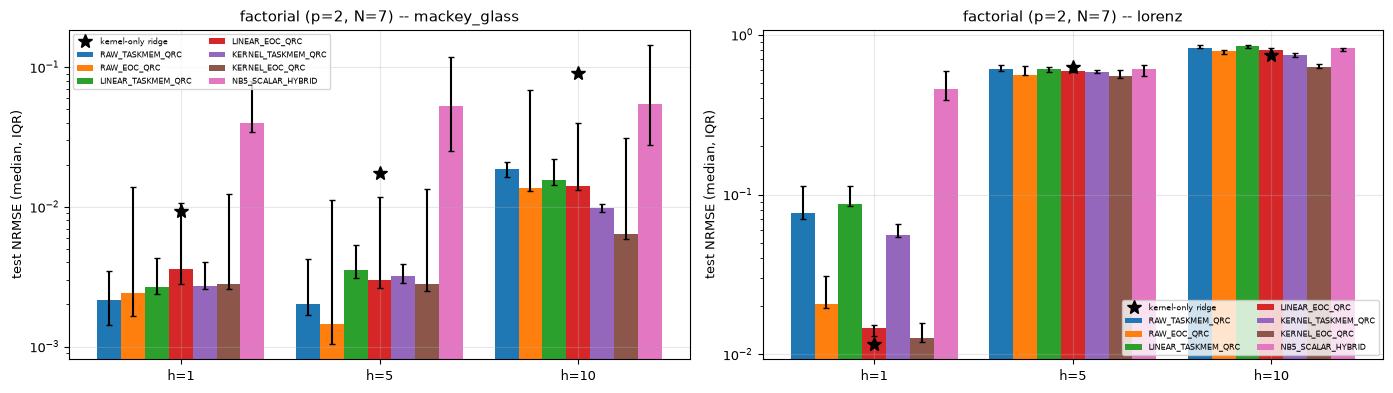

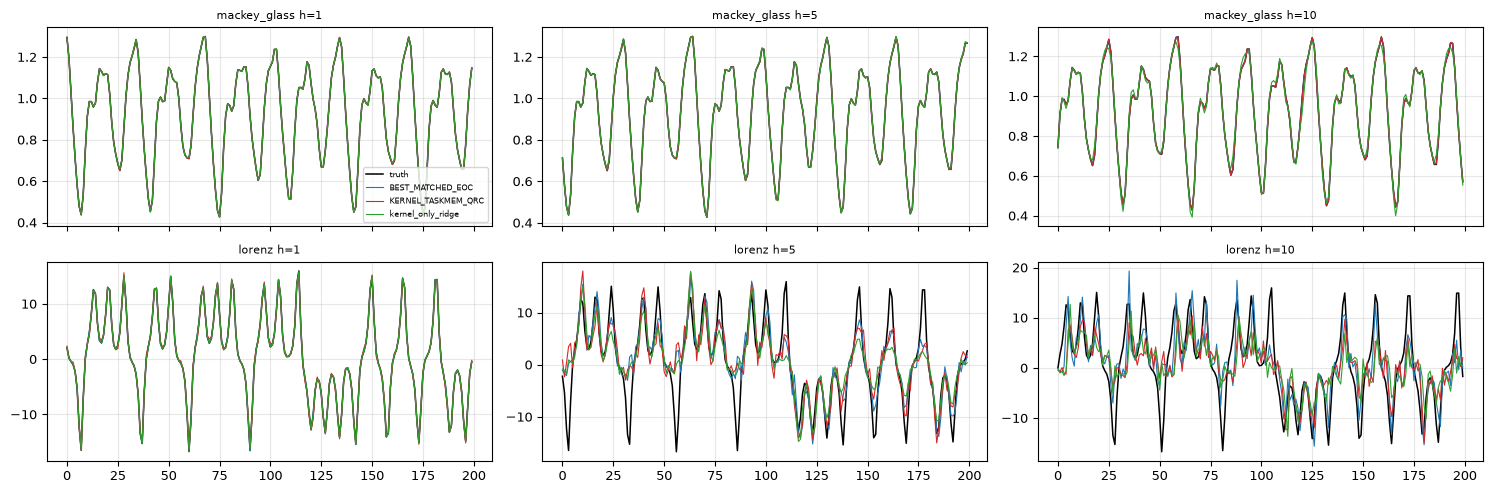

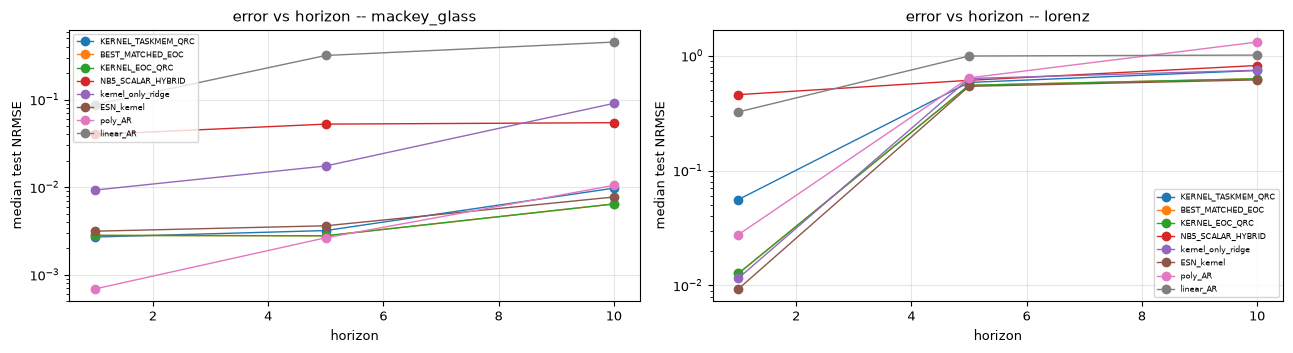

In [25]:
for ds in DATASETS:
    print(f'\n=== {ds}: TEST NRMSE, median [IQR] over {len(UNITS_FULL)} units  (BEST_MATCHED_EOC = {BEST_EOC[ds]}) ===')
    print(f"{'model':26s}" + ''.join(f'{"h=" + str(h):>22s}' for h in HZ) + '   R2(h=5)  pearson(h=5)')
    for m in MAIN:
        line = f'{m:26s}'
        for h in HZ:
            v = [r['nrmse']['test'][h] for r in ALL[ds][m]]
            q1, q2, q3 = np.percentile(v, [25, 50, 75]); line += f'   {q2:.4f} [{q1:.3f},{q3:.3f}]'
        k5 = HZ.index(5)
        mets = [all_metrics(r['preds']['test'][:, k5], FULL[ds][r['unit'][0]]['test'].target(5)) for r in ALL[ds][m]]
        print(line + f"   {np.median([q['r2'] for q in mets]):7.4f}  {np.median([q['pearson'] for q in mets]):7.4f}")
    print('   per-unit KERNEL_TASKMEM vs BEST_MATCHED_EOC at h=5:',
          ', '.join(f"{a['unit']}: {a['nrmse']['test'][5]:.4f}/{b['nrmse']['test'][5]:.4f}" for a, b in zip(ALL[ds]['KERNEL_TASKMEM_QRC'], ALL[ds]['BEST_MATCHED_EOC'])))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, ds in zip(ax, DATASETS):
    cells = ['RAW_TASKMEM_QRC', 'RAW_EOC_QRC', 'LINEAR_TASKMEM_QRC', 'LINEAR_EOC_QRC', 'KERNEL_TASKMEM_QRC', 'KERNEL_EOC_QRC', 'NB5_SCALAR_HYBRID']
    w = 0.12
    for k, m in enumerate(cells):
        v = [[r['nrmse']['test'][h] for r in ALL[ds][m]] for h in HZ]
        a.bar(np.arange(len(HZ)) + (k - 3) * w, [np.median(x) for x in v], w, label=m,
              yerr=[[max(0, np.median(x) - np.percentile(x, 25)) for x in v], [max(0, np.percentile(x, 75) - np.median(x)) for x in v]], capsize=2)
    a.plot(np.arange(len(HZ)), [med_test(ds, 'kernel_only_ridge', h) for h in HZ], 'k*', ms=10, label='kernel-only ridge')
    a.set_xticks(range(len(HZ)), [f'h={h}' for h in HZ]); a.set_yscale('log'); a.set_ylabel('test NRMSE (median, IQR)')
    a.set_title(f'factorial (p={P}, N={N_P}) -- {ds}'); a.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, len(HZ), figsize=(15, 5), sharex=True)
for i, ds in enumerate(DATASETS):
    te = FULL[ds][SEEDS[0]]['test']
    for j, h in enumerate(HZ):
        a = ax[i, j]; k = HZ.index(h)
        a.plot(te.target(h)[:200], 'k', lw=1.1, label='truth')
        for m, c in (('BEST_MATCHED_EOC', 'C0'), ('KERNEL_TASKMEM_QRC', 'C3'), ('kernel_only_ridge', 'C2')):
            r = [r for r in ALL[ds][m] if r['unit'] == (SEEDS[0], RSEEDS[0])][0]
            a.plot(r['preds']['test'][:200, k], c, lw=0.8, label=m)
        a.set_title(f'{ds} h={h}', fontsize=8)
ax[0, 0].legend(fontsize=6)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, ds in zip(ax, DATASETS):
    for m in ('KERNEL_TASKMEM_QRC', 'BEST_MATCHED_EOC', 'KERNEL_EOC_QRC', 'NB5_SCALAR_HYBRID', 'kernel_only_ridge', 'ESN_kernel', 'poly_AR', 'linear_AR'):
        a.plot(HZ, [med_test(ds, m, h) for h in HZ], 'o-', lw=1, label=m)
    a.set_yscale('log'); a.set_xlabel('horizon'); a.set_ylabel('median test NRMSE'); a.set_title(f'error vs horizon -- {ds}'); a.legend(fontsize=6)
plt.tight_layout(); plt.show()

## 17. Statistical uncertainty

**Method.** A paired moving-block bootstrap over test indices, with 2000 draws. Within a data seed, every unit and
both models share the same resampled indices.

**Block length.** It is computed *before* any interval: max(40, the largest |test error| autocorrelation length over
every compared model), rounded up to 10.

**Statistic.** $\Delta=(E_A-E_B)/E_A$, where $E$ is the median NRMSE over units, so $\Delta>0$ means B is better.

largest |test error| autocorrelation length: 62 -> bootstrap block 70


bootstrap: 46s
dataset         h comparison (A -> KERNEL_TASKMEM)        E_A    E_KTM    Delta  95% CI
mackey_glass    1 vs_best_eoc (BEST_MATCHED_EOC)       0.0028   0.0027   +0.042  [-0.018, +0.088]
mackey_glass    1 vs_scalar_hybrid (NB5_SCALAR_HYBRID)   0.0400   0.0027   +0.933  [+0.824, +0.929]
mackey_glass    1 vs_generic_mc (KERNEL_GENERICMC_QRC)   0.0027   0.0027   +0.000  [+0.000, +0.000]
mackey_glass    1 vs_kernel_only (kernel_only_ridge)   0.0093   0.0027   +0.709  [+0.691, +0.726]
mackey_glass    1 vs_kernel_eoc (KERNEL_EOC_QRC)       0.0028   0.0027   +0.042  [-0.018, +0.091]
mackey_glass    1 vs_linear_taskmem (LINEAR_TASKMEM_QRC)   0.0026   0.0027   -0.018  [-0.138, +0.081]
mackey_glass    1 vs_p1 (KERNEL_TASKMEM_P1_QRC)        0.0051   0.0027   +0.474  [+0.308, +0.432]
mackey_glass    1 vs_nb5_eoc (NB5_EOC_REFERENCE)       0.0021   0.0027   -0.313  [-0.403, -0.261]
mackey_glass    5 vs_best_eoc (BEST_MATCHED_EOC)       0.0028   0.0032   -0.147  [-0.332, -0.093]
mackey_

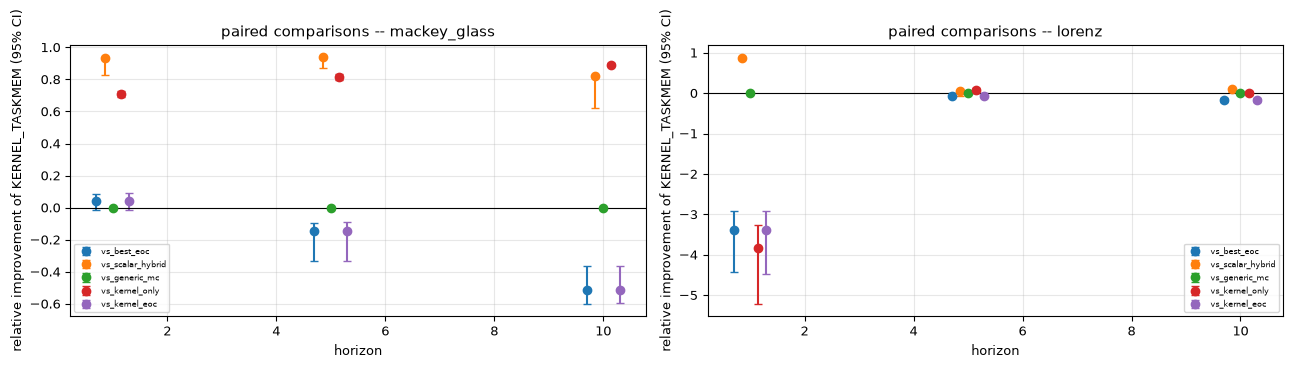

In [26]:
def acl(err, thr=0.1):
    e = np.abs(err) - np.mean(np.abs(err)); ac = np.correlate(e, e, 'full')[len(e) - 1:]; ac = ac / (ac[0] + 1e-300)
    b = np.where(ac < thr)[0]
    return int(b[0]) if len(b) else len(e)


ACL = max(acl(r['preds']['test'][:, HZ.index(h)] - FULL[ds][r['unit'][0]]['test'].target(h))
          for ds in DATASETS for m in MAIN + ABLS for r in ALL[ds][m] for h in HZ)
BLOCK = int(10 * np.ceil(max(CFG['block_min'], ACL) / 10))
print(f'largest |test error| autocorrelation length: {ACL} -> bootstrap block {BLOCK}')


def bootstrap(ds, A, B, h, units=None, seed=0):
    ua = {r['unit']: r for r in ALL[ds][A]}; ub = {r['unit']: r for r in ALL[ds][B]}
    us = sorted((set(ua) & set(ub)) if units is None else set(units))
    k = HZ.index(h); y = {s: FULL[ds][s]['test'].target(h) for s in SEEDS}
    def stat(ix):
        ea = [nrmse_(ua[u]['preds']['test'][ix[u[0]], k], y[u[0]][ix[u[0]]]) for u in us]
        eb = [nrmse_(ub[u]['preds']['test'][ix[u[0]], k], y[u[0]][ix[u[0]]]) for u in us]
        return (np.median(ea) - np.median(eb)) / np.median(ea)
    n = len(y[SEEDS[0]]); rng = np.random.default_rng(seed)
    def blocks():
        st = rng.integers(0, n - BLOCK + 1, int(np.ceil(n / BLOCK)))
        return np.concatenate([np.arange(a, a + BLOCK) for a in st])[:n]
    point = stat({s: np.arange(n) for s in SEEDS})
    draws = np.array([stat({s: blocks() for s in SEEDS}) for _ in range(CFG['n_boot'])])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return {'delta': float(point), 'ci95': [float(lo), float(hi)], 'units': len(us)}


COMP = {'vs_best_eoc': ('BEST_MATCHED_EOC', 'KERNEL_TASKMEM_QRC'), 'vs_scalar_hybrid': ('NB5_SCALAR_HYBRID', 'KERNEL_TASKMEM_QRC'),
        'vs_generic_mc': ('KERNEL_GENERICMC_QRC', 'KERNEL_TASKMEM_QRC'), 'vs_kernel_only': ('kernel_only_ridge', 'KERNEL_TASKMEM_QRC'),
        'vs_kernel_eoc': ('KERNEL_EOC_QRC', 'KERNEL_TASKMEM_QRC'), 'vs_linear_taskmem': ('LINEAR_TASKMEM_QRC', 'KERNEL_TASKMEM_QRC'),
        'vs_p1': ('KERNEL_TASKMEM_P1_QRC', 'KERNEL_TASKMEM_QRC'), 'vs_nb5_eoc': ('NB5_EOC_REFERENCE', 'KERNEL_TASKMEM_QRC')}
BOOT = {}
t0 = time.perf_counter()
for ds in DATASETS:
    for h in HZ:
        for nm, (A, B) in COMP.items():
            BOOT[(ds, h, nm)] = bootstrap(ds, A, B, h, seed=zlib.crc32(f'{ds}{h}{nm}'.encode()))
        for ab in ABLS:
            BOOT[(ds, h, 'abl:' + ab)] = bootstrap(ds, ab, 'KERNEL_TASKMEM_QRC', h, units=PAIRED, seed=zlib.crc32(f'{ds}{h}{ab}'.encode()))
print(f'bootstrap: {time.perf_counter() - t0:.0f}s')
print(f"{'dataset':13s} {'h':>3s} {'comparison (A -> KERNEL_TASKMEM)':34s} {'E_A':>8s} {'E_KTM':>8s} {'Delta':>8s}  95% CI")
for (ds, h, nm), b in BOOT.items():
    if nm.startswith('abl:'):
        continue
    A = COMP[nm][0]
    print(f"{ds:13s} {h:3d} {nm + ' (' + A + ')':34s} {med_test(ds, A, h):8.4f} {med_test(ds, 'KERNEL_TASKMEM_QRC', h):8.4f} {b['delta']:+8.3f}  [{b['ci95'][0]:+.3f}, {b['ci95'][1]:+.3f}]")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, ds in zip(ax, DATASETS):
    for off, nm in zip(np.linspace(-0.3, 0.3, 5), ('vs_best_eoc', 'vs_scalar_hybrid', 'vs_generic_mc', 'vs_kernel_only', 'vs_kernel_eoc')):
        d_ = [BOOT[(ds, h, nm)]['delta'] for h in HZ]
        lo = [BOOT[(ds, h, nm)]['ci95'][0] for h in HZ]; hi = [BOOT[(ds, h, nm)]['ci95'][1] for h in HZ]
        a.errorbar(np.array(HZ) + off, d_, [np.clip(np.subtract(d_, lo), 0, None), np.clip(np.subtract(hi, d_), 0, None)], fmt='o', capsize=3, label=nm)
    a.axhline(0, c='k', lw=0.8); a.set_xlabel('horizon'); a.set_ylabel('relative improvement of KERNEL_TASKMEM (95% CI)')
    a.set_title(f'paired comparisons -- {ds}'); a.legend(fontsize=6)
plt.tight_layout(); plt.show()

## 18. Ablations (test, 3 paired units)

The ablations compare against `KERNEL_TASKMEM_QRC` on the *same* 3 units:
- p = 3 (N = 8);
- one-quarter delay;
- time-shuffled history (the current tap is kept and the past comes from a random time);
- leave-one-coordinate-out (the coordinate is held at its mid-scale);
- PCA in place of the task-aware projection;
- raw $x_t$ duplicated across the *p* input qubits (more input qubits, no extra information).

The interface (p = 1 vs 2) and the reservoir-selection ablations are reported in §17 on all 9 units.


=== mackey_glass: ablations (median test NRMSE over the 3 paired units; Delta = relative gain of KERNEL_TASKMEM) ===
KERNEL_TASKMEM_QRC (same units)   h=1: 0.0026           h=5: 0.0033           h=10: 0.0092         
KERNEL_TASKMEM_P3_QRC             h=1: 0.0060 (+0.56)  h=5: 0.0066 (+0.50)  h=10: 0.0140 (+0.35)
ABL_QUARTER_DELAY                 h=1: 0.0047 (+0.44)  h=5: 0.0046 (+0.28)  h=10: 0.0175 (+0.48)
ABL_SHUFFLED_HISTORY              h=1: 0.0841 (+0.97)  h=5: 0.0890 (+0.96)  h=10: 0.1649 (+0.94)
ABL_LEAVE_OUT_z0                  h=1: 0.0032 (+0.17)  h=5: 0.0044 (+0.24)  h=10: 0.0107 (+0.15)
ABL_LEAVE_OUT_z1                  h=1: 0.0032 (+0.17)  h=5: 0.0051 (+0.35)  h=10: 0.0177 (+0.48)
ABL_PCA_PROJECTION                h=1: 0.0026 (-0.01)  h=5: 0.0037 (+0.09)  h=10: 0.0151 (+0.39)
ABL_DUPLICATED_RAW                h=1: 0.0019 (-0.38)  h=5: 0.0017 (-0.92)  h=10: 0.0185 (+0.50)

=== lorenz: ablations (median test NRMSE over the 3 paired units; Delta = relative gain of KERNEL_TASK

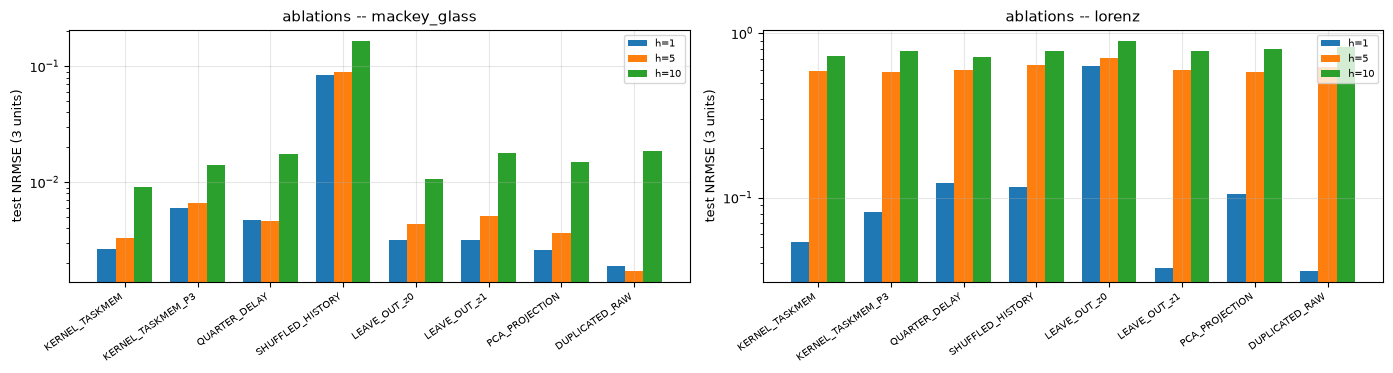

mackey_glass: nonlinear gain G_NL at L=d_sel (test) raw {1: 0.9833867781581693, 5: 0.9565691483367829, 10: 0.9163851072229381} | lifted {1: 0.7902560200036771, 5: 0.8880155682748095, 10: 0.8796611868468049}
lorenz: nonlinear gain G_NL at L=d_sel (test) raw {1: 0.8781158543443719, 5: 0.3634725177257993, 10: 0.20428360188366057} | lifted {1: -1.5118406632453236, 5: 0.10932188812429046, 10: 0.05232231786374918}


In [27]:
ABL_ROWS = []
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
for a, ds in zip(ax, DATASETS):
    print(f'\n=== {ds}: ablations (median test NRMSE over the 3 paired units; Delta = relative gain of KERNEL_TASKMEM) ===')
    base = {h: med_test(ds, 'KERNEL_TASKMEM_QRC', h, PAIRED) for h in HZ}
    print(f"{'KERNEL_TASKMEM_QRC (same units)':32s}" + ''.join(f'  h={h}: {base[h]:.4f}         ' for h in HZ))
    for ab in ABLS:
        line = f'{ab:32s}'
        for h in HZ:
            b = BOOT[(ds, h, 'abl:' + ab)]
            line += f'  h={h}: {med_test(ds, ab, h, PAIRED):.4f} ({b["delta"]:+.2f})'
            ABL_ROWS.append({'dataset': ds, 'ablation': ab, 'h': h, 'nrmse': med_test(ds, ab, h, PAIRED), 'delta': b['delta'], 'ci95': b['ci95']})
        print(line)
    names = ['KERNEL_TASKMEM_QRC'] + ABLS
    for k, h in enumerate(HZ):
        a.bar(np.arange(len(names)) + 0.25 * (k - 1), [med_test(ds, m, h, PAIRED) for m in names], 0.25, label=f'h={h}')
    a.set_xticks(range(len(names)), [n.replace('ABL_', '').replace('_QRC', '') for n in names], rotation=35, ha='right', fontsize=7)
    a.set_yscale('log'); a.set_ylabel('test NRMSE (3 units)'); a.set_title(f'ablations -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

# kernel lifting and residual nonlinear demand (classical, test): G_NL at L = d_sel
def g_nl(ds, rep_kind):
    out = {h: [] for h in HZ}
    for s in SEEDS:
        tr = FULL[ds][s]; d = LOCKED_REP[ds].dict_spec.d
        if rep_kind == 'raw':
            B = {sp: windows(t.x, d, t.eval_idx) for sp, t in tr.items()}
        else:
            dic = Dictionary(LOCKED_REP[ds].dict_spec, tr['train'].x, tr['train'].eval_idx); B = {sp: dic.psi(t.x, t.eval_idx) for sp, t in tr.items()}
        E = {}
        for q in (1, 2, 3):
            if q == 1:
                F = B
            else:
                mu, sd = B['train'].mean(0), np.where(B['train'].std(0) < 1e-12, 1, B['train'].std(0))
                pca = PCA(min(10, B['train'].shape[1])).fit((B['train'] - mu) / sd)
                pf = PolynomialFeatures(q, include_bias=False).fit(np.zeros((1, pca.n_components_))); keep = pf.powers_.sum(1) >= 2
                def ex(Bx):
                    Cx = pca.transform((Bx - mu) / sd); Cx = Cx / np.where(Cx.std(0) < 1e-12, 1, Cx.std(0))
                    return np.c_[Bx, pf.transform(Cx)[:, keep]]
                F = {sp: ex(v) for sp, v in B.items()}
            E[q] = unit_nrmse(readout(F, tr, out=('test',))[0], tr, 'test')
        for h in HZ:
            out[h].append((E[1][h] - min(E[2][h], E[3][h])) / (E[1][h] + 1e-6))
    return {h: float(np.median(v)) for h, v in out.items()}


GNL = {ds: {'raw': g_nl(ds, 'raw'), 'lift': g_nl(ds, 'lift')} for ds in DATASETS}
for ds in DATASETS:
    print(f"{ds}: nonlinear gain G_NL at L=d_sel (test) raw {GNL[ds]['raw']} | lifted {GNL[ds]['lift']}")

## 19. Runtime and resource analysis

dataset       model                     N in mem  obs    kappa reps rank      cond  depth   size    cx
mackey_glass  KERNEL_TASKMEM_QRC        7  2   5  132      6.8    1  132  7.15e+04    183    310   106
mackey_glass  BEST_MATCHED_EOC          7  2   5  132  10.8406    4  132  6.90e+04    720   1213   424
mackey_glass  KERNEL_EOC_QRC            7  2   5  132  10.8406    4  132  6.90e+04    720   1213   424
mackey_glass  RAW_TASKMEM_QRC           7  2   5  132      6.8    1  132  4.60e+04    183    310   106
mackey_glass  LINEAR_TASKMEM_QRC        7  2   5  132      6.8    1  132  4.90e+04    183    310   106
mackey_glass  KERNEL_GENERICMC_QRC      7  2   5  132      6.8    1  132  7.15e+04    183    310   106
mackey_glass  KERNEL_TASKMEM_P1_QRC     6  1   5  132      6.8    1  132  5.85e+04    150    236    82
mackey_glass  NB5_SCALAR_HYBRID         6  1   5  132   9.7992    1  132  1.19e+04    150    236    82
mackey_glass  KERNEL_TASKMEM_P3_QRC     8  3   5  132      6.8    1  132 

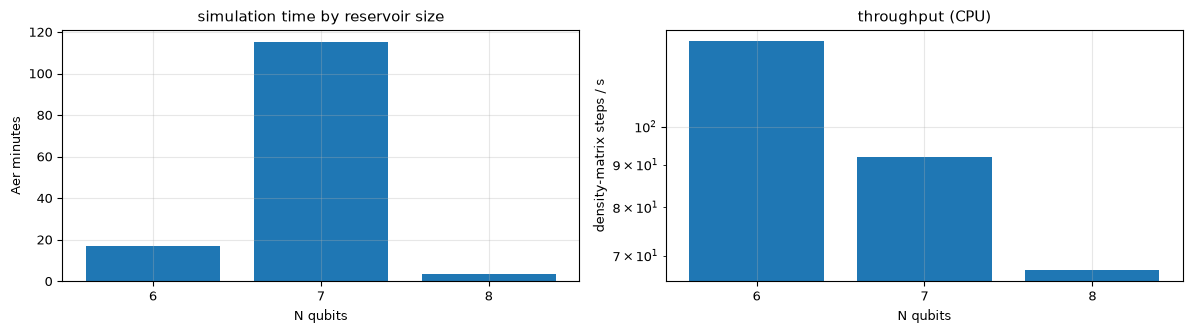

In [28]:
RES = []
for ds in DATASETS:
    for m in ('KERNEL_TASKMEM_QRC', 'BEST_MATCHED_EOC', 'KERNEL_EOC_QRC', 'RAW_TASKMEM_QRC', 'LINEAR_TASKMEM_QRC', 'KERNEL_GENERICMC_QRC',
              'KERNEL_TASKMEM_P1_QRC', 'NB5_SCALAR_HYBRID', 'KERNEL_TASKMEM_P3_QRC'):
        r0 = ALL[ds][m][0]; rc = r0['cfg']
        Ftr = None
        RES.append({'dataset': ds, 'model': m, 'N': rc.N, 'inputs': rc.n_input, 'memory': len(rc.memory_qubits), 'observables': r0['F_val'].shape[1],
                    'kappa': round(kappa_of(rc), 4) if rc.haar_seed is None else 'haar', 'reps': rc.reps,
                    'rank(val feats)': int(np.linalg.matrix_rank(r0['F_val'] - r0['F_val'].mean(0), tol=1e-8)),
                    'cond(val feats)': float(np.linalg.cond((r0['F_val'] - r0['F_val'].mean(0)) / (r0['F_val'].std(0) + 1e-12))),
                    **gate_level_resources(rc)})
print(f"{'dataset':13s} {'model':24s} {'N':>2s} {'in':>2s} {'mem':>3s} {'obs':>4s} {'kappa':>8s} {'reps':>4s} {'rank':>4s} {'cond':>9s} {'depth':>6s} {'size':>6s} {'cx':>5s}")
for r in RES:
    print(f"{r['dataset']:13s} {r['model']:24s} {r['N']:2d} {r['inputs']:2d} {r['memory']:3d} {r['observables']:4d} {str(r['kappa']):>8s} {r['reps']:4d} "
          f"{r['rank(val feats)']:4d} {r['cond(val feats)']:9.2e} {r['depth_per_step']:6d} {r['size_per_step']:6d} {r['cx_per_step']:5d}")
print('\nAer totals:', {k: (round(v, 1) if isinstance(v, float) else v) for k, v in STATS.items() if k not in ('steps_by_N', 'seconds_by_N')})
print('Aer steps by N:', STATS['steps_by_N'], '| effective steps/s by N:',
      {N: round(STATS['steps_by_N'][N] / max(STATS['seconds_by_N'][N], 1e-9)) for N in STATS['steps_by_N']})
print(f'notebook runtime so far: {(time.perf_counter() - T_START) / 60:.1f} min')
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
Ns = sorted(STATS['steps_by_N'])
ax[0].bar([str(N) for N in Ns], [STATS['seconds_by_N'][N] / 60 for N in Ns]); ax[0].set_xlabel('N qubits'); ax[0].set_ylabel('Aer minutes')
ax[0].set_title('simulation time by reservoir size')
ax[1].bar([str(N) for N in Ns], [STATS['steps_by_N'][N] / max(STATS['seconds_by_N'][N], 1e-9) for N in Ns]); ax[1].set_yscale('log')
ax[1].set_xlabel('N qubits'); ax[1].set_ylabel('density-matrix steps / s'); ax[1].set_title(f'throughput ({DEVICE})')
plt.tight_layout(); plt.show()

## 20. Audit

Every assertion must hold. A failure stops the notebook before the certificate is produced.

In [29]:
AUD = []
def aud(name, ok, detail=''):
    AUD.append((name, bool(ok))); print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f'  ({detail})' if detail else ''))

aud('development switch SMOKE is off (real test trajectories, full FAST_MODE config)', not SMOKE)
aud('all in-notebook unit tests passed (chunk equivalence, nb4 regression, causality, reset pattern, Volterra)', all(t[1] for t in TESTS), f'{len(TESTS)} tests')
aud('chunked == monolithic for p = 1, 2, 3 (< 1e-9)', all(v < 1e-9 for v in CHUNK_EQ.values()) and {p for p, _ in CHUNK_EQ} == {1, 2, 3})
aud('causal delay construction / no target leakage (targets strictly after windows)',
    all(np.all(t.eval_idx - (CFG['d_max'] - 1) >= 0) and min(HZ) >= 1 for ds in DATASETS for s in SEEDS for t in FULL[ds][s].values()))
aud('independent train/val/test trajectories (no shared 32-sample segment)',
    all(min_segment_distance(FULL[ds][s][a].x, FULL[ds][s][b].x) > 1e-6 for ds in DATASETS for s in SEEDS for a, b in (('train', 'val'), ('train', 'test'), ('val', 'test'))))
fits_ok = True
for ds in DATASETS:
    for s in SEEDS:
        lf = inputs_for(ds, LOCKED_REP[ds], s, FULL[ds][s])[0]
        fits_ok &= lf.fit_rows == CFG['n_train'] and lf.dic.fit_rows == CFG['n_train']
aud('lift, projection and scaling fitted on the training trajectory only (row counts)', fits_ok)
aud('test released exactly once per dataset, after the lock', set(VAULT.releases) == set(DATASETS) and all(t > VAULT.lock_time for t in VAULT.releases.values()))
aud('criteria hash unchanged', hashlib.sha256(json.dumps(PREREG, sort_keys=True).encode()).hexdigest() == CRITERIA_HASH)
for ds in DATASETS:
    sig = set()
    for m in ('RAW_TASKMEM_QRC', 'RAW_EOC_QRC', 'LINEAR_TASKMEM_QRC', 'LINEAR_EOC_QRC', 'KERNEL_TASKMEM_QRC', 'KERNEL_EOC_QRC', 'KERNEL_GENERICMC_QRC'):
        rs = ALL[ds][m]
        sig.add((rs[0]['cfg'].N, rs[0]['cfg'].n_input, len(rs[0]['cfg'].memory_qubits), rs[0]['F_val'].shape[1], tuple(sorted(r['unit'] for r in rs)),
                 tuple(sorted({r['cfg'].seed for r in rs})), tuple(len(r['preds']['test']) for r in rs)))
    aud(f'{ds}: matched QRC resources within p={P} (qubits, inputs, 5 memory qubits, 132 observables, units, disorder seeds, test indices)', len(sig) == 1, sig)
aud('exactly five persistent memory qubits in every QRC configuration used',
    all(len(r['cfg'].memory_qubits) == 5 for ds in DATASETS for m in MAIN + ABLS if m in ALL[ds] and 'cfg' in ALL[ds][m][0] for r in ALL[ds][m]))
aud('only input qubits reset; density-matrix simulation', all(t[1] for t in TESTS if 'reset' in t[0]) and _sim().options.method == 'density_matrix')
aud('matched EOC kappa inside the N=7 edge band', all(EOC[ds]['inside_band'] for ds in DATASETS))
z_rank = []
for ds in DATASETS:
    for s in SEEDS:
        lf = inputs_for(ds, LOCKED_REP[ds], s, FULL[ds][s])[0]
        Zs = lf.zraw(FULL[ds][s]['test'], FULL[ds][s]['test'].eval_idx)
        sv = np.linalg.svd((Zs - Zs.mean(0)) / Zs.std(0), compute_uv=False)
        z_rank.append((int(np.sum(sv > 1e-6 * sv[0])), float(Zs.std(0).min() / Zs.std(0).max())))
aud('locked interface has effective rank = p and no near-constant coordinate on test', all(r == P and sc > 1e-3 for r, sc in z_rank), z_rank)
aud('no kernel collapse (RBF Gram checks / poly feature cap)', all(inputs_for(ds, LOCKED_REP[ds], s, FULL[ds][s])[0].dic.gram_checks()['ok'] for ds in DATASETS for s in SEEDS))
aud('finite predictions everywhere', all(np.all(np.isfinite(r['preds']['test'])) for ds in DATASETS for m in MAIN + ABLS for r in ALL[ds][m]))
d1 = make_traj('lorenz', SEEDS[0], 'train').x
Xd = [run_qrc_jobs([QRCJob(mixed_config(P, 6.0, 1, 0), np.random.default_rng(3).random((40, P)))], use_memo=False)[0] for _ in range(2)]
aud('deterministic seeds (data regeneration and Aer re-runs identical)', np.array_equal(d1, DEV['lorenz'][SEEDS[0]]['train'].x) and max_dev(*Xd) == 0)
aud('no test-set hyperparameter selection (everything in the lock record was fixed before release)', VAULT.lock_time < min(VAULT.releases.values()))
aud('bootstrap block >= largest error autocorrelation length', BLOCK >= ACL, f'{BLOCK} >= {ACL}')
aud('source notebooks unchanged', all(sha256(p) == h for p, h in SOURCE_HASHES.items()))
aud('no custom helper modules imported', not any(m.startswith('klqrc') for m in sys.modules))
FS_AFTER = fs_snapshot()
new_or_changed = sorted(k for k in set(FS_AFTER) | set(FS_BEFORE) if FS_AFTER.get(k) != FS_BEFORE.get(k))
aud('no file created or modified in the repository except this notebook', not new_or_changed, new_or_changed[:5])
if SMOKE:   # development dry run: the SMOKE check is expected to fail; every other check must pass
    AUD = [a for a in AUD if not a[0].startswith('development switch')]
assert all(ok for _, ok in AUD), 'AUDIT FAILED: ' + '; '.join(n for n, ok in AUD if not ok)
print(f'\nAUDIT: all {len(AUD)} checks passed.')

  [PASS] development switch SMOKE is off (real test trajectories, full FAST_MODE config)
  [PASS] all in-notebook unit tests passed (chunk equivalence, nb4 regression, causality, reset pattern, Volterra)  (29 tests)
  [PASS] chunked == monolithic for p = 1, 2, 3 (< 1e-9)
  [PASS] causal delay construction / no target leakage (targets strictly after windows)


  [PASS] independent train/val/test trajectories (no shared 32-sample segment)
  [PASS] lift, projection and scaling fitted on the training trajectory only (row counts)
  [PASS] test released exactly once per dataset, after the lock
  [PASS] criteria hash unchanged
  [PASS] mackey_glass: matched QRC resources within p=2 (qubits, inputs, 5 memory qubits, 132 observables, units, disorder seeds, test indices)  ({(7, 2, 5, 132, ((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)), (0, 1, 2), (600, 600, 600, 600, 600, 600, 600, 600, 600))})
  [PASS] lorenz: matched QRC resources within p=2 (qubits, inputs, 5 memory qubits, 132 observables, units, disorder seeds, test indices)  ({(7, 2, 5, 132, ((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)), (0, 1, 2), (600, 600, 600, 600, 600, 600, 600, 600, 600))})
  [PASS] exactly five persistent memory qubits in every QRC configuration used
  [PASS] only input qubits reset; density-matrix simulation
  [PASS] 

  [PASS] deterministic seeds (data regeneration and Aer re-runs identical)
  [PASS] no test-set hyperparameter selection (everything in the lock record was fixed before release)
  [PASS] bootstrap block >= largest error autocorrelation length  (70 >= 62)


  [PASS] source notebooks unchanged
  [PASS] no custom helper modules imported
  [PASS] no file created or modified in the repository except this notebook

AUDIT: all 22 checks passed.


## 21. In-notebook evidence certificate

The criteria are evaluated mechanically against the frozen rules of §1. The certificate is displayed here and not
written anywhere.

In [30]:
# ---- interface ----
IFACE = {}
for ds in DATASETS:
    vals = {}
    for p in (1, P):
        fr, hr = [], []
        for s in SEEDS:
            tr, te = FULL[ds][s]['train'], FULL[ds][s]['test']
            lf = Lifter(replace(LOCKED_REP[ds], p=p), tr)
            it, ie = tr.eval_idx, te.eval_idx
            Zt, Ze = lf.zraw(tr, it), lf.zraw(te, ie)
            fr.append(float(np.mean(r2_cols(fit_ridge(Zt, np.stack([tr.x[it + h] for h in (1, 5, 10)], 1), alpha=1e-6)[0](Ze), np.stack([te.x[ie + h] for h in (1, 5, 10)], 1)))))
            hr.append(float(np.mean(r2_cols(fit_ridge(Zt, windows(tr.x, lf.spec.dict_spec.d, it), alpha=1e-6)[0](Ze), windows(te.x, lf.spec.dict_spec.d, ie)))))
        vals[p] = {'future_r2': float(np.median(fr)), 'history_r2': float(np.median(hr))}
    ko = float(np.median([np.mean([r['nrmse']['val'][h] for h in HZ]) for r in CT[ds]['kernel_only_ridge']]))
    Jq = {1: J(ALL[ds]['KERNEL_TASKMEM_P1_QRC']), P: J(ALL[ds]['KERNEL_TASKMEM_QRC'])}
    deg = {p: (Jq[p] - ko) / ko for p in Jq}
    IFACE[ds] = {'test_r2': vals, 'deg_val': deg, 'kernel_only_val': ko}
I1 = all(IFACE[ds]['test_r2'][P]['history_r2'] > IFACE[ds]['test_r2'][1]['history_r2'] for ds in DATASETS)
I2 = all(IFACE[ds]['test_r2'][P]['future_r2'] > IFACE[ds]['test_r2'][1]['future_r2'] for ds in DATASETS)
I3 = all(IFACE[ds]['deg_val'][P] <= IFACE[ds]['deg_val'][1] - 0.25 * abs(IFACE[ds]['deg_val'][1]) for ds in DATASETS)
I45 = {h: (all(med_test(ds, 'KERNEL_TASKMEM_QRC', h) < med_test(ds, 'NB5_SCALAR_HYBRID', h) for ds in DATASETS),
           any(BOOT[(ds, h, 'vs_scalar_hybrid')]['ci95'][0] > 0 for ds in DATASETS)) for h in NT}
INTERFACE_PASS = I1 and I2 and I3 and any(a and b for a, b in I45.values())
# ---- task memory ----
M1 = all(MEMSEL[ds]['tamc_percentile'] >= 0.75 for ds in DATASETS)
M2 = all(CAP[MEMSEL[ds]['taskmem']]['ipc_nl'] < CAP[EOC_KEYS[ds]]['ipc_nl'] for ds in DATASETS)
M34 = {}
for h in NT:
    for ds in DATASETS:
        other = [o for o in DATASETS if o != ds][0]
        win = med_test(ds, 'KERNEL_TASKMEM_QRC', h) < med_test(ds, 'KERNEL_GENERICMC_QRC', h) and MEMSEL[ds]['taskmem'] != MEMSEL[ds]['generic']
        notworse = med_test(other, 'KERNEL_TASKMEM_QRC', h) <= 1.05 * med_test(other, 'KERNEL_GENERICMC_QRC', h)
        M34[(ds, h)] = (win, notworse)
M5 = all(TAMC[(ds, MEMSEL[ds]['taskmem'])]['tamc'] > TAMC[(ds, MEMSEL[ds]['taskmem'])]['null_max'] for ds in DATASETS)
TASK_MEMORY_PASS = M1 and M2 and any(a and b for a, b in M34.values()) and M5
# ---- beats EOC ----
BE = {}
for h in NT:
    d = {ds: BOOT[(ds, h, 'vs_best_eoc')] for ds in DATASETS}
    b1 = all(med_test(ds, 'KERNEL_TASKMEM_QRC', h) < med_test(ds, 'BEST_MATCHED_EOC', h) for ds in DATASETS)
    ds_s = sorted(DATASETS, key=lambda ds: -d[ds]['delta'])
    b2 = d[ds_s[0]]['delta'] >= 0.10 and d[ds_s[1]]['delta'] >= 0.05
    b3 = all(d[ds]['ci95'][0] > 0 for ds in DATASETS)
    BE[h] = {'B1': b1, 'B2': b2, 'B3': b3}
B4 = all(ok for n, ok in AUD if 'matched QRC resources' in n)
B5 = all(EOC[ds]['inside_band'] for ds in DATASETS)
BEATS_EOC_PASS = any(all(v.values()) for v in BE.values()) and B4 and B5
# ---- QRC value ----
QV = {}
for ds in DATASETS:
    for h in NT:
        b = BOOT[(ds, h, 'vs_kernel_only')]
        QV[(ds, h)] = (b['delta'] >= 0.05 and b['ci95'][0] > 0, med_test(ds, 'KERNEL_TASKMEM_QRC', h) <= 1.25 * med_test(ds, 'kernel_only_ridge', h))
QRC_VALUE_PASS = any(a and all(QV[o][1] for o in QV if o != k) for k, (a, _) in QV.items())
FULL_HYPOTHESIS_PASS = (
    INTERFACE_PASS
    and TASK_MEMORY_PASS
    and BEATS_EOC_PASS
    and QRC_VALUE_PASS
)
if FULL_HYPOTHESIS_PASS:
    OUTCOME = '1. Full support'
elif INTERFACE_PASS and not BEATS_EOC_PASS:
    OUTCOME = '2. Interface repaired, EOC not beaten'
elif TASK_MEMORY_PASS and not QRC_VALUE_PASS:
    OUTCOME = '3. Task-aligned memory helps, but kernel-only explains performance'
elif not INTERFACE_PASS:
    OUTCOME = '4. Scalar bottleneck was not the primary failure mechanism'
else:
    OUTCOME = '5. No support under the tested conditions'
print('INTERFACE   I1', I1, ' I2', I2, ' I3', I3, ' I4/I5 per h', I45, '->', INTERFACE_PASS)
print('TASK_MEMORY M1', M1, ' M2', M2, ' M3/M4 per (dataset,h)', M34, ' M5', M5, '->', TASK_MEMORY_PASS)
print('BEATS_EOC   per h', BE, ' B4', B4, ' B5', B5, '->', BEATS_EOC_PASS)
print('QRC_VALUE   per (dataset,h) (gain&CI, not-much-worse)', QV, '->', QRC_VALUE_PASS)

CERTIFICATE = {
    'interface_pass': INTERFACE_PASS, 'task_memory_pass': TASK_MEMORY_PASS, 'beats_eoc_pass': BEATS_EOC_PASS,
    'qrc_value_pass': QRC_VALUE_PASS, 'full_hypothesis_pass': FULL_HYPOTHESIS_PASS,
    'selected_dataset_models': {ds: {'KERNEL_TASKMEM_QRC': f"{LOCKED_REP[ds].name} @ N={N_P} kappa={MEMSEL[ds]['taskmem'][0]} reps={MEMSEL[ds]['taskmem'][1]}",
                                     'BEST_MATCHED_EOC': f"{BEST_EOC[ds]} @ kappa={EOC[ds]['kappa']:.4f} reps={EOC[ds]['reps']}"} for ds in DATASETS},
    'selected_p': P, 'selected_delay': {ds: LOCKED_REP[ds].dict_spec.d for ds in DATASETS},
    'selected_kernel': {ds: LOCKED_REP[ds].dict_spec.name for ds in DATASETS}, 'selected_projection': {ds: LOCKED_REP[ds].proj for ds in DATASETS},
    'scalar_history_r2': {ds: round(IFACE[ds]['test_r2'][1]['history_r2'], 4) for ds in DATASETS},
    'vector_history_r2': {ds: round(IFACE[ds]['test_r2'][P]['history_r2'], 4) for ds in DATASETS},
    'scalar_future_r2': {ds: round(IFACE[ds]['test_r2'][1]['future_r2'], 4) for ds in DATASETS},
    'vector_future_r2': {ds: round(IFACE[ds]['test_r2'][P]['future_r2'], 4) for ds in DATASETS},
    'generic_mc_ranking': {ds: MEMSEL[ds]['generic_mc_ranking'][:5] for ds in DATASETS},
    'tamc_ranking': {ds: MEMSEL[ds]['tamc_ranking'][:5] for ds in DATASETS},
    'selected_memory_qrc': {ds: MEMSEL[ds]['taskmem'] for ds in DATASETS}, 'selected_eoc_qrc': {ds: EOC_KEYS[ds] for ds in DATASETS},
    'ipc2_memory': {ds: round(CAP[MEMSEL[ds]['taskmem']]['ipc2'], 3) for ds in DATASETS},
    'ipc3_memory': {ds: round(CAP[MEMSEL[ds]['taskmem']]['ipc3'], 3) for ds in DATASETS},
    'ipc2_eoc': {ds: round(CAP[EOC_KEYS[ds]]['ipc2'], 3) for ds in DATASETS}, 'ipc3_eoc': {ds: round(CAP[EOC_KEYS[ds]]['ipc3'], 3) for ds in DATASETS},
    'scalar_hybrid_nrmse': {f'{ds}_h{h}': round(med_test(ds, 'NB5_SCALAR_HYBRID', h), 5) for ds in DATASETS for h in HZ},
    'task_memory_hybrid_nrmse': {f'{ds}_h{h}': round(med_test(ds, 'KERNEL_TASKMEM_QRC', h), 5) for ds in DATASETS for h in HZ},
    'best_matched_eoc_nrmse': {f'{ds}_h{h}': round(med_test(ds, 'BEST_MATCHED_EOC', h), 5) for ds in DATASETS for h in HZ},
    'kernel_only_nrmse': {f'{ds}_h{h}': round(med_test(ds, 'kernel_only_ridge', h), 5) for ds in DATASETS for h in HZ},
    'paired_confidence_intervals': {f'{ds}_h{h}_{nm}': [round(BOOT[(ds, h, nm)]['delta'], 4)] + [round(x, 4) for x in BOOT[(ds, h, nm)]['ci95']]
                                    for ds in DATASETS for h in NT for nm in ('vs_best_eoc', 'vs_scalar_hybrid', 'vs_generic_mc', 'vs_kernel_only')},
    'outcome': OUTCOME,
}
CERTIFICATE

INTERFACE   I1 True  I2 True  I3 True  I4/I5 per h {5: (True, True), 10: (True, True)} -> True
TASK_MEMORY M1 False  M2 True  M3/M4 per (dataset,h) {('mackey_glass', 5): (False, True), ('lorenz', 5): (False, True), ('mackey_glass', 10): (False, True), ('lorenz', 10): (False, True)}  M5 True -> False
BEATS_EOC   per h {5: {'B1': False, 'B2': False, 'B3': False}, 10: {'B1': False, 'B2': False, 'B3': False}}  B4 True  B5 True -> False
QRC_VALUE   per (dataset,h) (gain&CI, not-much-worse) {('mackey_glass', 5): (True, True), ('mackey_glass', 10): (True, True), ('lorenz', 5): (True, True), ('lorenz', 10): (False, True)} -> True


{'interface_pass': True,
 'task_memory_pass': False,
 'beats_eoc_pass': False,
 'qrc_value_pass': True,
 'full_hypothesis_pass': False,
 'selected_dataset_models': {'mackey_glass': {'KERNEL_TASKMEM_QRC': 'rbf[m=64,bw=1]|d=8|rrr|p=2 @ N=7 kappa=6.8 reps=1',
   'BEST_MATCHED_EOC': 'KERNEL_EOC_QRC @ kappa=10.8406 reps=4'},
  'lorenz': {'KERNEL_TASKMEM_QRC': 'rbf[m=64,bw=2]|d=4|rrr|p=2 @ N=7 kappa=6.8 reps=1',
   'BEST_MATCHED_EOC': 'KERNEL_EOC_QRC @ kappa=3.5692 reps=16'}},
 'selected_p': 2,
 'selected_delay': {'mackey_glass': 8, 'lorenz': 4},
 'selected_kernel': {'mackey_glass': 'rbf[m=64,bw=1]|d=8',
  'lorenz': 'rbf[m=64,bw=2]|d=4'},
 'selected_projection': {'mackey_glass': 'rrr', 'lorenz': 'rrr'},
 'scalar_history_r2': {'mackey_glass': 0.4248, 'lorenz': 0.5615},
 'vector_history_r2': {'mackey_glass': 0.8896, 'lorenz': 0.6252},
 'scalar_future_r2': {'mackey_glass': 0.5566, 'lorenz': 0.3142},
 'vector_future_r2': {'mackey_glass': 0.8362, 'lorenz': 0.3219},
 'generic_mc_ranking': {'mackey

## 22. Scientific conclusion

The text is generated from the certificate and the mechanistic tables above.

In [31]:
def yes(b):
    return 'yes' if b else 'no'


Q = []
for ds in DATASETS:
    t = IFACE[ds]['test_r2']
    Q.append(f"**{ds}**: interface p=1 -> p={P}: history R² {t[1]['history_r2']:.3f} -> {t[P]['history_r2']:.3f}, future R² {t[1]['future_r2']:.3f} -> {t[P]['future_r2']:.3f}; "
             f"validation kernel→QRC degradation {IFACE[ds]['deg_val'][1]:+.2f} -> {IFACE[ds]['deg_val'][P]:+.2f}.")
lines = [f'### Outcome: **{OUTCOME}**', '',
         f'`INTERFACE_PASS={INTERFACE_PASS}`, `TASK_MEMORY_PASS={TASK_MEMORY_PASS}`, `BEATS_EOC_PASS={BEATS_EOC_PASS}`, `QRC_VALUE_PASS={QRC_VALUE_PASS}`, '
         f'`FULL_HYPOTHESIS_PASS={FULL_HYPOTHESIS_PASS}`  (FAST_MODE, {len(SEEDS)} data seeds × {len(RSEEDS)} reservoir seeds, p={P}, N={N_P}).', '',
         '**Mechanistic questions**'] + Q
for ds in DATASETS:
    h5 = 5
    lines += [f"- {ds}, h=5 / h=10 (median test NRMSE): KERNEL_TASKMEM {med_test(ds, 'KERNEL_TASKMEM_QRC', 5):.4f} / {med_test(ds, 'KERNEL_TASKMEM_QRC', 10):.4f}; "
              f"BEST_MATCHED_EOC ({BEST_EOC[ds]}) {med_test(ds, 'BEST_MATCHED_EOC', 5):.4f} / {med_test(ds, 'BEST_MATCHED_EOC', 10):.4f}; "
              f"notebook-5 scalar hybrid {med_test(ds, 'NB5_SCALAR_HYBRID', 5):.4f} / {med_test(ds, 'NB5_SCALAR_HYBRID', 10):.4f}; "
              f"kernel-only {med_test(ds, 'kernel_only_ridge', 5):.4f} / {med_test(ds, 'kernel_only_ridge', 10):.4f}; "
              f"generic-MC reservoir {med_test(ds, 'KERNEL_GENERICMC_QRC', 5):.4f} / {med_test(ds, 'KERNEL_GENERICMC_QRC', 10):.4f}; "
              f"linear-delay memory QRC {med_test(ds, 'LINEAR_TASKMEM_QRC', 5):.4f} / {med_test(ds, 'LINEAR_TASKMEM_QRC', 10):.4f}."]
lines += [
    f"1. p>1 preserved more history and forecast information than p=1 (test): history {yes(I1)}, future {yes(I2)}.",
    f"2. p>1 improved QRC forecasting over the notebook-5 scalar hybrid at a nontrivial horizon on both datasets: {yes(any(a for a, _ in I45.values()))}.",
    f"3. Generic MC and TAMC rank the memory candidates differently: Spearman = " + ', '.join(f"{ds} {MEMSEL[ds]['rank_corr_mc_vs_tamc']:+.2f}" for ds in DATASETS)
    + '; same reservoir selected by both: ' + ', '.join(f"{ds} {yes(MEMSEL[ds]['taskmem'] == MEMSEL[ds]['generic'])}" for ds in DATASETS) + '.',
    f"4. The TAMC-selected reservoir beat the generic-MC-selected reservoir (criterion M3/M4): {yes(any(a and b for a, b in M34.values()))}.",
    f"5. Kernel lifting reduced residual nonlinear demand (test G_NL at L=d_sel, h=5): " + ', '.join(f"{ds} raw {GNL[ds]['raw'][5]:.2f} vs lifted {GNL[ds]['lift'][5]:.2f}" for ds in DATASETS) + '.',
    f"6. After lifting the task-aligned memory QRC beat the EOC QRC with the same kernel input: " + ', '.join(f"{ds} h={h} {yes(med_test(ds, 'KERNEL_TASKMEM_QRC', h) < med_test(ds, 'KERNEL_EOC_QRC', h))}" for ds in DATASETS for h in NT) + '.',
    f"7. The QRC adds value beyond the full kernel dictionary (QRC_VALUE): {yes(QRC_VALUE_PASS)}.",
    f"8. Gain over BEST_MATCHED_EOC by horizon (Delta): " + ', '.join(f"{ds} " + '/'.join(f"{BOOT[(ds, h, 'vs_best_eoc')]['delta']:+.2f}" for h in HZ) for ds in DATASETS) + ' (h=1/5/10).',
    f"9. Robustness: per-unit wins of KERNEL_TASKMEM over BEST_MATCHED_EOC at h=5: " + ', '.join(f"{ds} {sum(a['nrmse']['test'][5] < b['nrmse']['test'][5] for a, b in zip(ALL[ds]['KERNEL_TASKMEM_QRC'], ALL[ds]['BEST_MATCHED_EOC']))}/{len(UNITS_FULL)}" for ds in DATASETS) + '.',
    f"10. Extra classical delay information alone (LINEAR_TASKMEM with the same d, and duplicated raw input) vs KERNEL_TASKMEM (Delta at h=5): "
    + ', '.join(f"{ds} linear {BOOT[(ds, 5, 'vs_linear_taskmem')]['delta']:+.2f}, dup-raw {BOOT[(ds, 5, 'abl:ABL_DUPLICATED_RAW')]['delta']:+.2f}" for ds in DATASETS) + '.',
    '', '**Separate statements**',
    f"- NL-to-memory representation mechanism remains supported: {yes(all(GNL[ds]['lift'][5] <= 0.5 * GNL[ds]['raw'][5] for ds in DATASETS))} (lifted nonlinear gain ≤ half the raw gain at h=5 on both datasets).",
    f"- The QRC implementation provides useful incremental computation beyond the kernel: {yes(QRC_VALUE_PASS)}.",
    f"- Superiority over the matched EOC baseline is established: {yes(BEATS_EOC_PASS)}.",
    '', '**Limitations.** FAST_MODE on CPU (N=8 is ~19 Aer steps/s here, so p=3 is a reduced-unit ablation and the primary interface is p=2); '
    'exact expectation values (no shot noise); the baseline is a Qiskit gate analogue of mixed SYK2/SYK4 dynamics, not the PRL fermionic model; '
    'bootstrap CIs resample time within the fixed seed set; TAMC was measured with the top-1 classical representation before the Stage-2 choice.']
display(Markdown('\n'.join(lines)))
print('TOTAL RUNTIME', f'{(time.perf_counter() - T_START) / 60:.1f} min')

### Outcome: **2. Interface repaired, EOC not beaten**

`INTERFACE_PASS=True`, `TASK_MEMORY_PASS=False`, `BEATS_EOC_PASS=False`, `QRC_VALUE_PASS=True`, `FULL_HYPOTHESIS_PASS=False`  (FAST_MODE, 3 data seeds × 3 reservoir seeds, p=2, N=7).

**Mechanistic questions**
**mackey_glass**: interface p=1 -> p=2: history R² 0.425 -> 0.890, future R² 0.557 -> 0.836; validation kernel→QRC degradation -0.70 -> -0.88.
**lorenz**: interface p=1 -> p=2: history R² 0.562 -> 0.625, future R² 0.314 -> 0.322; validation kernel→QRC degradation +0.06 -> -0.02.
- mackey_glass, h=5 / h=10 (median test NRMSE): KERNEL_TASKMEM 0.0032 / 0.0097; BEST_MATCHED_EOC (KERNEL_EOC_QRC) 0.0028 / 0.0064; notebook-5 scalar hybrid 0.0525 / 0.0545; kernel-only 0.0175 / 0.0906; generic-MC reservoir 0.0032 / 0.0097; linear-delay memory QRC 0.0035 / 0.0156.
- lorenz, h=5 / h=10 (median test NRMSE): KERNEL_TASKMEM 0.5849 / 0.7437; BEST_MATCHED_EOC (KERNEL_EOC_QRC) 0.5524 / 0.6298; notebook-5 scalar hybrid 0.6102 / 0.8214; kernel-only 0.6323 / 0.7469; generic-MC reservoir 0.5849 / 0.7437; linear-delay memory QRC 0.6098 / 0.8475.
1. p>1 preserved more history and forecast information than p=1 (test): history yes, future yes.
2. p>1 improved QRC forecasting over the notebook-5 scalar hybrid at a nontrivial horizon on both datasets: yes.
3. Generic MC and TAMC rank the memory candidates differently: Spearman = mackey_glass +0.83, lorenz -0.57; same reservoir selected by both: mackey_glass yes, lorenz yes.
4. The TAMC-selected reservoir beat the generic-MC-selected reservoir (criterion M3/M4): no.
5. Kernel lifting reduced residual nonlinear demand (test G_NL at L=d_sel, h=5): mackey_glass raw 0.96 vs lifted 0.89, lorenz raw 0.36 vs lifted 0.11.
6. After lifting the task-aligned memory QRC beat the EOC QRC with the same kernel input: mackey_glass h=5 no, mackey_glass h=10 no, lorenz h=5 no, lorenz h=10 no.
7. The QRC adds value beyond the full kernel dictionary (QRC_VALUE): yes.
8. Gain over BEST_MATCHED_EOC by horizon (Delta): mackey_glass +0.04/-0.15/-0.52, lorenz -3.40/-0.06/-0.18 (h=1/5/10).
9. Robustness: per-unit wins of KERNEL_TASKMEM over BEST_MATCHED_EOC at h=5: mackey_glass 4/9, lorenz 0/9.
10. Extra classical delay information alone (LINEAR_TASKMEM with the same d, and duplicated raw input) vs KERNEL_TASKMEM (Delta at h=5): mackey_glass linear +0.10, dup-raw -0.92, lorenz linear +0.04, dup-raw +0.05.

**Separate statements**
- NL-to-memory representation mechanism remains supported: no (lifted nonlinear gain ≤ half the raw gain at h=5 on both datasets).
- The QRC implementation provides useful incremental computation beyond the kernel: yes.
- Superiority over the matched EOC baseline is established: no.

**Limitations.** FAST_MODE on CPU (N=8 is ~19 Aer steps/s here, so p=3 is a reduced-unit ablation and the primary interface is p=2); exact expectation values (no shot noise); the baseline is a Qiskit gate analogue of mixed SYK2/SYK4 dynamics, not the PRL fermionic model; bootstrap CIs resample time within the fixed seed set; TAMC was measured with the top-1 classical representation before the Stage-2 choice.

TOTAL RUNTIME 145.4 min


## 23. Unexecuted long-run configuration (GPU)

The cell below only *defines* the long-run configuration. It never runs it, because `LONG_RUN_CONFIG_ONLY = True`.
The same frozen criteria, selection rules and audit apply. It should be run on a host where a fresh
`AerSimulator().available_devices()` reports `'GPU'` (for example Linux with `qiskit-aer-gpu`).

In [32]:
LONG_RUN = dict(n_train=10000, n_val=2500, n_test=2500, washout=200, data_seeds=(0, 1, 2, 3, 4), res_seeds=(0, 1, 2, 3, 4),
                p_grid=(2, 3, 4), N_memory=(5, 6), m_grid=(16, 32, 64, 128), bw_grid=(0.25, 0.5, 1.0, 2.0, 4.0), d_grid=(4, 8, 16, 24, 32, 48),
                kappa_dense=24, diag_seeds={7: 20, 8: 12, 9: 8}, reps_sweep=(1, 2, 4, 8, 16), kappa_memory_grid=(3.0, 4.5, 6.8, 9.8, 12.0, 16.0, 21.0),
                reps_memory_grid=(1, 2, 3, 4), horizons=(1, 5, 10, 20), units='5 data seeds x 5 reservoir seeds for every condition and ablation',
                criteria_hash=CRITERIA_HASH)
assert LONG_RUN_CONFIG_ONLY
for k, v in LONG_RUN.items():
    print(f'{k:20s} {v}')
steps_fast = STATS['aer_steps']
print(f'\nthis FAST_MODE run simulated {steps_fast:,} Aer density-matrix steps.')
print('Rough scale-up: ~25x more samples x seeds; N=8-10 density matrices (4^N): on this CPU N=8 runs ~19 steps/s, '
      'so the long run is GPU-only (a 24-80 GB GPU holds N<=10 density matrices).')

n_train              10000
n_val                2500
n_test               2500
washout              200
data_seeds           (0, 1, 2, 3, 4)
res_seeds            (0, 1, 2, 3, 4)
p_grid               (2, 3, 4)
N_memory             (5, 6)
m_grid               (16, 32, 64, 128)
bw_grid              (0.25, 0.5, 1.0, 2.0, 4.0)
d_grid               (4, 8, 16, 24, 32, 48)
kappa_dense          24
diag_seeds           {7: 20, 8: 12, 9: 8}
reps_sweep           (1, 2, 4, 8, 16)
kappa_memory_grid    (3.0, 4.5, 6.8, 9.8, 12.0, 16.0, 21.0)
reps_memory_grid     (1, 2, 3, 4)
horizons             (1, 5, 10, 20)
units                5 data seeds x 5 reservoir seeds for every condition and ablation
criteria_hash        f328cb1ecf68ea98e5f766e229db985538883d3abe8b3846b8961004083f29e3

this FAST_MODE run simulated 780,775 Aer density-matrix steps.
Rough scale-up: ~25x more samples x seeds; N=8-10 density matrices (4^N): on this CPU N=8 runs ~19 steps/s, so the long run is GPU-only (a 24-80 GB GPU holds N<=